# Section 2: donor-aware NK-cell contact and kill counts analysis

This notebook follows `analysis_1.ipynb` at the same directory level, but fits all four event-count models with the donor-aware log-deviation hierarchy in `inference_donor_relative.py`. Each condition and outcome is analysed jointly across donors.


In [69]:
from __future__ import annotations

import os
import sys
from itertools import combinations
from pathlib import Path
from typing import Sequence

os.environ.setdefault("PYTENSOR_FLAGS", "optimizer_excluding=fusion")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import scienceplots  # noqa: F401

    plt.style.use("science")
except ModuleNotFoundError:
    plt.style.use("default")

SMOKE_MODE = os.environ.get("DONOR_ANALYSIS_SMOKE", "0") == "1"


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (
            (candidate / "section_2" / "src" / "inference_donor_relative.py").exists()
            and (candidate / "data").exists()
        ):
            return candidate
    raise RuntimeError(
        "Could not find the project root containing section_2/src/inference_donor_relative.py and data/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data"

if SMOKE_MODE:
    RESULT_ROOT = Path("/tmp/barracuda_analysis_1_donor_logscale_smoke/results")
    FIGURE_ROOT = Path("/tmp/barracuda_analysis_1_donor_logscale_smoke/figures")
else:
    RESULT_ROOT = PROJECT_ROOT / "section_2" / "results" / "analysis_1_donor_logscale"
    FIGURE_ROOT = PROJECT_ROOT / "section_2" / "figures" / "analysis_1_donor_logscale"

RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)
print("FIGURE_ROOT:", FIGURE_ROOT)
print("SMOKE_MODE:", SMOKE_MODE)


PROJECT_ROOT: /Users/marsian/PhD_LifeSciRes/Barracuda
DATA_ROOT: /Users/marsian/PhD_LifeSciRes/Barracuda/data
RESULT_ROOT: /Users/marsian/PhD_LifeSciRes/Barracuda/section_2/results/analysis_1_donor_logscale
FIGURE_ROOT: /Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale
SMOKE_MODE: False


## Load donor-resolved interaction histories

Each row is one NK cell. `Donor` identifies the donor, `cell_id` identifies the cell within its source table, and the numbered columns contain its ordered binary contact outcomes. Contact counts are the number of observed outcomes; kill counts are their sum.


In [70]:
CONDITIONS = {
    "no_treatment": {
        "label": "No treatment",
        "path": DATA_ROOT / "Donor-info_NT.csv",
    },
    "rtx": {
        "label": "Rituximab",
        "path": DATA_ROOT / "Donor-info_RTX.csv",
    },
    "bispecific": {
        "label": "Bispecific Ab",
        "path": DATA_ROOT / "Donor-info_Bispecific.csv",
    },
}

CONDITION_ORDER = ["No treatment", "Rituximab", "Bispecific Ab"]
OUTCOME_ORDER = ["contacts", "kills"]


def load_history_table(path: Path, condition: str, label: str) -> pd.DataFrame:
    raw = pd.read_csv(path)
    required = {"Donor", "cell_id"}
    missing = required.difference(raw.columns)
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing)}")

    history = raw.drop(columns=["Donor", "cell_id"]).apply(
        pd.to_numeric,
        errors="coerce",
    )
    history = history.loc[:, history.notna().any()]

    observed_values = history.stack().to_numpy(dtype=float)
    if observed_values.size and not np.isin(observed_values, [0.0, 1.0]).all():
        raise ValueError(f"{path.name} contains history values other than 0, 1, or NA")

    donor = pd.to_numeric(raw["Donor"], errors="raise").astype(int)
    cell_id = pd.to_numeric(raw["cell_id"], errors="raise").astype(int)

    return pd.DataFrame(
        {
            "Donor": donor,
            "cell_id": cell_id,
            "condition": condition,
            "condition_label": label,
            "contact_count": history.notna().sum(axis=1).astype(int),
            "kill_count": history.fillna(0).sum(axis=1).astype(int),
        }
    )


cells = pd.concat(
    [
        load_history_table(meta["path"], condition, meta["label"])
        for condition, meta in CONDITIONS.items()
    ],
    ignore_index=True,
)

DONOR_LABELS = sorted(cells["Donor"].unique().tolist())
DONOR_MAP = {label: index for index, label in enumerate(DONOR_LABELS)}
cells["donor_idx"] = cells["Donor"].map(DONOR_MAP).astype(int)
DONOR_NUM = len(DONOR_LABELS)

for condition_label, group in cells.groupby("condition_label", sort=False):
    labels = sorted(group["Donor"].unique().tolist())
    if labels != DONOR_LABELS:
        raise ValueError(
            f"{condition_label} has donors {labels}, expected the common set {DONOR_LABELS}"
        )

print(f"Loaded {len(cells)} cells from {DONOR_NUM} donors")


Loaded 1642 cells from 4 donors


In [71]:
cell_numbers = {}

for (donor, condition), group in cells.groupby(
    ["Donor", "condition_label"],
    sort=False,
):
    cell_numbers[(donor, condition)] = len(group)
    
print("Cell numbers per donor and condition:")
for (donor, condition), count in cell_numbers.items():
    print(f"Donor {donor}, Condition '{condition}': {count} cells")

Cell numbers per donor and condition:
Donor 0, Condition 'No treatment': 64 cells
Donor 1, Condition 'No treatment': 97 cells
Donor 2, Condition 'No treatment': 205 cells
Donor 3, Condition 'No treatment': 228 cells
Donor 0, Condition 'Rituximab': 37 cells
Donor 1, Condition 'Rituximab': 93 cells
Donor 2, Condition 'Rituximab': 231 cells
Donor 3, Condition 'Rituximab': 178 cells
Donor 0, Condition 'Bispecific Ab': 15 cells
Donor 1, Condition 'Bispecific Ab': 106 cells
Donor 2, Condition 'Bispecific Ab': 221 cells
Donor 3, Condition 'Bispecific Ab': 167 cells


## Donor-aware Bayesian inference

The four models have the same cell-level likelihoods as in `analysis_1.ipynb`: homogeneous Poisson, zero-inflated Poisson, Gamma--Poisson, and zero-inflated Gamma--Poisson. Shared reference parameters are sampled first. Untruncated Normal donor deviations are applied on the $\log_{10}$ scale for $\mu_\lambda$ and $\sigma_\lambda$, and on the logit scale for $\phi_0$. Population-level quantities are then calculated for every posterior particle as weighted moments of the donor mixture; they are not the shared reference parameters.


In [72]:
from section_2.src import inference_donor_relative as cih

MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]
MODEL_DISPLAY = {
    "homo": "homo",
    "Z2P": "ZI",
    "Dis2P": r"$\Gamma$",
    "hetero3": r"ZI-$\Gamma$",
}
MODEL_COLORS = {
    "homo": "#9BD7FF",
    "Z2P": "#56B4E9",
    "Dis2P": "#2F80ED",
    "hetero3": "#0B1F5B",
}
INFERENCE_FUNCTIONS = {
    "homo": cih.inference_homo,
    "Z2P": cih.inference_Z2P,
    "Dis2P": cih.inference_Dis2P,
    "hetero3": cih.inference_hetero3,
}

OBS_TIME = 1.0
FORCE_RERUN = SMOKE_MODE

SMC_PARTICLES = 32 if SMOKE_MODE else 10_000
CHAINS = 1 if SMOKE_MODE else 8
SMC_CORES = 1 if SMOKE_MODE else 8

LAMBDA_PRIOR_BOUNDS = (-1.5, 1.5)
P_PRIOR_BOUNDS = (1.0, 1.0)
STD_PRIOR_FACTOR = 3.0
# Mean and SD deviations are on log10 scales; phi deviations are on logit.
DEVIATION_PRIORS = {
    "homo": 0.3,
    "Z2P": (0.3, 1.0),
    "Dis2P": (0.3, 0.3),
    "hetero3": (0.3, 0.3, 1.0),
}
SMC_THRESHOLD = 0.6
SMC_CORRELATION_THRESHOLD = 0.01
RANDOM_SEED = 20260728

ACTIVE_CONDITION_ORDER = CONDITION_ORDER[:1] if SMOKE_MODE else CONDITION_ORDER
ACTIVE_OUTCOME_ORDER = OUTCOME_ORDER[:1] if SMOKE_MODE else OUTCOME_ORDER

analysis_cells = cells[cells["condition_label"].isin(ACTIVE_CONDITION_ORDER)].copy()
if SMOKE_MODE:
    analysis_cells = (
        analysis_cells.groupby(["condition_label", "donor_idx"], group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )

print("Active conditions:", ACTIVE_CONDITION_ORDER)
print("Active outcomes:", ACTIVE_OUTCOME_ORDER)
print("Cells used for inference:", len(analysis_cells))
print("SMC particles / chains / cores:", SMC_PARTICLES, CHAINS, SMC_CORES)

Active conditions: ['No treatment', 'Rituximab', 'Bispecific Ab']
Active outcomes: ['contacts', 'kills']
Cells used for inference: 1642
SMC particles / chains / cores: 10000 8 8


In [73]:
def slug(text: str) -> str:
    return str(text).lower().replace(" ", "_").replace("-", "_")


def save_idata(idata: az.InferenceData, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = out_path.with_name(
        f".{out_path.stem}.{os.getpid()}.tmp{out_path.suffix}"
    )
    if temporary_path.exists():
        temporary_path.unlink()
    az.to_netcdf(idata, str(temporary_path))
    temporary_path.replace(out_path)


def run_or_load_inference(
    condition_label: str,
    outcome_name: str,
    counts: np.ndarray,
    donor_idx: np.ndarray,
    model_name: str,
    model_index: int,
) -> az.InferenceData:
    out_dir = RESULT_ROOT / slug(condition_label) / slug(outcome_name)
    out_dir.mkdir(parents=True, exist_ok=True)

    posterior_path = out_dir / f"posterior_{model_name}_donor_smc.nc"
    summary_path = out_dir / f"posterior_summary_{model_name}_donor_smc.csv"
    logml_path = out_dir / f"log_marginal_likelihood_{model_name}_donor_smc.csv"

    if posterior_path.exists() and logml_path.exists() and not FORCE_RERUN:
        return az.from_netcdf(str(posterior_path))

    common_kwargs = {
        "donor_num": DONOR_NUM,
        "draws": SMC_PARTICLES,
        "chains": CHAINS,
        "cores": SMC_CORES,
        "lambda_prior_bounds": LAMBDA_PRIOR_BOUNDS,
        "deviation_prior": DEVIATION_PRIORS[model_name],
        "random_seed": (
            RANDOM_SEED
            + 100 * CONDITION_ORDER.index(condition_label)
            + 10 * OUTCOME_ORDER.index(outcome_name)
            + model_index
        ),
        "threshold": SMC_THRESHOLD,
        "correlation_threshold": SMC_CORRELATION_THRESHOLD,
    }
    if model_name in {"Z2P", "hetero3"}:
        common_kwargs["p_prior_bounds"] = P_PRIOR_BOUNDS
    if model_name in {"Dis2P", "hetero3"}:
        common_kwargs["std_prior_factor"] = STD_PRIOR_FACTOR

    print(f"Running {condition_label} / {outcome_name} / {model_name}")
    pack = INFERENCE_FUNCTIONS[model_name](
        counts,
        donor_idx,
        OBS_TIME,
        **common_kwargs,
    )
    idata = pack["idata"]

    save_idata(idata, posterior_path)
    az.summary(idata, hdi_prob=0.95).to_csv(summary_path)

    logml = cih.smc_log_evidence(idata)
    pd.DataFrame(
        [
            {
                "condition": condition_label,
                "outcome": outcome_name,
                "model": model_name,
                "logml": logml,
                "sampler": "smc",
                "chains": CHAINS,
                "smc_particles": SMC_PARTICLES,
                "donor_num": DONOR_NUM,
                "n_cells": len(counts),
            }
        ]
    ).to_csv(logml_path, index=False)

    return idata


def bayes_factor_pairs(logml_by_model: dict[str, float]) -> pd.DataFrame:
    rows = []
    for model_1, model_2 in combinations(MODEL_ORDER, 2):
        delta = float(logml_by_model[model_1] - logml_by_model[model_2])
        rows.append(
            {
                "model_1": model_1,
                "model_2": model_2,
                "logml_1": float(logml_by_model[model_1]),
                "logml_2": float(logml_by_model[model_2]),
                "delta_logml": delta,
                "log10_BF_1_vs_2": delta / np.log(10.0),
                "BF_1_vs_2": float(np.exp(np.clip(delta, -745.0, 709.0))),
            }
        )
    return pd.DataFrame(rows).sort_values("delta_logml", ascending=False).reset_index(drop=True)

## Infer with all four models

In [74]:
posterior_data: dict[tuple[str, str, str], az.InferenceData] = {}
logml_rows = []
bf_pair_tables = {}

for condition_label in ACTIVE_CONDITION_ORDER:
    condition_cells = analysis_cells[
        analysis_cells["condition_label"] == condition_label
    ].copy()
    donor_idx = condition_cells["donor_idx"].to_numpy(dtype=int)

    for outcome_name in ACTIVE_OUTCOME_ORDER:
        count_column = "contact_count" if outcome_name == "contacts" else "kill_count"
        counts = condition_cells[count_column].to_numpy(dtype=int)
        logml_by_model = {}

        for model_index, model_name in enumerate(MODEL_ORDER):
            idata = run_or_load_inference(
                condition_label=condition_label,
                outcome_name=outcome_name,
                counts=counts,
                donor_idx=donor_idx,
                model_name=model_name,
                model_index=model_index,
            )
            posterior_data[(condition_label, outcome_name, model_name)] = idata
            logml = cih.smc_log_evidence(idata)
            logml_by_model[model_name] = logml
            logml_rows.append(
                {
                    "condition": condition_label,
                    "outcome": outcome_name,
                    "model": model_name,
                    "logml": logml,
                }
            )

        pair_table = bayes_factor_pairs(logml_by_model)
        bf_pair_tables[(condition_label, outcome_name)] = pair_table
        out_dir = RESULT_ROOT / slug(condition_label) / slug(outcome_name)
        pair_table.to_csv(out_dir / "bayes_factors_pairs_donor_smc.csv", index=False)

logml_df = pd.DataFrame(logml_rows)
logml_df.to_csv(
    RESULT_ROOT / "log_marginal_likelihoods_all_conditions_donor_smc.csv",
    index=False,
)
logml_df.sort_values(["condition", "outcome", "logml"], ascending=[True, True, False])


,condition,outcome,model,logml
18,Bispecific Ab,contacts,Dis2P,-1043.230411
19,Bispecific Ab,contacts,hetero3,-1049.135066
16,Bispecific Ab,contacts,homo,-1055.277916
17,Bispecific Ab,contacts,Z2P,-1060.843631
22,Bispecific Ab,kills,Dis2P,-866.172059
20,Bispecific Ab,kills,homo,-866.757850
21,Bispecific Ab,kills,Z2P,-867.384473
23,Bispecific Ab,kills,hetero3,-868.777390
2,No treatment,contacts,Dis2P,-1204.101146
3,No treatment,contacts,hetero3,-1209.693759


In [75]:
def add_bayes_factor_vs_best(logml_table: pd.DataFrame) -> pd.DataFrame:
    comparison = logml_table.copy()
    comparison["best_logml"] = comparison.groupby(["condition", "outcome"])["logml"].transform("max")
    comparison["delta_logml_vs_best"] = comparison["logml"] - comparison["best_logml"]
    comparison["log10_BF_model_vs_best"] = comparison["delta_logml_vs_best"] / np.log(10.0)
    comparison["BF_best_vs_model"] = np.exp(
        np.clip(-comparison["delta_logml_vs_best"], -745.0, 709.0)
    )
    best_models = (
        comparison.sort_values("logml", ascending=False)
        .groupby(["condition", "outcome"], as_index=False)
        .first()[["condition", "outcome", "model"]]
        .rename(columns={"model": "best_model"})
    )
    comparison = comparison.merge(best_models, on=["condition", "outcome"], how="left")
    comparison["model_display"] = comparison["model"].map(MODEL_DISPLAY)
    return comparison


def overall_model_comparison(logml_table: pd.DataFrame) -> pd.DataFrame:
    overall = (
        logml_table.groupby(["outcome", "model"], as_index=False)["logml"]
        .sum()
        .rename(columns={"logml": "total_log_evidence"})
    )
    overall["best_total_log_evidence"] = overall.groupby("outcome")["total_log_evidence"].transform("max")
    overall["delta_log_evidence_vs_best"] = overall["total_log_evidence"] - overall["best_total_log_evidence"]
    overall["log10_BF_model_vs_best"] = overall["delta_log_evidence_vs_best"] / np.log(10.0)
    overall["BF_best_vs_model"] = np.exp(
        np.clip(-overall["delta_log_evidence_vs_best"], -745.0, 709.0)
    )
    overall["model_display"] = overall["model"].map(MODEL_DISPLAY)
    return overall.sort_values(
        ["outcome", "total_log_evidence"],
        ascending=[True, False],
    ).reset_index(drop=True)


bf_condition_df = add_bayes_factor_vs_best(logml_df)
overall_df = overall_model_comparison(logml_df)

bf_condition_df.to_csv(RESULT_ROOT / "bayes_factors_vs_best_by_condition.csv", index=False)
overall_df.to_csv(RESULT_ROOT / "bayes_factors_overall_across_conditions.csv", index=False)


## Visualise model comparison


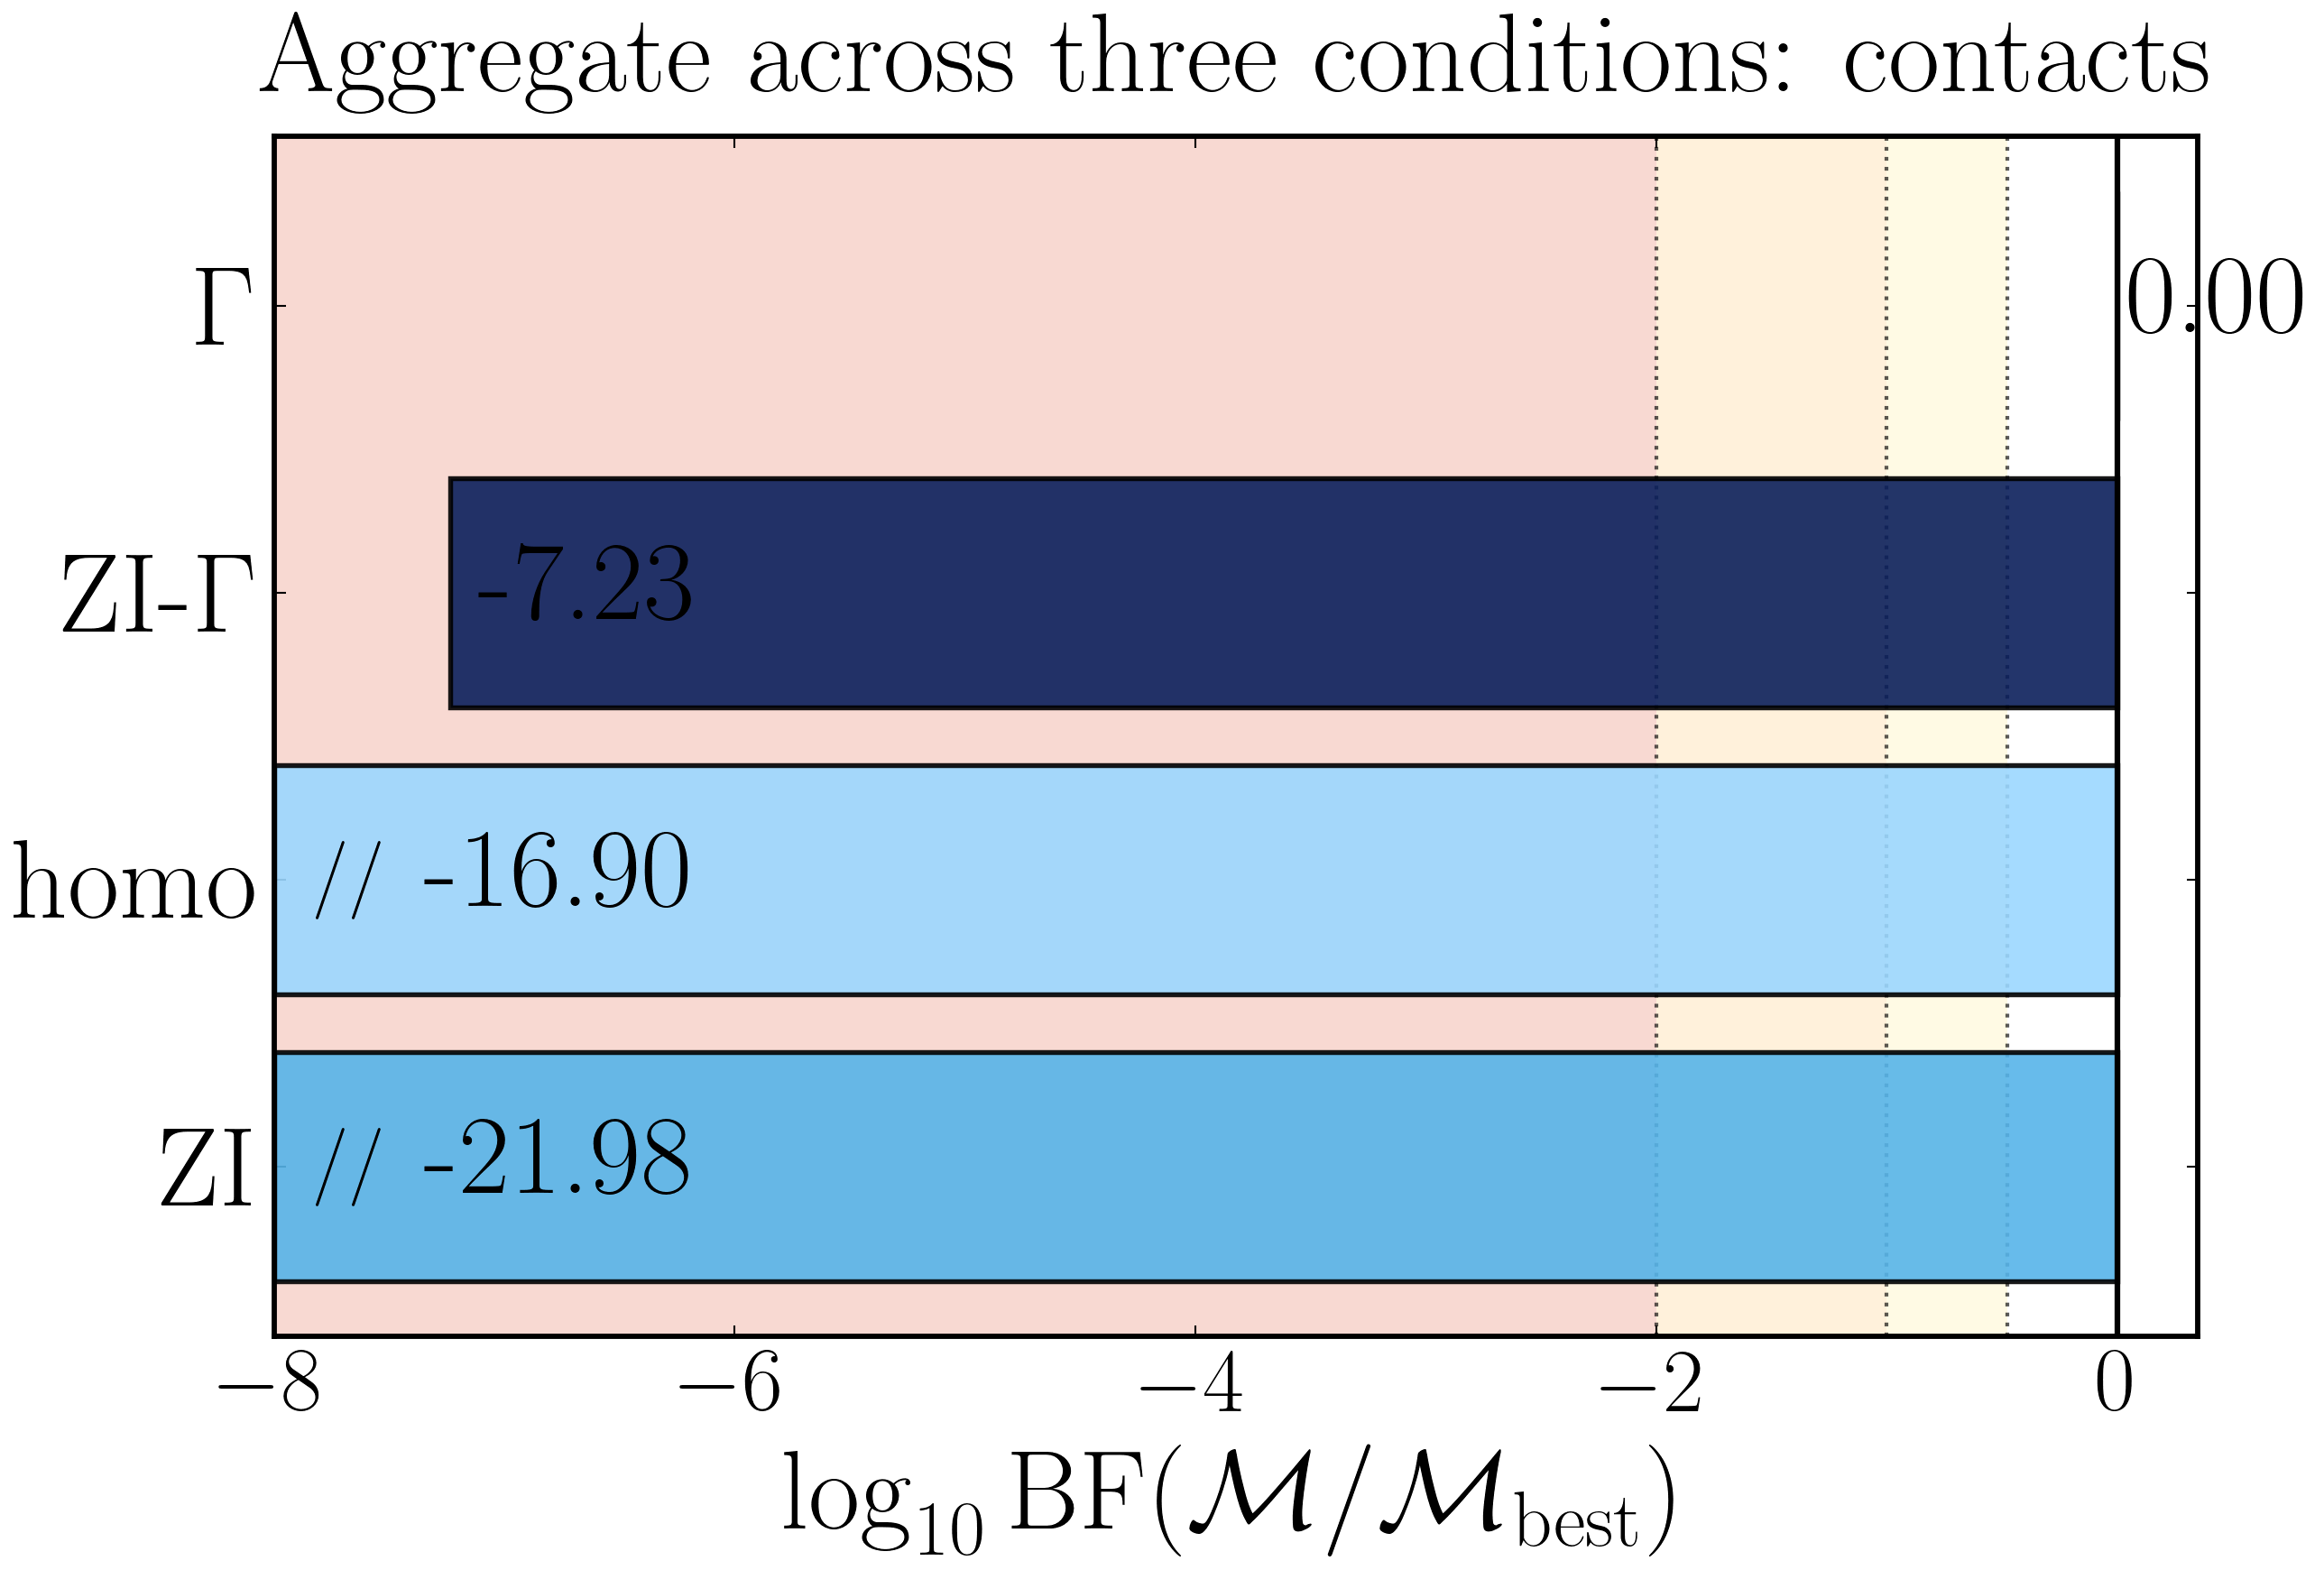

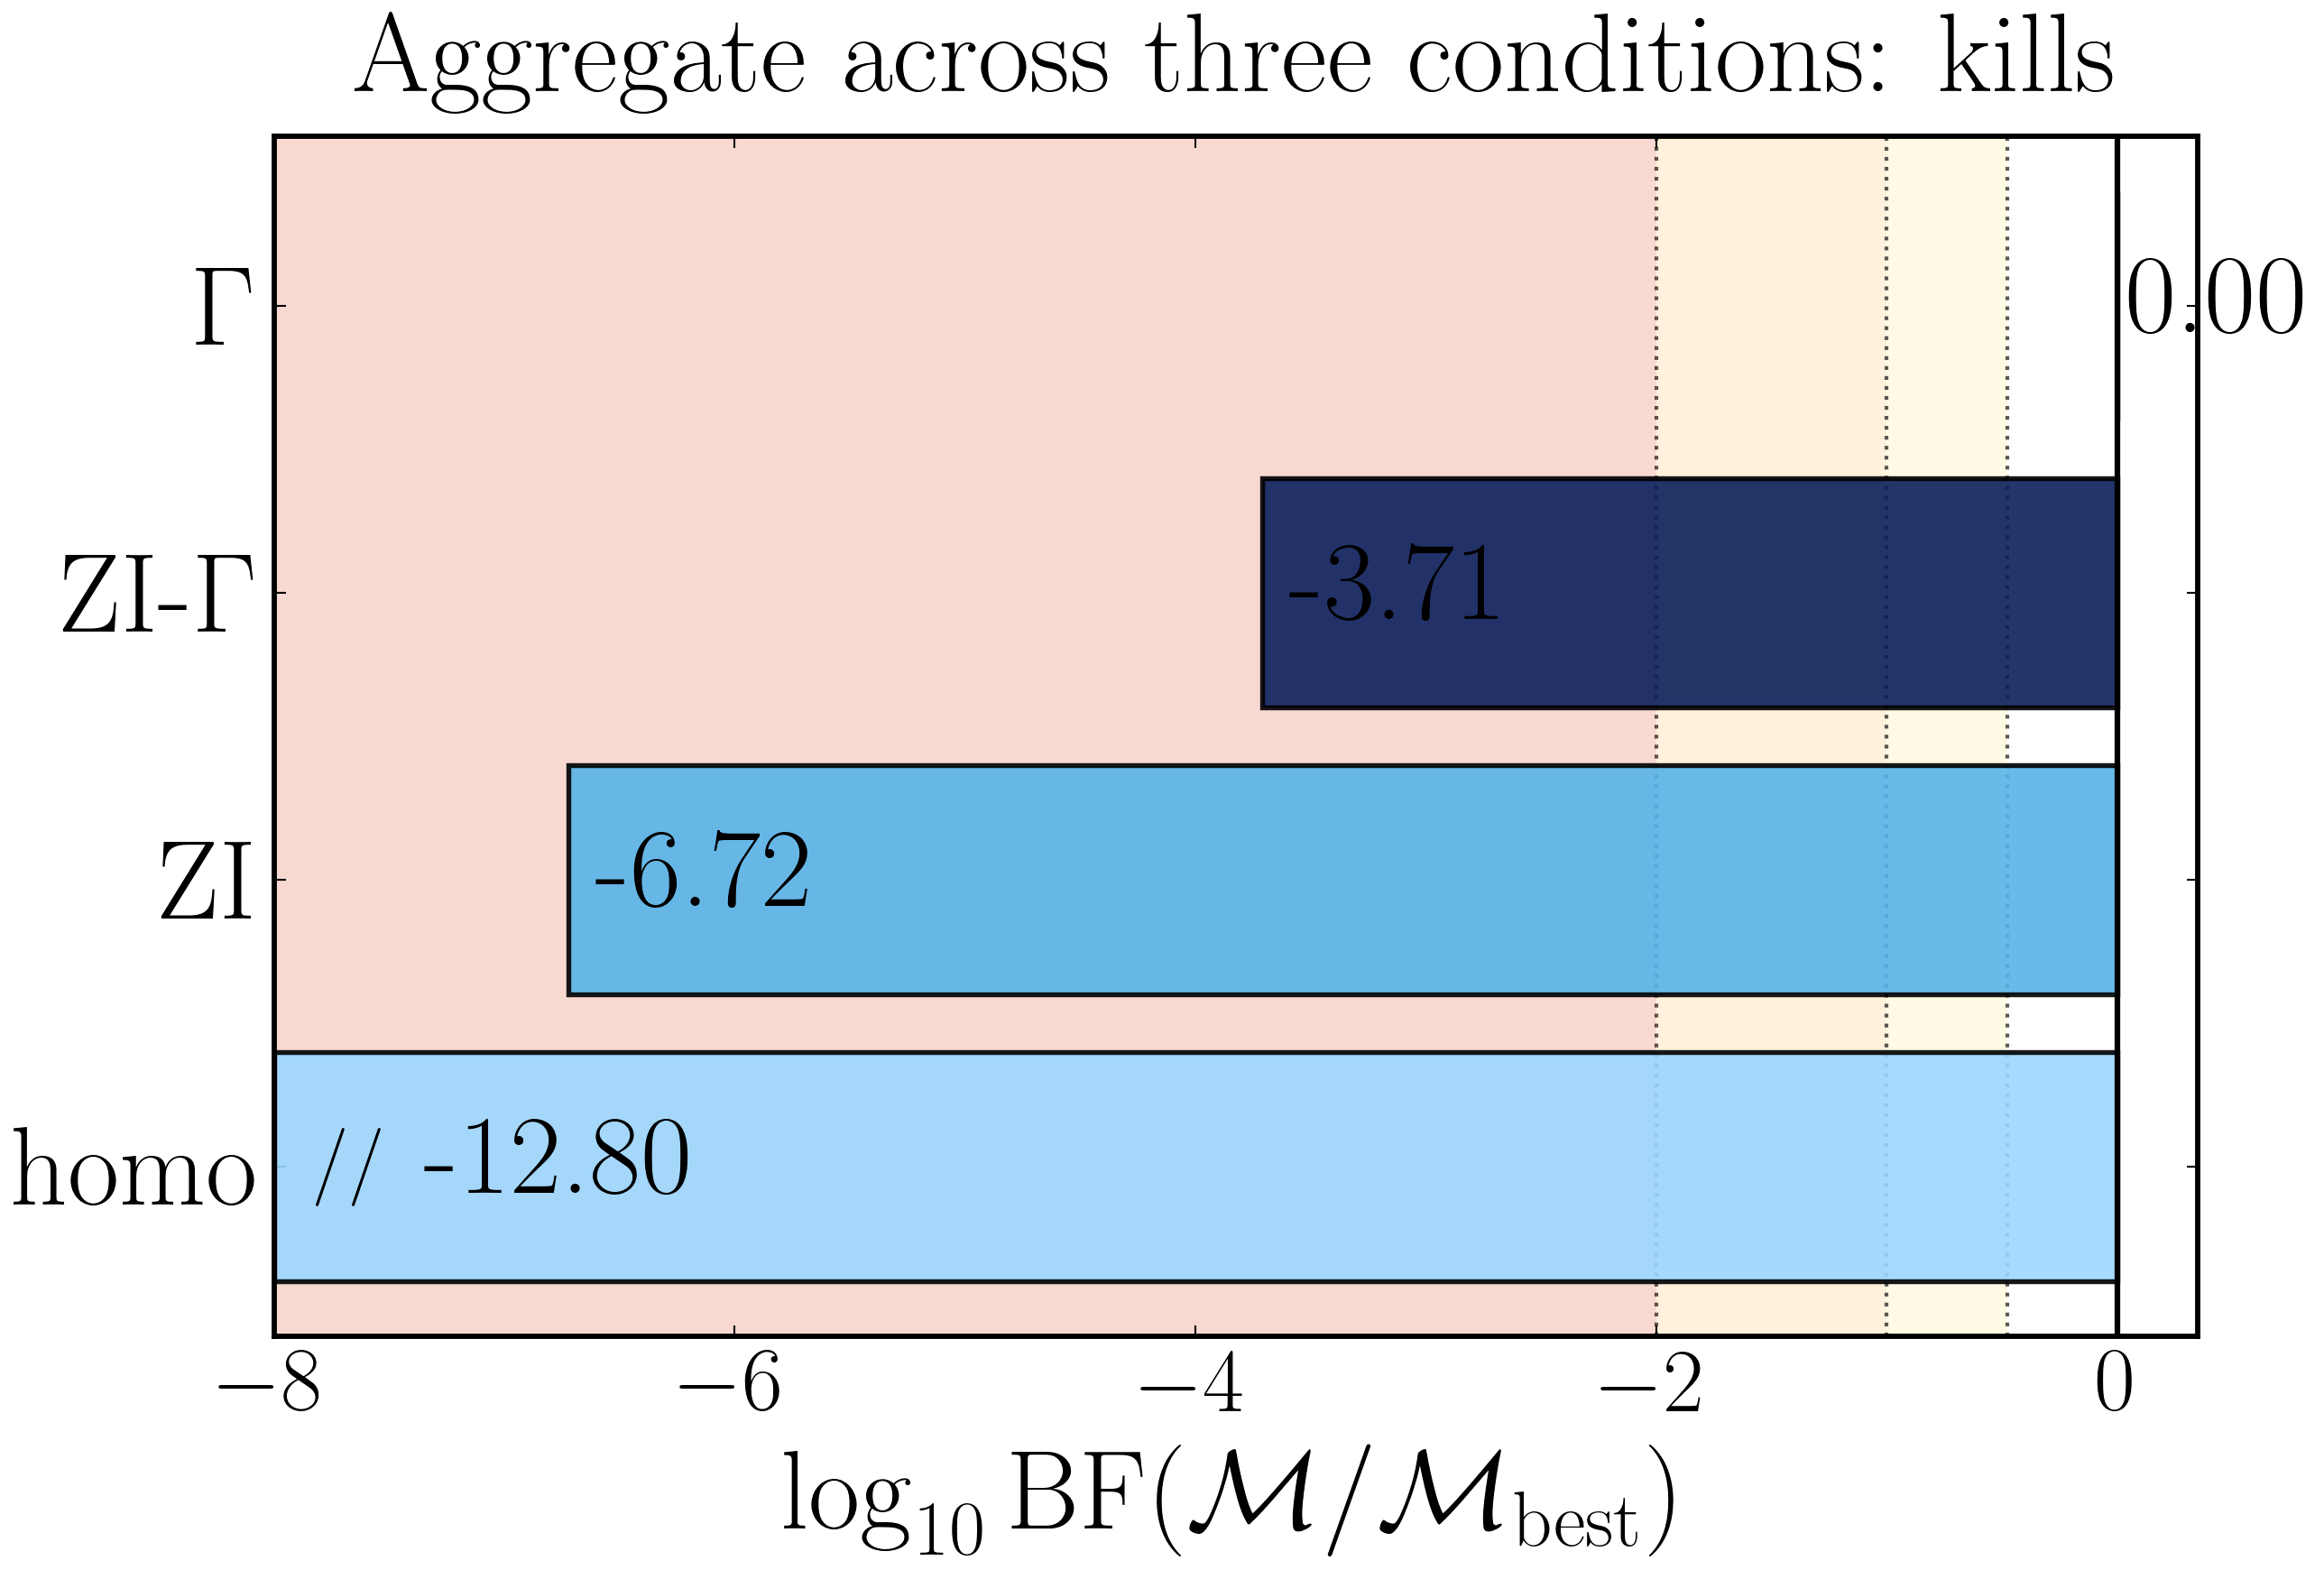

,outcome,model,total_log_evidence,n_conditions,best_total_log_evidence,delta_log_evidence_vs_best,log10_BF_model_vs_best,BF_best_vs_model,best_model,model_display
0,contacts,Dis2P,-3365.1983,3,-3365.1983,0.0000,0.0000,1.000000e+00,Dis2P,$\Gamma$
1,contacts,hetero3,-3381.8571,3,-3365.1983,-16.6588,-7.2348,1.717155e+07,Dis2P,ZI-$\Gamma$
2,contacts,homo,-3404.1151,3,-3365.1983,-38.9168,-16.9013,7.967872e+16,Dis2P,homo
3,contacts,Z2P,-3415.8121,3,-3365.1983,-50.6138,-21.9813,9.578387e+21,Dis2P,ZI
4,kills,Dis2P,-2795.3114,3,-2795.3114,0.0000,0.0000,1.000000e+00,Dis2P,$\Gamma$
5,kills,hetero3,-2803.8594,3,-2795.3114,-8.5479,-3.7123,5.156007e+03,Dis2P,ZI-$\Gamma$
6,kills,Z2P,-2810.7907,3,-2795.3114,-15.4793,-6.7226,5.279331e+06,Dis2P,ZI
7,kills,homo,-2824.7828,3,-2795.3114,-29.4713,-12.7992,6.298588e+12,Dis2P,homo


[PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/bayes_factor_aggregate_three_conditions_contacts.svg'),
 PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/bayes_factor_aggregate_three_conditions_kills.svg')]

In [79]:
def aggregate_bayes_factors_across_conditions(
    comparison: pd.DataFrame,
    conditions=ACTIVE_CONDITION_ORDER,
) -> pd.DataFrame:
    """
    Aggregate model evidence across three independent conditions.

    Summing log marginal likelihoods is equivalent to multiplying
    the condition-specific marginal likelihoods.
    """
    conditions = list(conditions)

    if len(conditions) != 3:
        raise ValueError(
            f"Expected exactly three conditions; received {conditions}"
        )

    subset = comparison[
        comparison["condition"].isin(conditions)
    ].copy()

    if subset.empty:
        raise ValueError("No rows found for the requested conditions.")

    if subset.duplicated(
        ["outcome", "condition", "model"]
    ).any():
        raise ValueError(
            "Duplicate outcome-condition-model rows were found."
        )

    # Ensure every outcome/model has evidence from all three conditions.
    coverage = (
        subset.groupby(
            ["outcome", "model"]
        )["condition"]
        .nunique()
    )

    incomplete = coverage[
        coverage != len(conditions)
    ]

    if not incomplete.empty:
        raise ValueError(
            "Some outcome/model combinations do not contain "
            "all three conditions:\n"
            f"{incomplete}"
        )

    aggregate = (
        subset.groupby(
            ["outcome", "model"],
            as_index=False,
        )
        .agg(
            total_log_evidence=("logml", "sum"),
            n_conditions=("condition", "nunique"),
        )
    )

    aggregate["best_total_log_evidence"] = (
        aggregate.groupby("outcome")[
            "total_log_evidence"
        ].transform("max")
    )

    aggregate["delta_log_evidence_vs_best"] = (
        aggregate["total_log_evidence"]
        - aggregate["best_total_log_evidence"]
    )

    aggregate["log10_BF_model_vs_best"] = (
        aggregate["delta_log_evidence_vs_best"]
        / np.log(10.0)
    )

    aggregate["BF_best_vs_model"] = np.exp(
        np.clip(
            -aggregate["delta_log_evidence_vs_best"],
            -745.0,
            709.0,
        )
    )

    best_models = (
        aggregate.sort_values(
            "total_log_evidence",
            ascending=False,
        )
        .groupby(
            "outcome",
            as_index=False,
        )
        .first()[["outcome", "model"]]
        .rename(
            columns={"model": "best_model"}
        )
    )

    aggregate = aggregate.merge(
        best_models,
        on="outcome",
        how="left",
    )

    aggregate["model_display"] = (
        aggregate["model"]
        .map(MODEL_DISPLAY)
        .fillna(aggregate["model"])
    )

    return aggregate.sort_values(
        [
            "outcome",
            "total_log_evidence",
        ],
        ascending=[True, False],
    ).reset_index(drop=True)


def plot_aggregate_bayes_factors(
    aggregate: pd.DataFrame,
    outcome: str,
    *,
    xmin: float = -8.0,
    xmax: float = 0.35,
) -> Path:
    subset = (
        aggregate[
            aggregate["outcome"] == outcome
        ]
        .copy()
        .sort_values(
            "log10_BF_model_vs_best",
            ascending=True,
        )
    )

    if subset.empty:
        raise ValueError(
            f"No aggregate results found for {outcome!r}"
        )

    best_model = str(
        subset.loc[
            subset["total_log_evidence"].idxmax(),
            "model",
        ]
    )

    bf3 = float(np.log10(3.0))

    fig, ax = plt.subplots(
        figsize=(8.8, 6),
        dpi=300,
    )

    ax.set_xlim(xmin, xmax)

    # Evidence bands.
    ax.axvspan(
        -1.0,
        -bf3,
        color="#FFF3B0",
        alpha=0.34,
        linewidth=0,
        zorder=0,
    )
    ax.axvspan(
        -2.0,
        -1.0,
        color="#FFD28A",
        alpha=0.30,
        linewidth=0,
        zorder=0,
    )
    ax.axvspan(
        xmin,
        -2.0,
        color="#E76F51",
        alpha=0.26,
        linewidth=0,
        zorder=0,
    )

    # Evidence thresholds.
    for threshold in [
        -bf3,
        -1.0,
        -2.0,
    ]:
        ax.axvline(
            threshold,
            color="black",
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
            zorder=1,
        )

    ax.axvline(
        0.0,
        color="black",
        linewidth=1.5,
        zorder=3,
    )

    colors = [
        (
            "#000000"
            if model == best_model
            else MODEL_COLORS.get(
                model,
                "#808080",
            )
        )
        for model in subset["model"]
    ]

    raw_values = subset[
        "log10_BF_model_vs_best"
    ].to_numpy(dtype=float)

    # Clip only the displayed bars.
    plotted_values = np.maximum(
        raw_values,
        xmin,
    )

    bars = ax.barh(
        subset["model_display"],
        plotted_values,
        color=colors,
        edgecolor="black",
        linewidth=1.3,
        alpha=0.90,
        zorder=2,
    )

    for bar, raw_value, plotted_value in zip(
        bars,
        raw_values,
        plotted_values,
    ):
        y = (
            bar.get_y()
            + bar.get_height() / 2
        )

        if raw_value < xmin:
            ax.text(
                xmin + 0.18,
                y,
                "//",
                va="center",
                ha="left",
                fontsize=21,
                color="black",
                zorder=5,
            )
            text_x = xmin + 0.65
        else:
            text_x = (
                plotted_value + 0.12
                if plotted_value < -0.25
                else 0.05
            )

        ax.text(
            text_x,
            y,
            f"{raw_value:.2f}",
            va="center",
            ha="left",
            fontsize=30,
            color="black",
            zorder=5,
        )

    ax.set_xlabel(
        r"$\log_{10}\mathrm{BF}"
        r"(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$",
        fontsize=30,
    )

    # ax.set_ylabel(
    #     "Model",
    #     fontsize=18,
    # )

    ax.set_title(
        f"Aggregate across three conditions: {outcome}",
        fontsize=30,
        pad=12,
    )

    ax.tick_params(
        axis="x",
        labelsize=24,
    )
    ax.tick_params(
        axis="y",
        labelsize=30,
    )
    ax.minorticks_off()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.4)
        spine.set_color("black")

    fig.tight_layout()

    out_path = (
        FIGURE_ROOT
        / f"bayes_factor_aggregate_three_conditions_{outcome}.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.2,
        transparent=True,
    )

    plt.show()

    return out_path


aggregate_bf_df = (
    aggregate_bayes_factors_across_conditions(
        bf_condition_df,
        conditions=ACTIVE_CONDITION_ORDER,
    )
)

aggregate_bf_df.to_csv(
    RESULT_ROOT
    / "bayes_factors_aggregate_three_conditions.csv",
    index=False,
)

aggregate_bf_figure_paths = [
    plot_aggregate_bayes_factors(
        aggregate_bf_df,
        outcome,
        xmin=-8.0,
    )
    for outcome in ACTIVE_OUTCOME_ORDER
]

display(aggregate_bf_df.round(4))
aggregate_bf_figure_paths

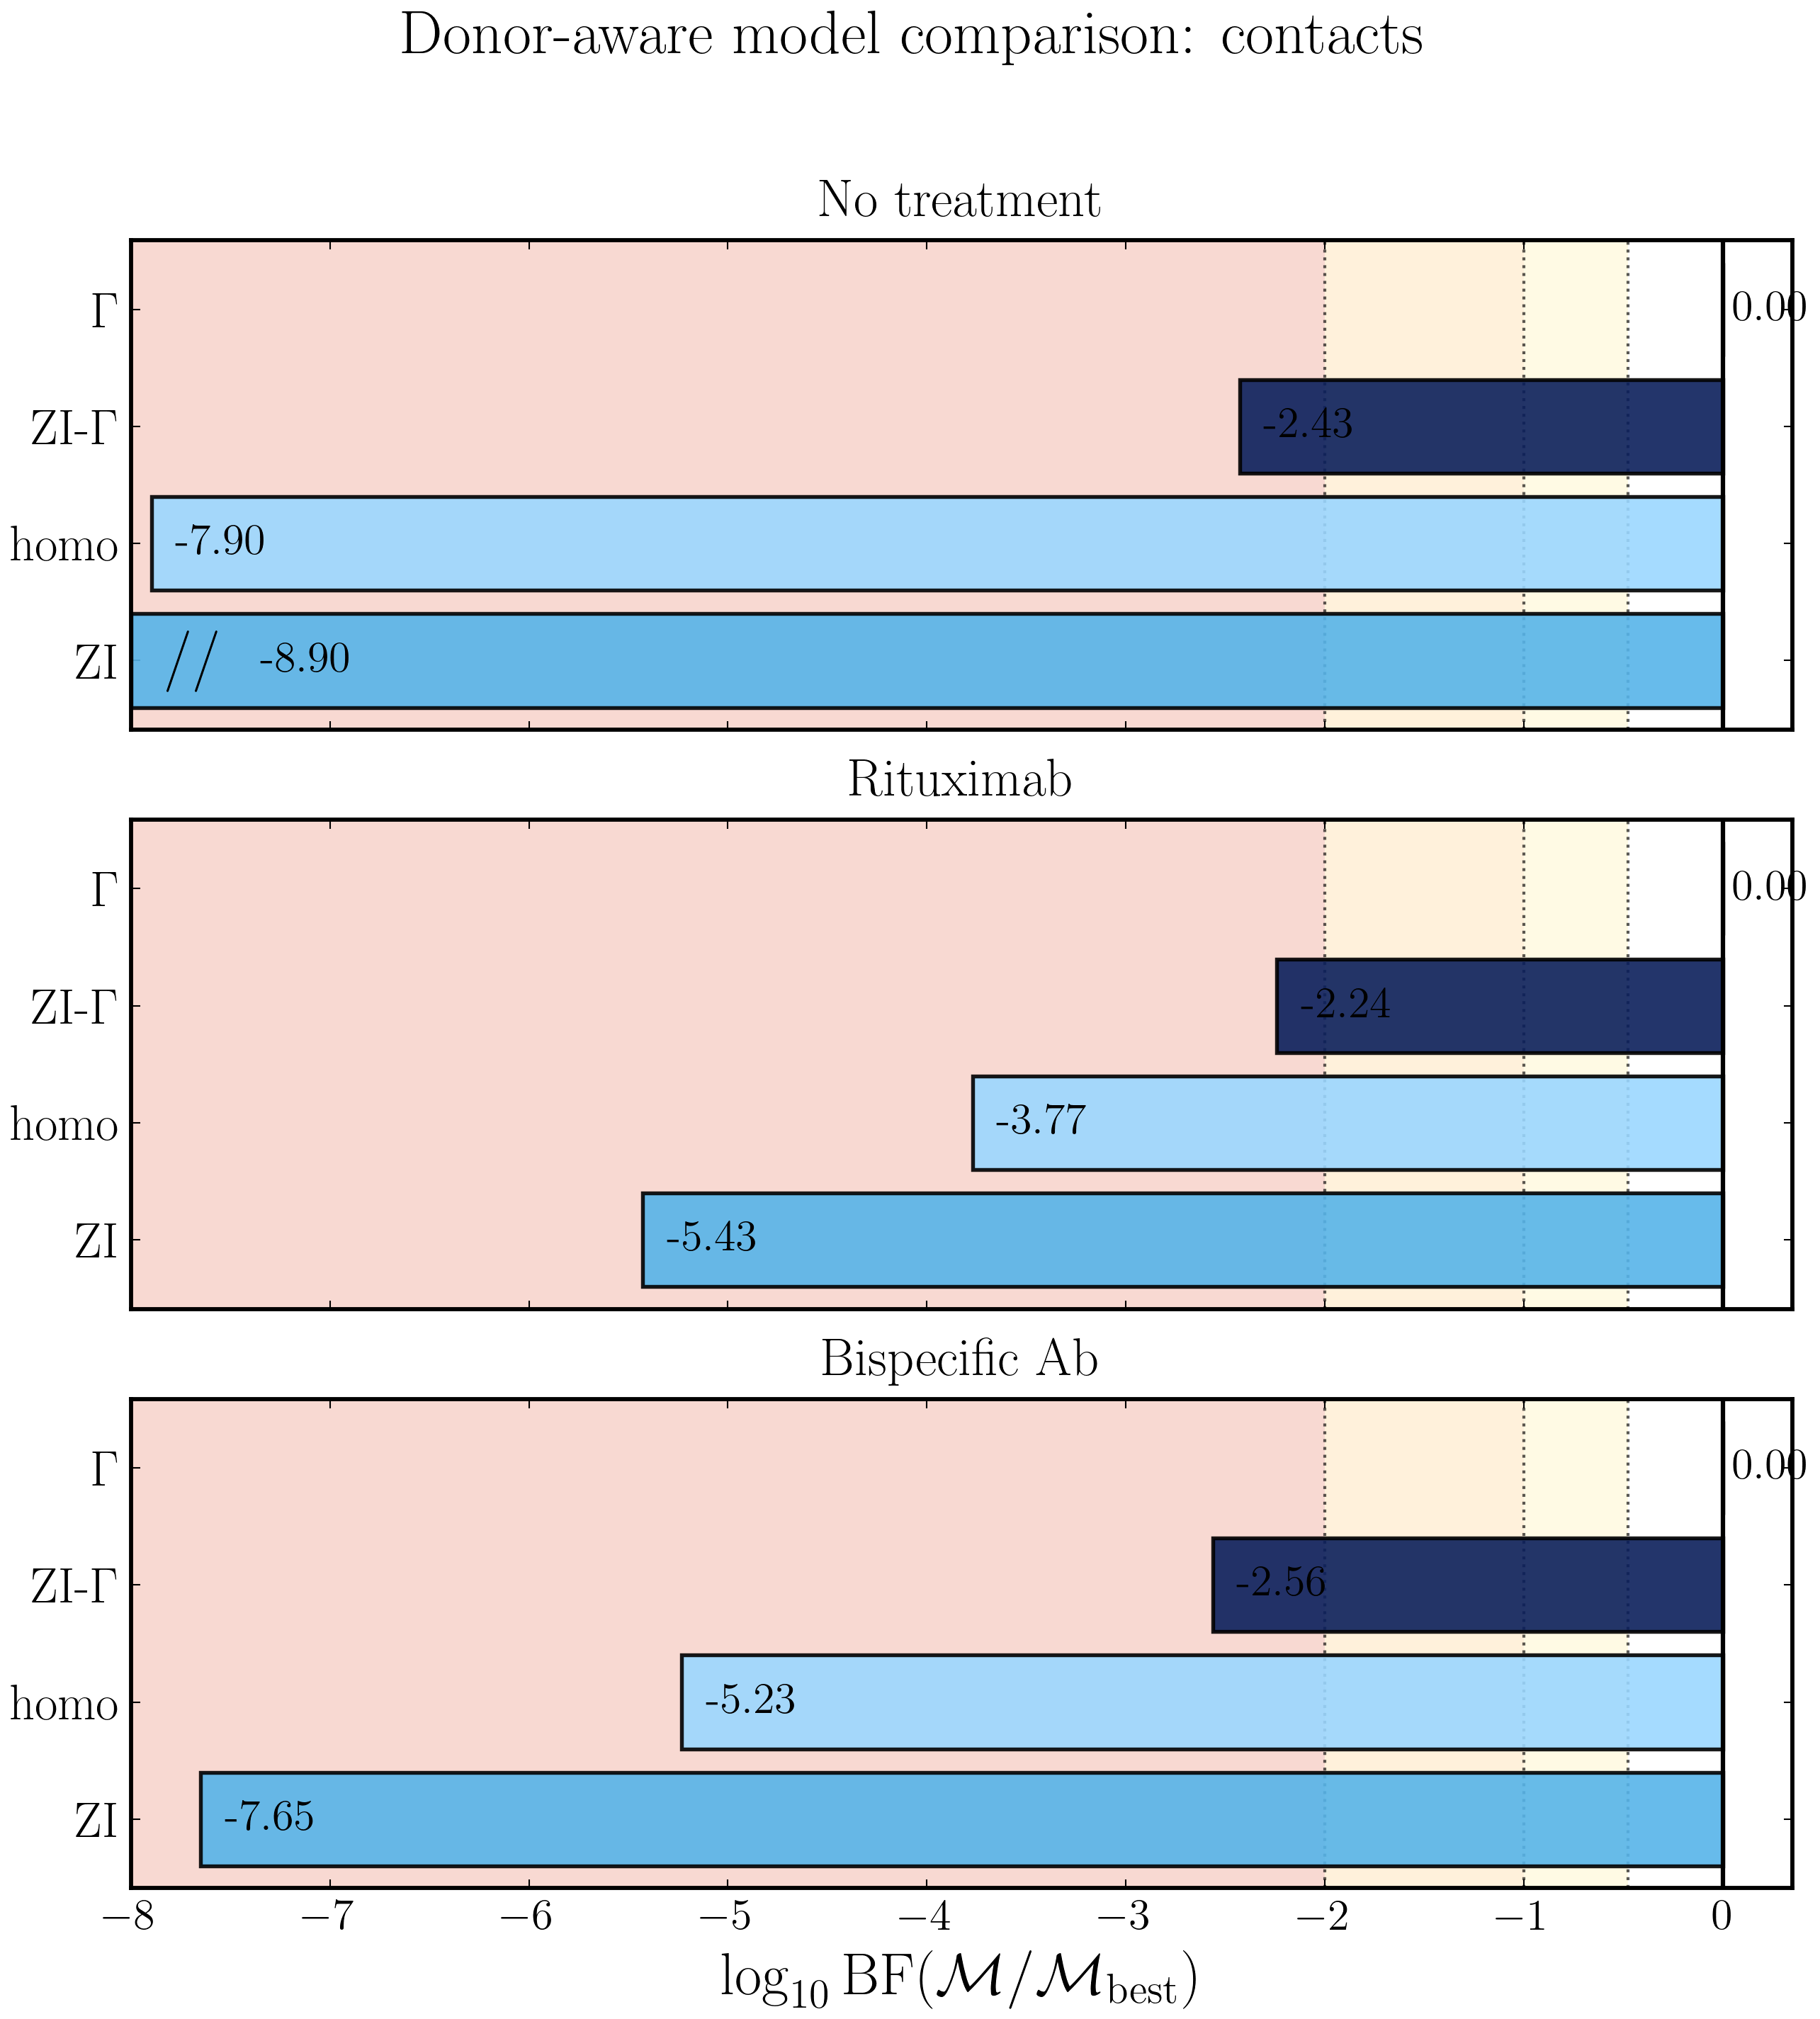

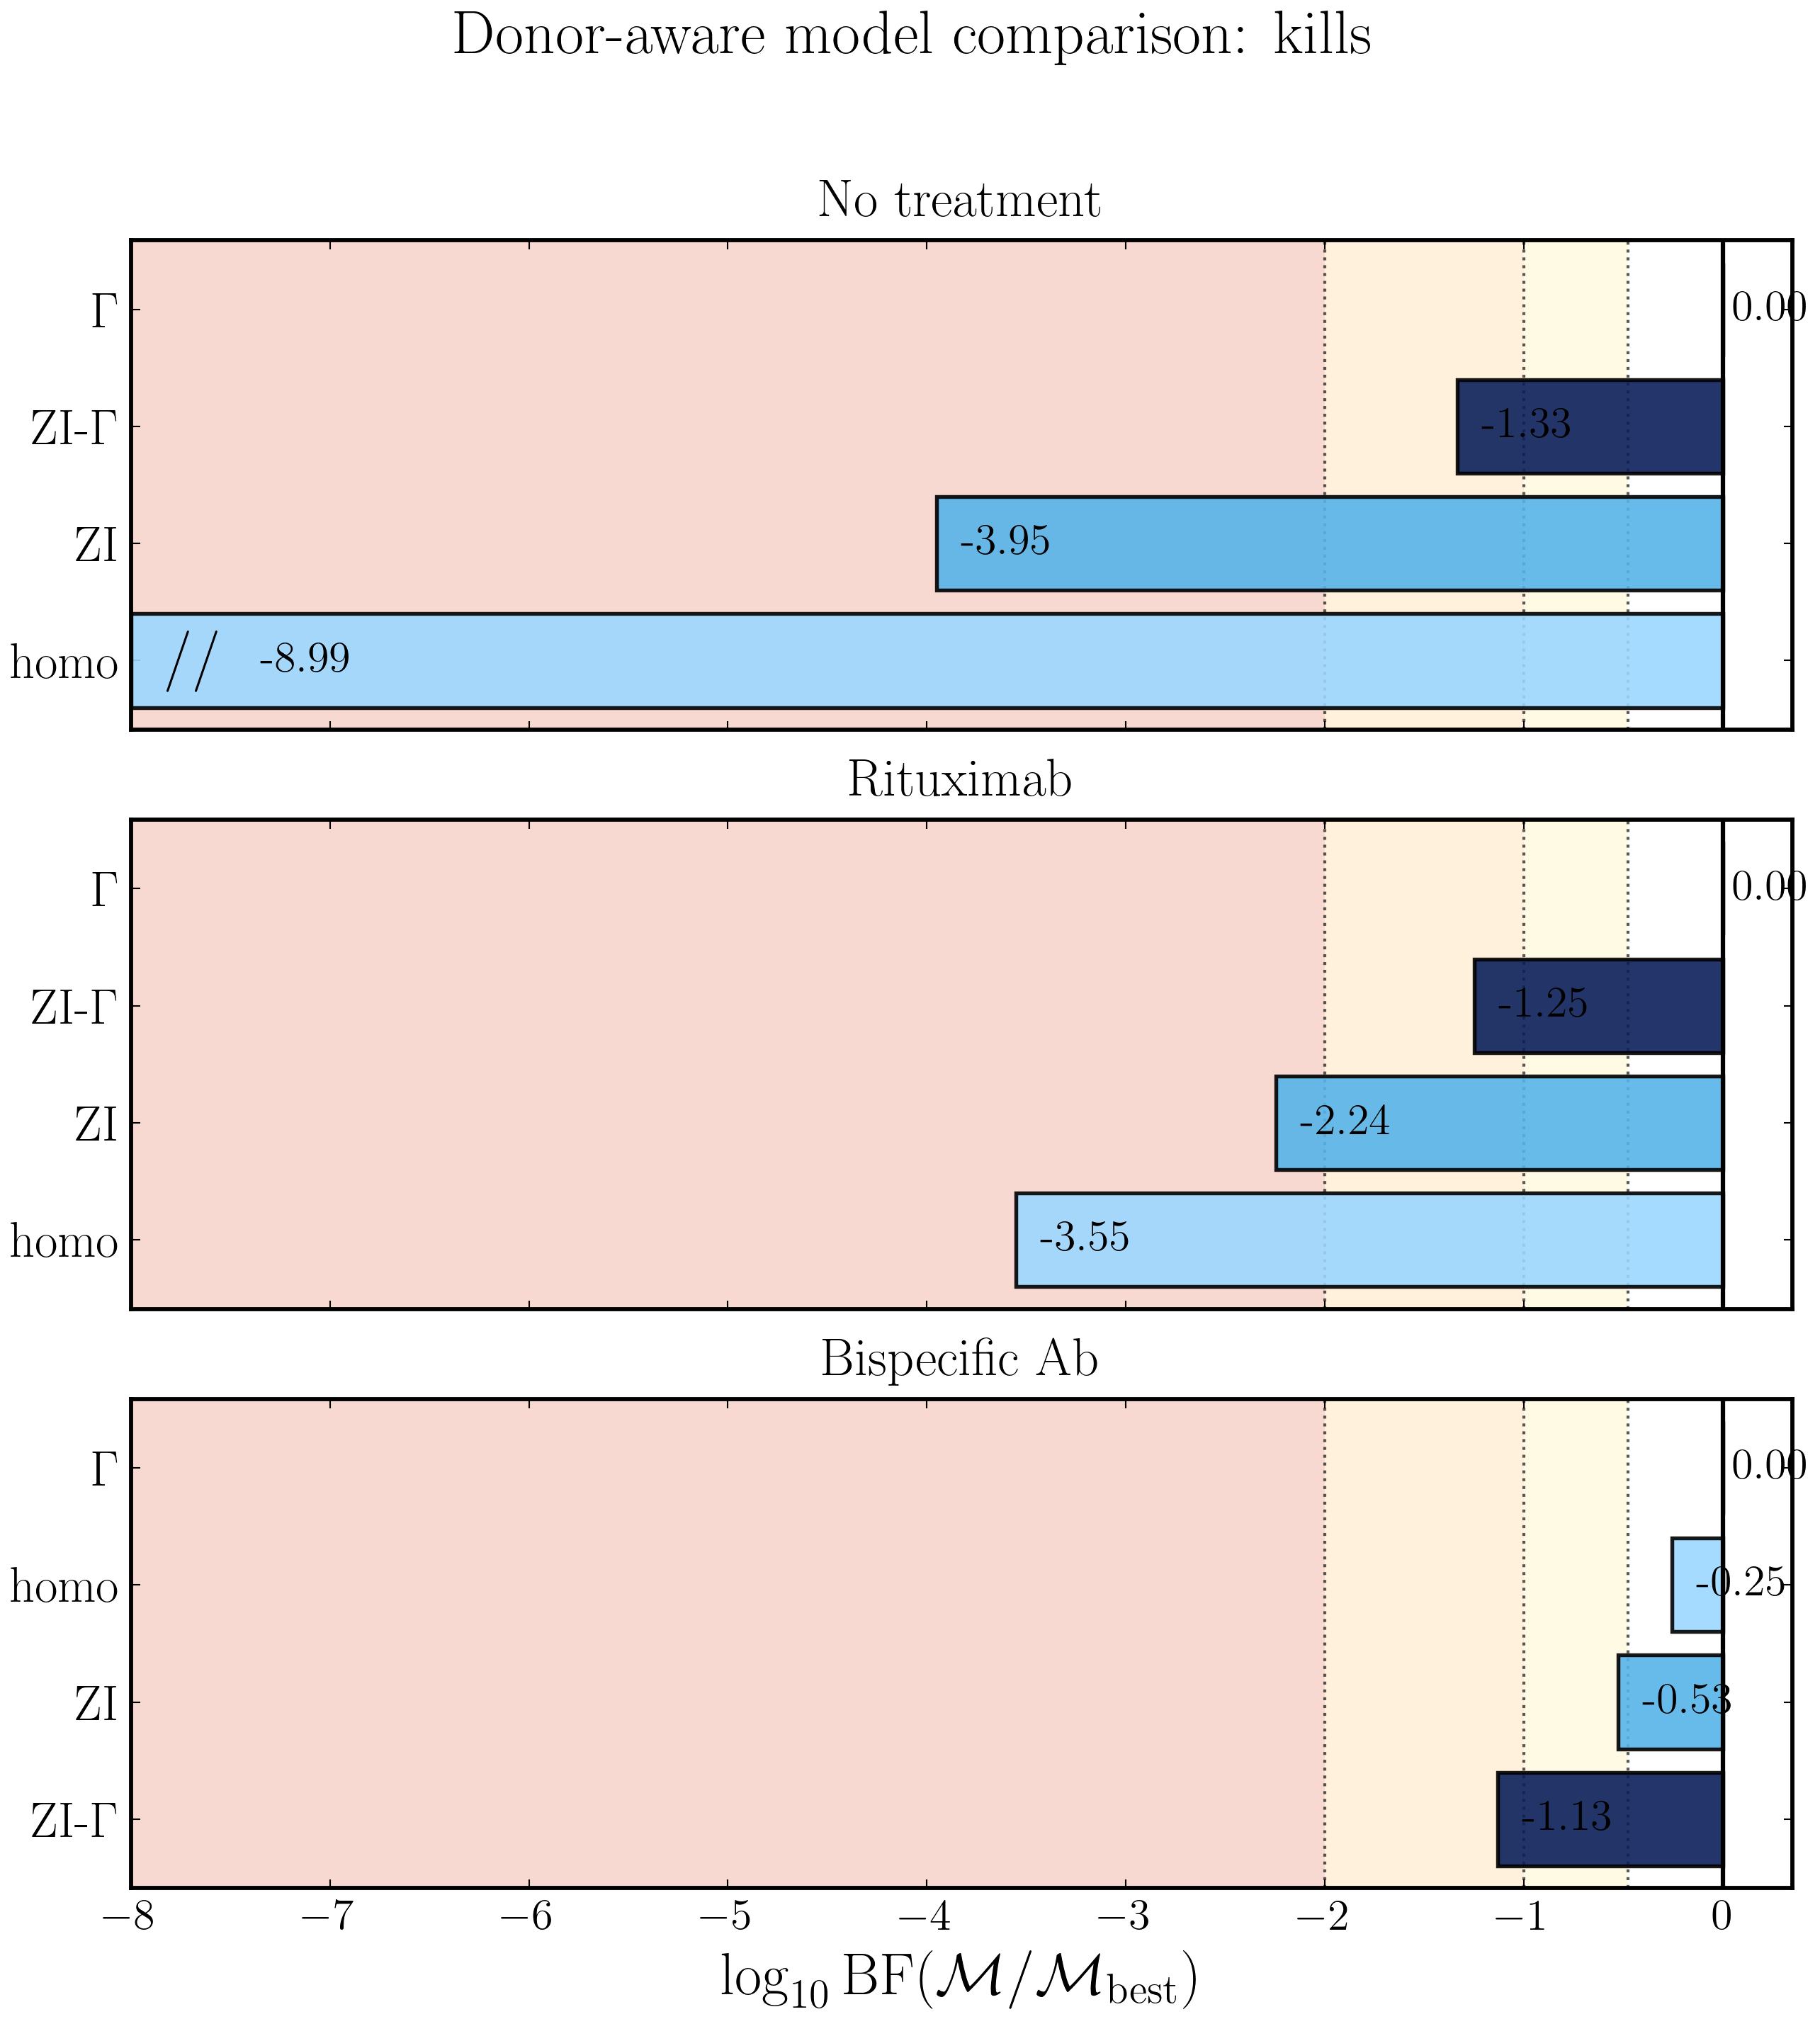

[PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/bayes_factor_by_condition_contacts.svg'),
 PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/bayes_factor_by_condition_kills.svg')]

In [53]:
def plot_bayes_factors_by_condition(
    comparison: pd.DataFrame,
    outcome: str,
    *,
    xmin: float = -8.0,
    xmax: float = 0.35,
) -> Path:
    conditions = [
        condition
        for condition in ACTIVE_CONDITION_ORDER
        if condition
        in comparison.loc[
            comparison["outcome"] == outcome,
            "condition",
        ].unique()
    ]

    if not conditions:
        raise ValueError(f"No results found for outcome {outcome!r}")

    bf3 = float(np.log10(3.0))

    fig, axes = plt.subplots(
        len(conditions),
        1,
        figsize=(8.8, 3.2 * len(conditions)),
        sharex=True,
        dpi=300,
        squeeze=False,
    )

    for ax, condition in zip(axes[:, 0], conditions):
        subset = (
            comparison[
                (comparison["condition"] == condition)
                & (comparison["outcome"] == outcome)
            ]
            .copy()
            .sort_values(
                "log10_BF_model_vs_best",
                ascending=True,
            )
        )

        ax.set_xlim(xmin, xmax)

        # Evidence bands.
        ax.axvspan(
            -1.0,
            -bf3,
            color="#FFF3B0",
            alpha=0.34,
            linewidth=0,
            zorder=0,
        )
        ax.axvspan(
            -2.0,
            -1.0,
            color="#FFD28A",
            alpha=0.30,
            linewidth=0,
            zorder=0,
        )
        ax.axvspan(
            xmin,
            -2.0,
            color="#E76F51",
            alpha=0.26,
            linewidth=0,
            zorder=0,
        )

        # Evidence thresholds.
        ax.axvline(
            -bf3,
            color="black",
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
            zorder=1,
        )
        ax.axvline(
            -1.0,
            color="black",
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
            zorder=1,
        )
        ax.axvline(
            -2.0,
            color="black",
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
            zorder=1,
        )
        ax.axvline(
            0.0,
            color="black",
            linewidth=1.5,
            zorder=3,
        )

        colors = [
            (
                "#000000"
                if row.model == row.best_model
                else MODEL_COLORS[row.model]
            )
            for row in subset.itertuples()
        ]

        raw_values = subset[
            "log10_BF_model_vs_best"
        ].to_numpy(dtype=float)

        # Clip only the displayed bars, not the reported values.
        plotted_values = np.maximum(raw_values, xmin)

        bars = ax.barh(
            subset["model_display"],
            plotted_values,
            color=colors,
            edgecolor="black",
            linewidth=1.3,
            alpha=0.90,
            zorder=2,
        )

        for bar, raw_value, plotted_value in zip(
            bars,
            raw_values,
            plotted_values,
        ):
            y = bar.get_y() + bar.get_height() / 2
            is_clipped = raw_value < xmin

            if is_clipped:
                ax.text(
                    xmin + 0.18,
                    y,
                    "//",
                    va="center",
                    ha="left",
                    fontsize=21,
                    color="black",
                    zorder=5,
                )
                text_x = xmin + 0.65
            else:
                text_x = (
                    plotted_value + 0.12
                    if plotted_value < -0.25
                    else 0.05
                )

            ax.text(
                text_x,
                y,
                f"{raw_value:.2f}",
                va="center",
                ha="left",
                fontsize=15,
                color="black",
                zorder=5,
            )

        ax.set_title(
            condition,
            fontsize=18,
            pad=8,
        )
        ax.tick_params(
            axis="x",
            labelsize=15,
        )
        ax.tick_params(
            axis="y",
            labelsize=17,
        )
        ax.minorticks_off()
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_color("black")

    axes[-1, 0].set_xlabel(
        r"$\log_{10}\mathrm{BF}"
        r"(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$",
        fontsize=20,
    )

    fig.suptitle(
        f"Donor-aware model comparison: {outcome}",
        fontsize=21,
        y=0.995,
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.97),
        h_pad=1.0,
    )

    out_path = (
        FIGURE_ROOT
        / f"bayes_factor_by_condition_{outcome}.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.2,
        transparent=True,
    )

    plt.show()
    return out_path


bayes_factor_figure_paths = [
    plot_bayes_factors_by_condition(
        bf_condition_df,
        outcome,
        xmin=-8.0,
    )
    for outcome in ACTIVE_OUTCOME_ORDER
]

bayes_factor_figure_paths

## Posterior summaries for the best-supported model


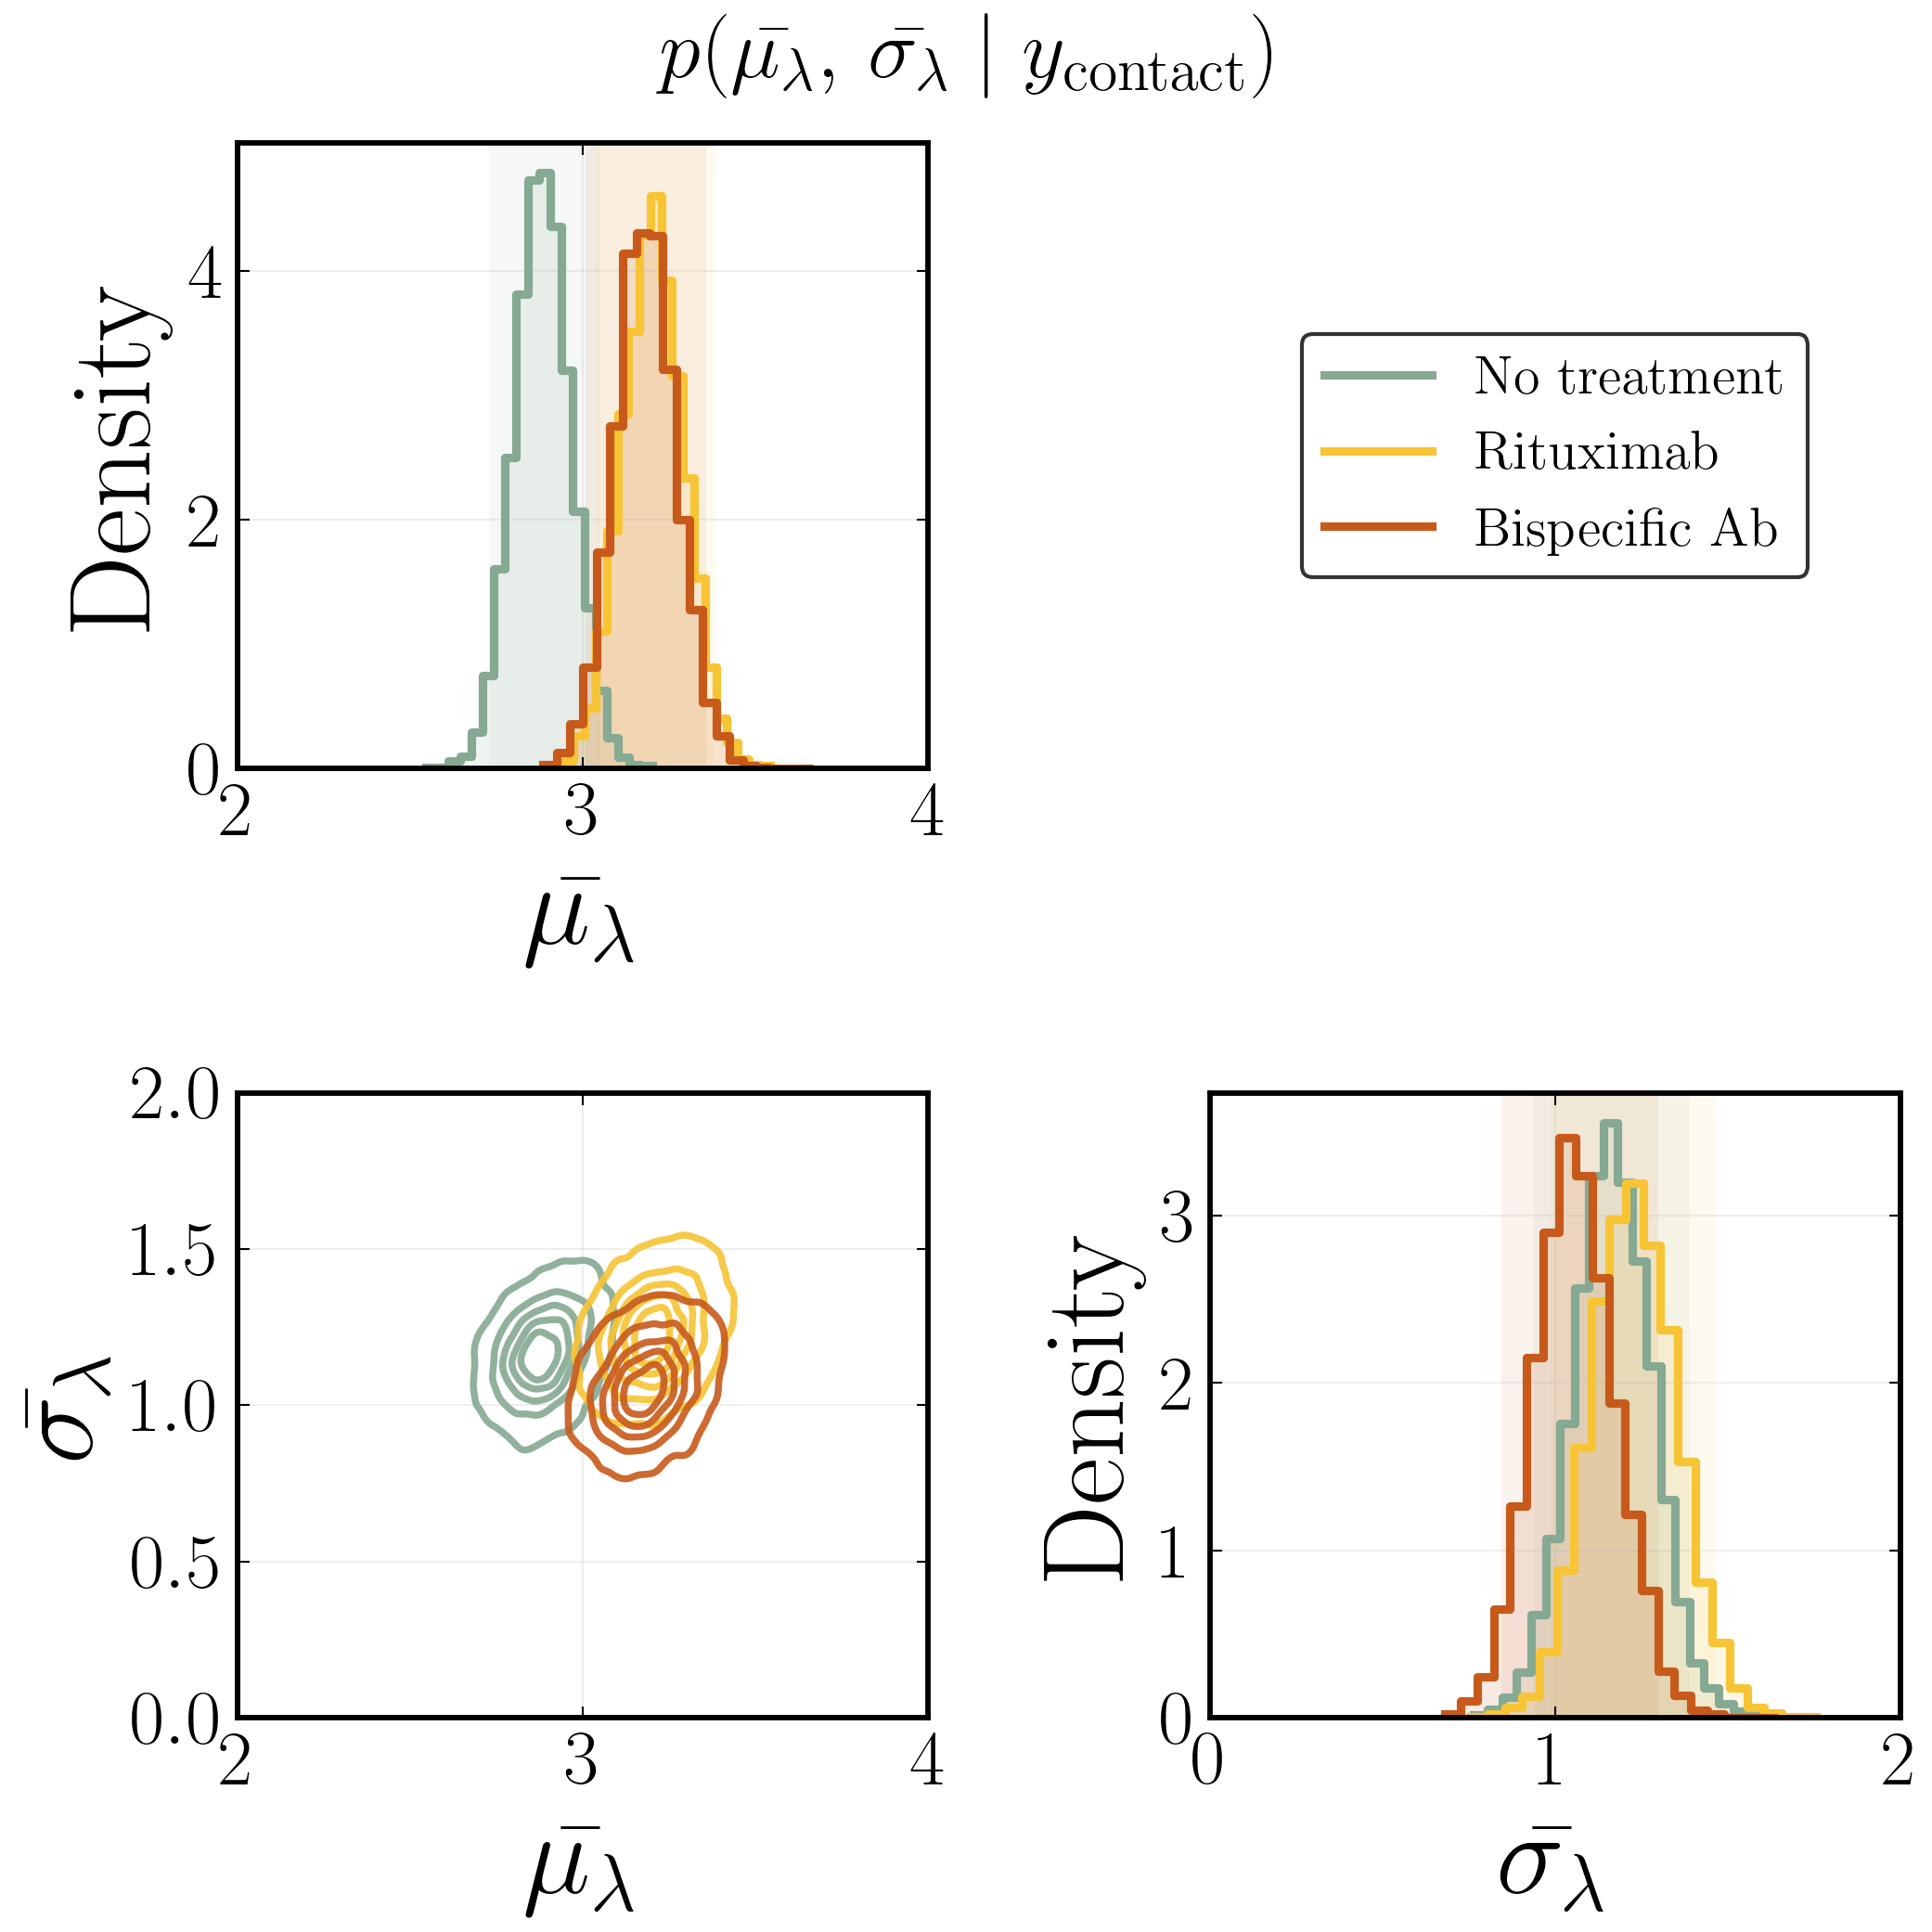

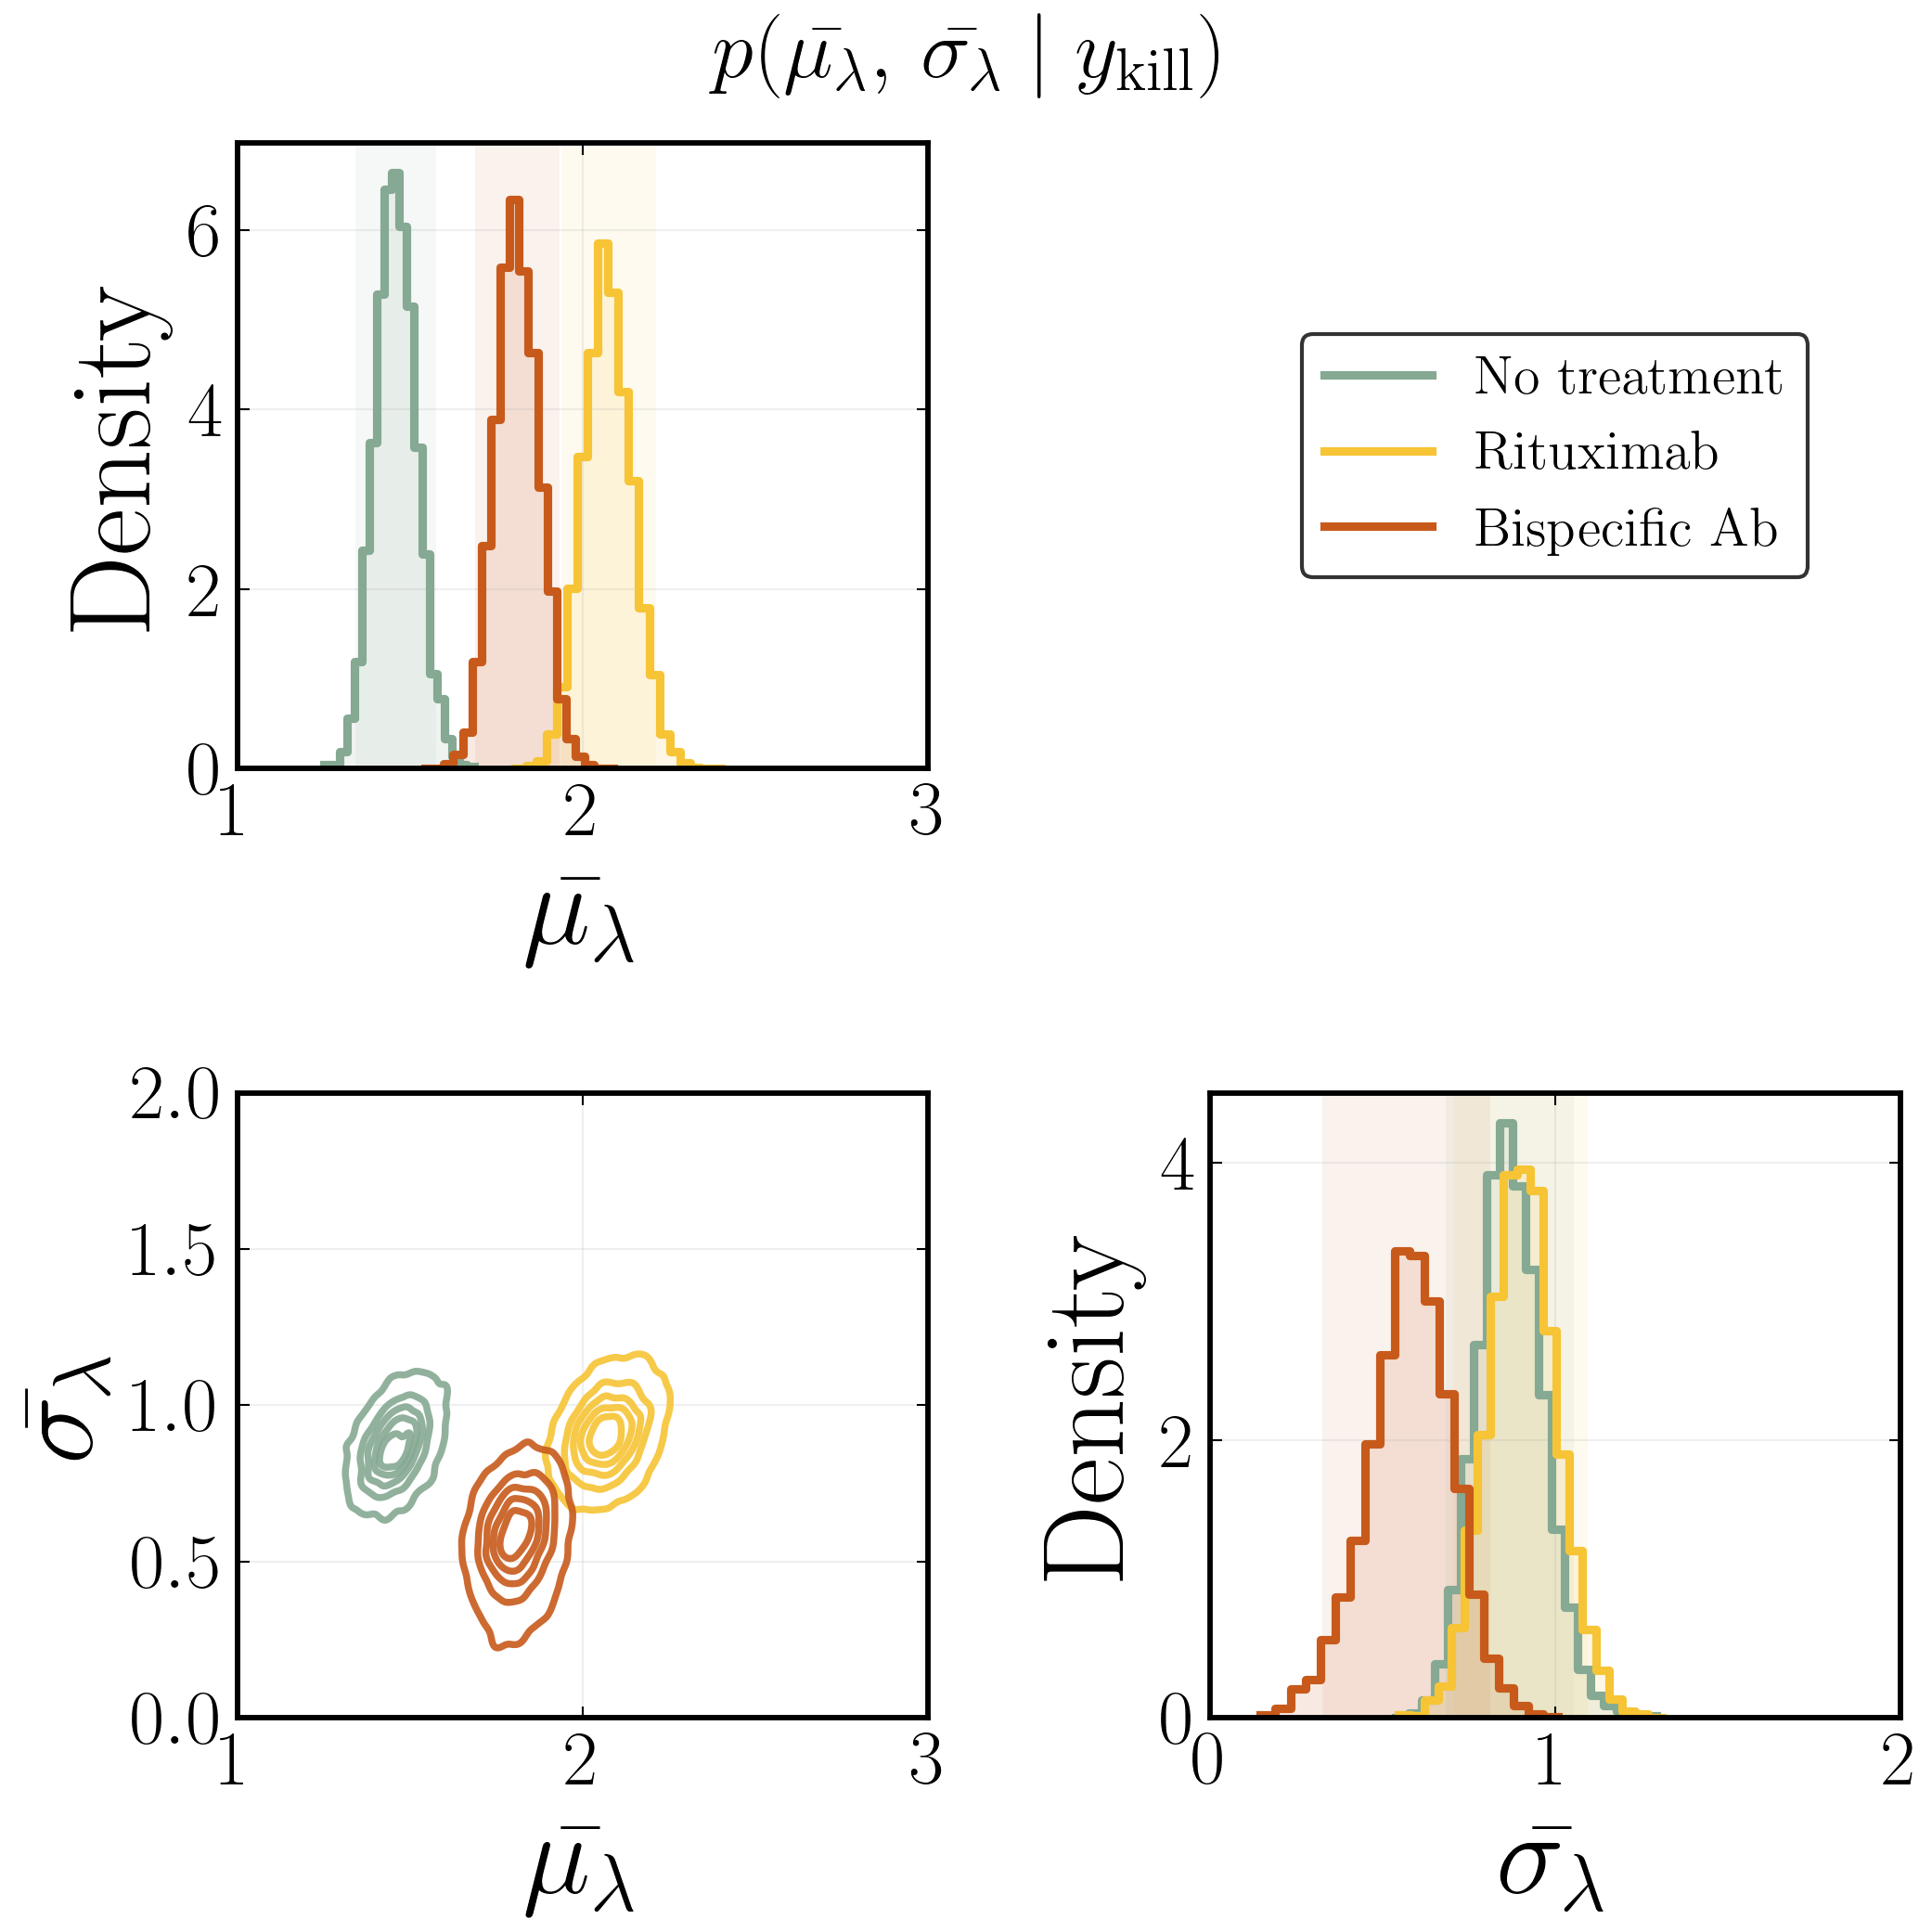

{'contacts': PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/joint_posterior_population_parameters_contacts_Dis2P.svg'),
 'kills': PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/joint_posterior_population_parameters_kills_Dis2P.svg')}

In [81]:
POPULATION_PARAM_DISPLAY = {
    "mu_lambda_population": r"$\bar{\mu_\lambda}$",
    "sigma_lambda_population": r"$\bar{\sigma_\lambda}$",
}

DONOR_CONDITION_COLORS = {
    "No treatment": "#85a993",
    "Rituximab": "#f7c435",
    "Bispecific Ab": "#c75a1b",
}

OUTCOME_SYMBOL = {
    "contacts": r"y_{\mathrm{contact}}",
    "kills": r"y_{\mathrm{kill}}",
}


def get_paired_population_samples(
    idata: az.InferenceData,
    *,
    sample_size: int | None = 6000,
    seed: int = 17,
) -> tuple[np.ndarray, np.ndarray]:
    variables = (
        "mu_lambda_population",
        "sigma_lambda_population",
    )

    missing = [
        variable
        for variable in variables
        if variable not in idata.posterior
    ]
    if missing:
        raise ValueError(
            f"Posterior is missing population parameter(s): {missing}"
        )

    for variable in variables:
        dims = set(idata.posterior[variable].dims)
        if dims != {"chain", "draw"}:
            raise ValueError(
                f"Expected scalar posterior variable {variable!r}; "
                f"found dimensions {idata.posterior[variable].dims}"
            )

    posterior = (
        idata.posterior[list(variables)]
        .stack(sample=("chain", "draw"))
    )

    mu_samples = np.asarray(
        posterior["mu_lambda_population"].values,
        dtype=float,
    ).ravel()
    sigma_samples = np.asarray(
        posterior["sigma_lambda_population"].values,
        dtype=float,
    ).ravel()

    keep = np.isfinite(mu_samples) & np.isfinite(sigma_samples)
    joint_samples = np.column_stack(
        [mu_samples[keep], sigma_samples[keep]]
    )

    if joint_samples.shape[0] == 0:
        raise ValueError("No finite paired posterior samples")

    if sample_size is not None:
        if sample_size <= 0:
            raise ValueError("sample_size must be positive or None")

        if joint_samples.shape[0] > sample_size:
            rng = np.random.default_rng(seed)
            indices = rng.choice(
                joint_samples.shape[0],
                size=sample_size,
                replace=False,
            )
            joint_samples = joint_samples[indices]

    return joint_samples[:, 0], joint_samples[:, 1]


def plot_population_joint_posterior(
    posterior_data: dict,
    outcome: str,
    *,
    model_name: str = "Dis2P",
    conditions: list[str] | None = None,
    colors: dict[str, str] | None = None,
    sample_size: int | None = 8000,
    hdi_prob: float = 0.95,
    bins: int = 20,
    param_limits: dict[str, tuple[float, float]] | None = None,
    save_dir: Path = FIGURE_ROOT,
    dpi: int = 300,
) -> Path:
    if conditions is None:
        conditions = CONDITION_ORDER
    if colors is None:
        colors = DONOR_CONDITION_COLORS

    conditions = [
        condition
        for condition in conditions
        if (condition, outcome, model_name) in posterior_data
    ]

    if not conditions:
        raise ValueError(
            f"No posterior data for outcome={outcome!r}, "
            f"model={model_name!r}"
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7, 7),
        dpi=dpi,
        squeeze=False,
        constrained_layout=True,
    )
    axes[0, 1].axis("off")

    fig.set_constrained_layout_pads(
        w_pad=0.08,
        h_pad=0.08,
        wspace=0.10,
        hspace=0.10,
    )

    for condition_index, condition in enumerate(conditions):
        idata = posterior_data[
            (condition, outcome, model_name)
        ]

        mu_samples, sigma_samples = (
            get_paired_population_samples(
                idata,
                sample_size=sample_size,
                seed=17 + condition_index,
            )
        )

        color = colors[condition]

        for values, ax, legend_label in [
            (mu_samples, axes[0, 0], condition),
            (sigma_samples, axes[1, 1], None),
        ]:
            sns.histplot(
                values,
                bins=bins,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.12,
                linewidth=0,
                ax=ax,
            )
            sns.histplot(
                values,
                bins=bins,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.2,
                label=legend_label,
                ax=ax,
            )

            hdi = np.asarray(
                az.hdi(values, hdi_prob=hdi_prob),
                dtype=float,
            )
            ax.axvspan(
                hdi[0],
                hdi[1],
                color=color,
                alpha=0.08,
                linewidth=0,
            )

        sns.kdeplot(
            x=mu_samples,
            y=sigma_samples,
            color=color,
            linewidths=1.8,
            levels=6,
            fill=False,
            alpha=0.90,
            cut=0,
            warn_singular=False,
            ax=axes[1, 0],
        )

    mu_label = POPULATION_PARAM_DISPLAY["mu_lambda_population"]
    sigma_label = POPULATION_PARAM_DISPLAY["sigma_lambda_population"]

    axis_label_fontsize = 30
    axes[0, 0].set_xlabel(mu_label, fontsize=axis_label_fontsize)
    axes[0, 0].set_ylabel("Density", fontsize=axis_label_fontsize)

    axes[1, 0].set_xlabel(mu_label, fontsize=axis_label_fontsize)
    axes[1, 0].set_ylabel(sigma_label, fontsize=axis_label_fontsize)

    axes[1, 1].set_xlabel(sigma_label, fontsize=axis_label_fontsize)
    axes[1, 1].set_ylabel("Density", fontsize=axis_label_fontsize)
    # axes[1, 1].yaxis.set_label_position("right")
    # axes[1, 1].yaxis.tick_right()

    if param_limits is not None:
        if "mu_lambda_population" in param_limits:
            axes[0, 0].set_xlim(
                *param_limits["mu_lambda_population"]
            )
            axes[1, 0].set_xlim(
                *param_limits["mu_lambda_population"]
            )

        if "sigma_lambda_population" in param_limits:
            axes[1, 1].set_xlim(
                *param_limits["sigma_lambda_population"]
            )
            axes[1, 0].set_ylim(
                *param_limits["sigma_lambda_population"]
            )

    for row, column in [(0, 0), (1, 0), (1, 1)]:
        ax = axes[row, column]
        ax.set_facecolor("white")
        ax.tick_params(axis="both", labelsize=20)
        ax.minorticks_off()
        ax.grid(alpha=0.20)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_color("black")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    axes[0, 1].legend(
        handles,
        labels,
        loc="center",
        ncol=1,
        frameon=True,
        edgecolor="black",
        fontsize=14,
    )

    fig.suptitle(
        rf"$p(\bar{{\mu_\lambda}},\,"
        rf"\bar{{\sigma_\lambda}}"
        rf"\mid {OUTCOME_SYMBOL[outcome]})$",
        fontsize=22,
    )

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    out_path = save_dir / (
        f"joint_posterior_population_parameters_"
        f"{outcome}_{model_name}.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.3,
        transparent=True,
    )

    plt.show()
    return out_path


POPULATION_HYPERPARAMETER_LIMITS = {
    "contacts": {
        "mu_lambda_population": (2, 4),
        "sigma_lambda_population": (0.0, 2.0),
    },
    "kills": {
        "mu_lambda_population": (1, 3),
        "sigma_lambda_population": (0, 2),
    },
}

POPULATION_JOINT_PATHS = {
    outcome: plot_population_joint_posterior(
        posterior_data,
        outcome=outcome,
        model_name="Dis2P",
        param_limits=POPULATION_HYPERPARAMETER_LIMITS[outcome],
    )
    for outcome in ACTIVE_OUTCOME_ORDER
}

POPULATION_JOINT_PATHS

In [55]:
def plot_all_donors_joint_posterior(
    posterior_data: dict,
    outcome: str,
    *,
    model_name: str = "Dis2P",
    donor_labels: list[int] | None = None,
    conditions: list[str] | None = None,
    colors: dict[str, str] | None = None,
    sample_size: int = 6000,
    hdi_prob: float = 0.95,
    bins: int = 20,
    param_limits: dict[str, tuple[float, float]] | None = None,
    param_ticks: dict[str, list[float]] | None = None,
    save_dir: Path = FIGURE_ROOT,
    dpi: int = 300,
) -> Path:
    if donor_labels is None:
        donor_labels = DONOR_LABELS
    if conditions is None:
        conditions = CONDITION_ORDER
    if colors is None:
        colors = DONOR_CONDITION_COLORS

    conditions = [
        condition
        for condition in conditions
        if (condition, outcome, model_name) in posterior_data
    ]

    if not conditions:
        raise ValueError(
            f"No posterior data for outcome={outcome!r}, "
            f"model={model_name!r}"
        )

    for donor_label in donor_labels:
        if donor_label not in DONOR_MAP:
            raise ValueError(
                f"Unknown donor {donor_label}; expected {DONOR_LABELS}"
            )

    # One outer row, one subfigure per donor.
    fig = plt.figure(
        figsize=(6.2 * len(donor_labels), 6.5),
        dpi=dpi,
        constrained_layout=True,
    )

    subfigures = fig.subfigures(
        nrows=1,
        ncols=len(donor_labels),
        wspace=0.04,
    )
    subfigures = np.atleast_1d(subfigures).ravel()

    legend_axis = None

    for donor_position, (subfig, donor_label) in enumerate(
        zip(subfigures, donor_labels)
    ):
        donor_index = DONOR_MAP[donor_label]

        axes = subfig.subplots(
            2,
            2,
            squeeze=False,
        )

        # Use the upper-right panel to display cell numbers.
        axes[0, 1].axis("off")

        if cell_numbers is not None:
            count_lines = [
                (
                    f"{condition}: "
                    f"{cell_numbers.get((donor_label, condition), 0):,} cells"
                )
                for condition in conditions
            ]

            axes[0, 1].text(
                -0.2,
                0.95,
                "\n".join(count_lines),
                transform=axes[0, 1].transAxes,
                ha="left",
                va="top",
                fontsize=20,
                linespacing=1.5,
            )

        for condition_index, condition in enumerate(conditions):
            idata = posterior_data[
                (condition, outcome, model_name)
            ]

            mu_samples, sigma_samples = get_paired_donor_samples(
                idata,
                donor_index,
                sample_size=sample_size,
                seed=(
                    17
                    + 100 * donor_index
                    + condition_index
                ),
            )

            color = colors[condition]

            # Marginal posterior: mu_lambda.
            sns.histplot(
                mu_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.12,
                linewidth=0,
                ax=axes[0, 0],
            )
            sns.histplot(
                mu_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.2,
                label=condition if donor_position == 0 else None,
                ax=axes[0, 0],
            )

            mu_hdi = np.asarray(
                az.hdi(mu_samples, hdi_prob=hdi_prob),
                dtype=float,
            )
            axes[0, 0].axvspan(
                mu_hdi[0],
                mu_hdi[1],
                color=color,
                alpha=0.08,
                linewidth=0,
            )

            # Marginal posterior: sigma_lambda.
            sns.histplot(
                sigma_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.12,
                linewidth=0,
                ax=axes[1, 1],
            )
            sns.histplot(
                sigma_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.2,
                ax=axes[1, 1],
            )

            sigma_hdi = np.asarray(
                az.hdi(sigma_samples, hdi_prob=hdi_prob),
                dtype=float,
            )
            axes[1, 1].axvspan(
                sigma_hdi[0],
                sigma_hdi[1],
                color=color,
                alpha=0.08,
                linewidth=0,
            )

            # Joint donor posterior.
            sns.kdeplot(
                x=mu_samples,
                y=sigma_samples,
                color=color,
                linewidths=1.8,
                levels=6,
                fill=False,
                alpha=0.90,
                warn_singular=False,
                ax=axes[1, 0],
            )

        axes[0, 0].set_xlabel(
            DONOR_PARAM_DISPLAY["mu_lambda"],
            fontsize=36,
        )
        axes[0, 0].set_ylabel(
            "Density",
            fontsize=36,
        )

        axes[1, 0].set_xlabel(
            DONOR_PARAM_DISPLAY["mu_lambda"],
            fontsize=36,
        )
        axes[1, 0].set_ylabel(
            DONOR_PARAM_DISPLAY["sigma_lambda"],
            fontsize=36,
        )

        axes[1, 1].set_xlabel(
            DONOR_PARAM_DISPLAY["sigma_lambda"],
            fontsize=36,
        )
        axes[1, 1].set_ylabel(
            "Density",
            fontsize=36,
        )

        if param_limits is not None:
            if "mu_lambda" in param_limits:
                axes[0, 0].set_xlim(
                    *param_limits["mu_lambda"]
                )
                axes[1, 0].set_xlim(
                    *param_limits["mu_lambda"]
                )

            if "sigma_lambda" in param_limits:
                axes[1, 1].set_xlim(
                    *param_limits["sigma_lambda"]
                )
                axes[1, 0].set_ylim(
                    *param_limits["sigma_lambda"]
                )
        if param_ticks is not None:
            if "mu_lambda" in param_ticks:
                mu_ticks = param_ticks["mu_lambda"]
                axes[0, 0].set_xticks(mu_ticks)  # μ marginal
                axes[1, 0].set_xticks(mu_ticks)  # joint plot

            if "sigma_lambda" in param_ticks:
                sigma_ticks = param_ticks["sigma_lambda"]
                axes[1, 1].set_xticks(sigma_ticks)  # σ marginal
                axes[1, 0].set_yticks(sigma_ticks)  # joint plot

        for row, column in [
            (0, 0),
            (1, 0),
            (1, 1),
        ]:
            ax = axes[row, column]
            ax.set_facecolor("white")
            ax.tick_params(
                axis="both",
                labelsize=24,
            )
            ax.minorticks_off()
            ax.grid(alpha=0.20)

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.4)
                spine.set_color("black")

        subfig.suptitle(
            f"Donor {donor_label}",
            fontsize=36,
        )

        if donor_position == 0:
            legend_axis = axes[0, 0]

    # One shared condition legend.
    # handles, labels = legend_axis.get_legend_handles_labels()
    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 1.02),
    #     ncol=len(conditions),
    #     frameon=True,
    #     edgecolor="black",
    #     fontsize=15,
    # )

    fig.suptitle(
        # rf"Donor-specific posterior distributions: "
        rf"$p(\mu_{{\lambda,d}},\sigma_{{\lambda,d}}"
        rf"\mid {OUTCOME_SYMBOL[outcome]})$",
        fontsize=26,
        y=1.09,
    )

    save_dir = Path(save_dir)
    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = save_dir / (
        f"joint_posterior_all_donors_"
        f"{outcome}_{model_name}.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.3,
        transparent=True,
    )

    plt.show()
    return out_path

def get_paired_donor_samples(
    idata: az.InferenceData,
    donor_index: int,
    *,
    sample_size: int | None = 6000,
    seed: int = 17,
) -> tuple[np.ndarray, np.ndarray]:
    def select_donor(variable: str) -> np.ndarray:
        data = idata.posterior[variable]

        donor_dims = [
            dim
            for dim in data.dims
            if dim not in {"chain", "draw"}
        ]

        if len(donor_dims) != 1:
            raise ValueError(
                f"Expected one donor dimension for {variable}; "
                f"found {data.dims}"
            )

        values = (
            data
            .isel({donor_dims[0]: donor_index})
            .stack(sample=("chain", "draw"))
            .values
        )

        return np.asarray(values, dtype=float).ravel()

    mu_samples = select_donor("mu_lambda_donor")
    sigma_samples = select_donor("sigma_lambda_donor")

    keep = (
        np.isfinite(mu_samples)
        & np.isfinite(sigma_samples)
    )

    joint_samples = np.column_stack(
        [
            mu_samples[keep],
            sigma_samples[keep],
        ]
    )

    if joint_samples.shape[0] == 0:
        raise ValueError(
            f"No finite posterior samples for donor index {donor_index}"
        )

    if (
        sample_size is not None
        and joint_samples.shape[0] > sample_size
    ):
        rng = np.random.default_rng(seed)
        selected = rng.choice(
            joint_samples.shape[0],
            size=sample_size,
            replace=False,
        )
        joint_samples = joint_samples[selected]

    return (
        joint_samples[:, 0],
        joint_samples[:, 1],
    )

DONOR_CONDITION_COLORS = {
    "No treatment": "#85a993",
    "Rituximab": "#f7c435",
    "Bispecific Ab": "#c75a1b",
}

DONOR_PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_{\lambda,d}$",
    "sigma_lambda": r"$\sigma_{\lambda,d}$",
}

OUTCOME_SYMBOL = {
    "contacts": r"y_{\mathrm{contact}}",
    "kills": r"y_{\mathrm{kill}}",
}

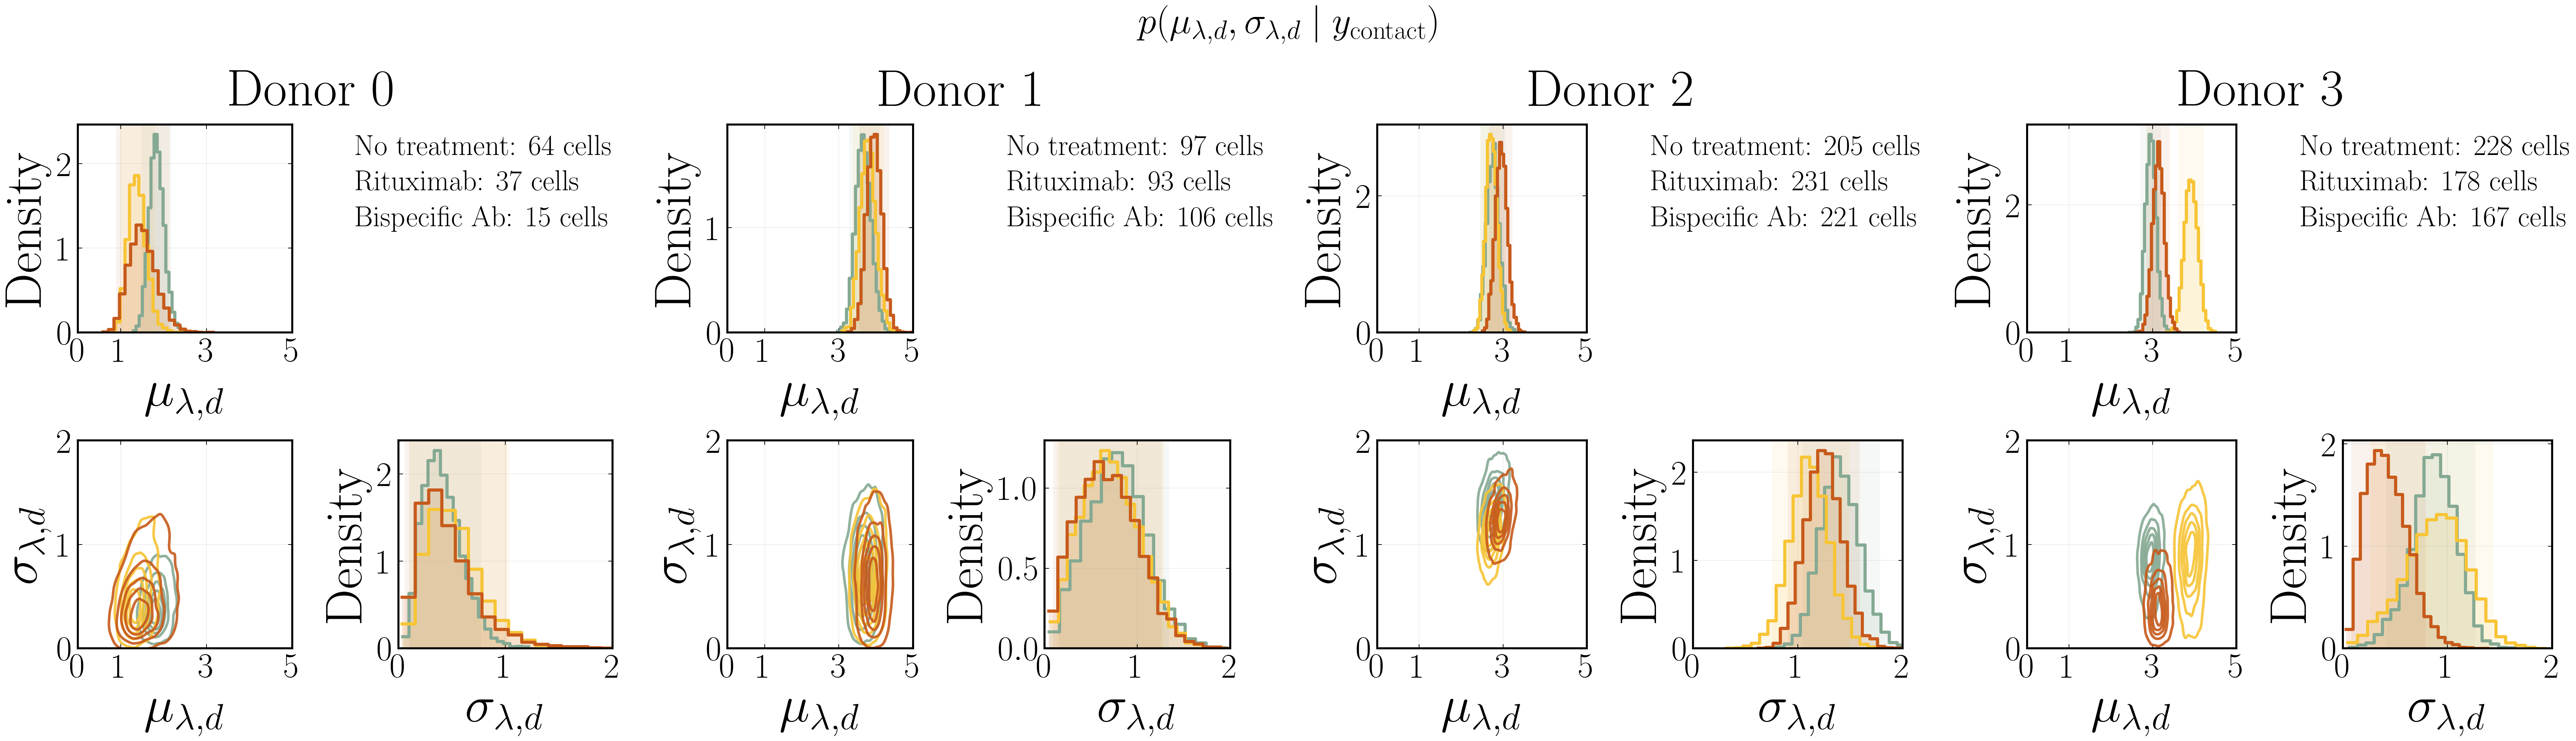

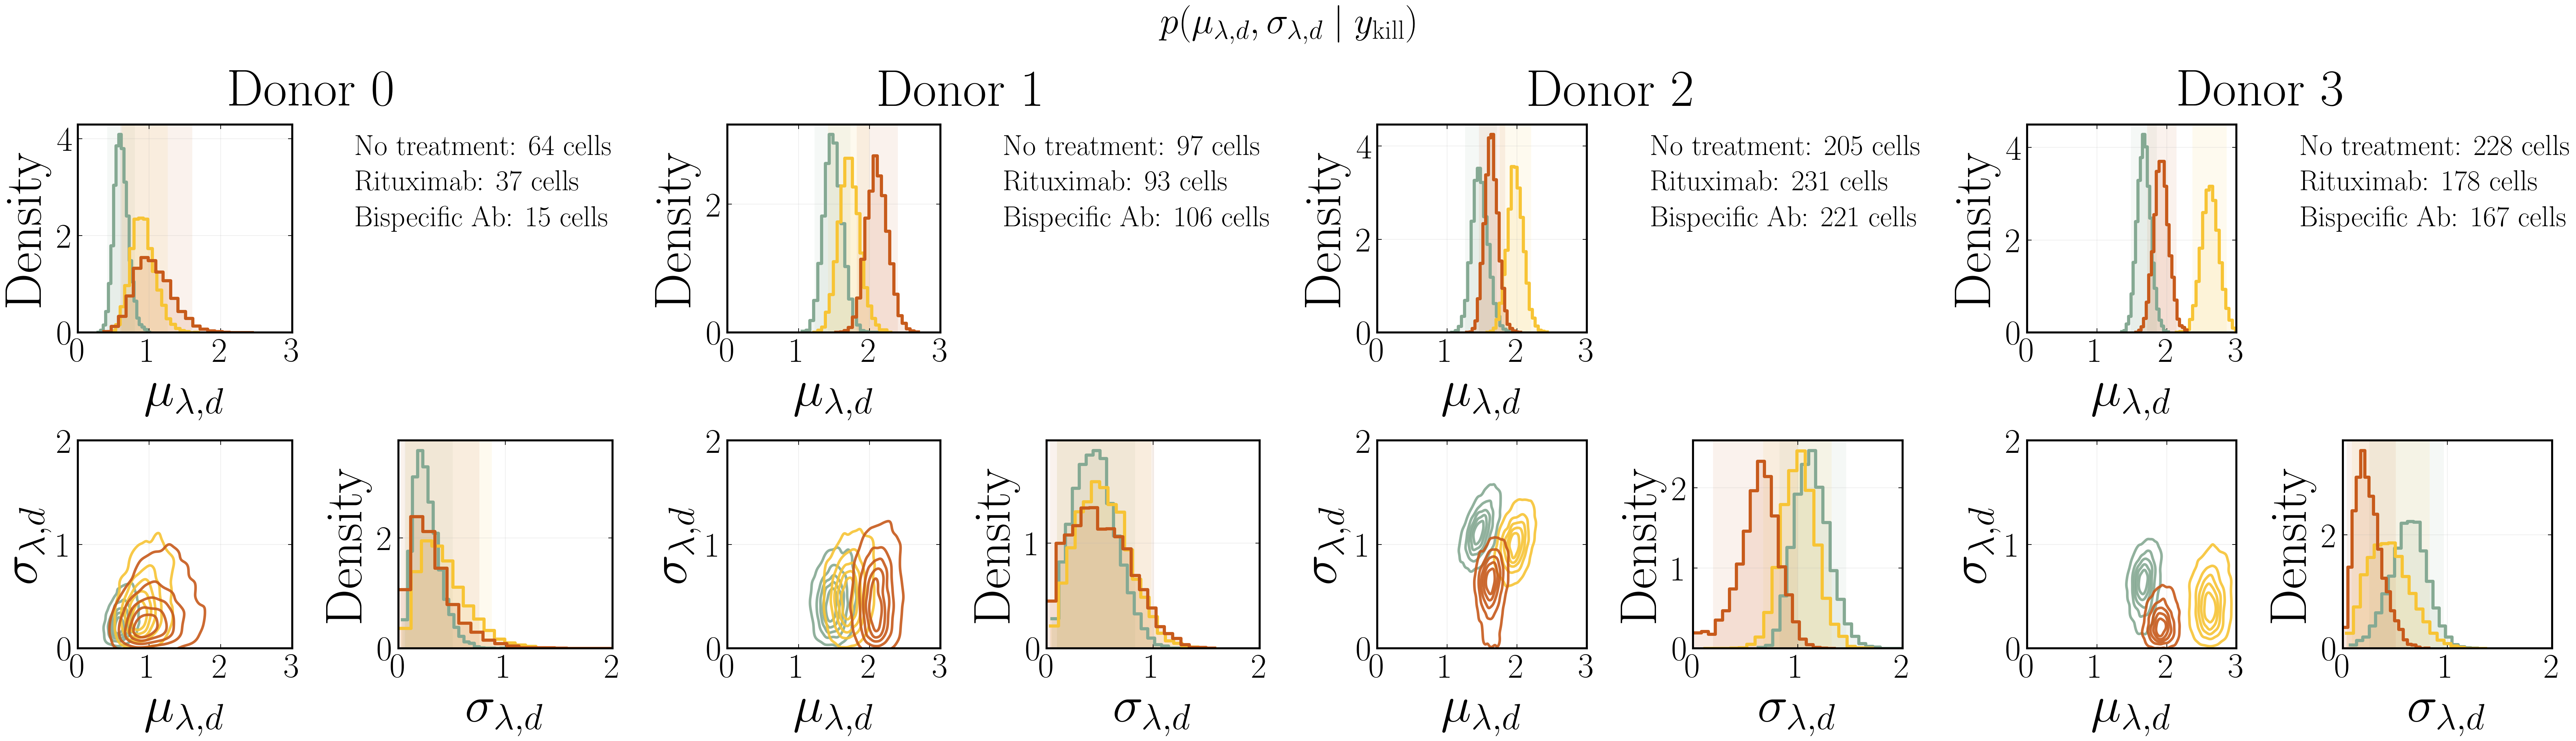

(PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/joint_posterior_all_donors_contacts_Dis2P.svg'),
 PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/joint_posterior_all_donors_kills_Dis2P.svg'))

In [56]:
DONOR_PARAMETER_LIMITS = {
    "contacts": {
        "mu_lambda": (0.0, 5.0),
        "sigma_lambda": (0.0, 2.0),
    },
    "kills": {
        "mu_lambda": (0.0, 3.0),
        "sigma_lambda": (0.0, 2.0),
    },
}

DONOR_PARAMETER_TICKS = {
    "contacts": {
        "mu_lambda": [0, 1, 3, 5],
        "sigma_lambda": [0, 1.0, 2.0],
    },
    "kills": {
        "mu_lambda": [0, 1, 2, 3],
        "sigma_lambda": [0, 1.0, 2.0],
    },
}

CONTACTS_DONOR_JOINT_PATH = plot_all_donors_joint_posterior(
    posterior_data,
    outcome="contacts",
    model_name="Dis2P",
    param_limits=DONOR_PARAMETER_LIMITS["contacts"],
    param_ticks=DONOR_PARAMETER_TICKS["contacts"],
)

KILLS_DONOR_JOINT_PATH = plot_all_donors_joint_posterior(
    posterior_data,
    outcome="kills",
    model_name="Dis2P",
    param_limits=DONOR_PARAMETER_LIMITS["kills"],
    param_ticks=DONOR_PARAMETER_TICKS["kills"],
)

CONTACTS_DONOR_JOINT_PATH, KILLS_DONOR_JOINT_PATH

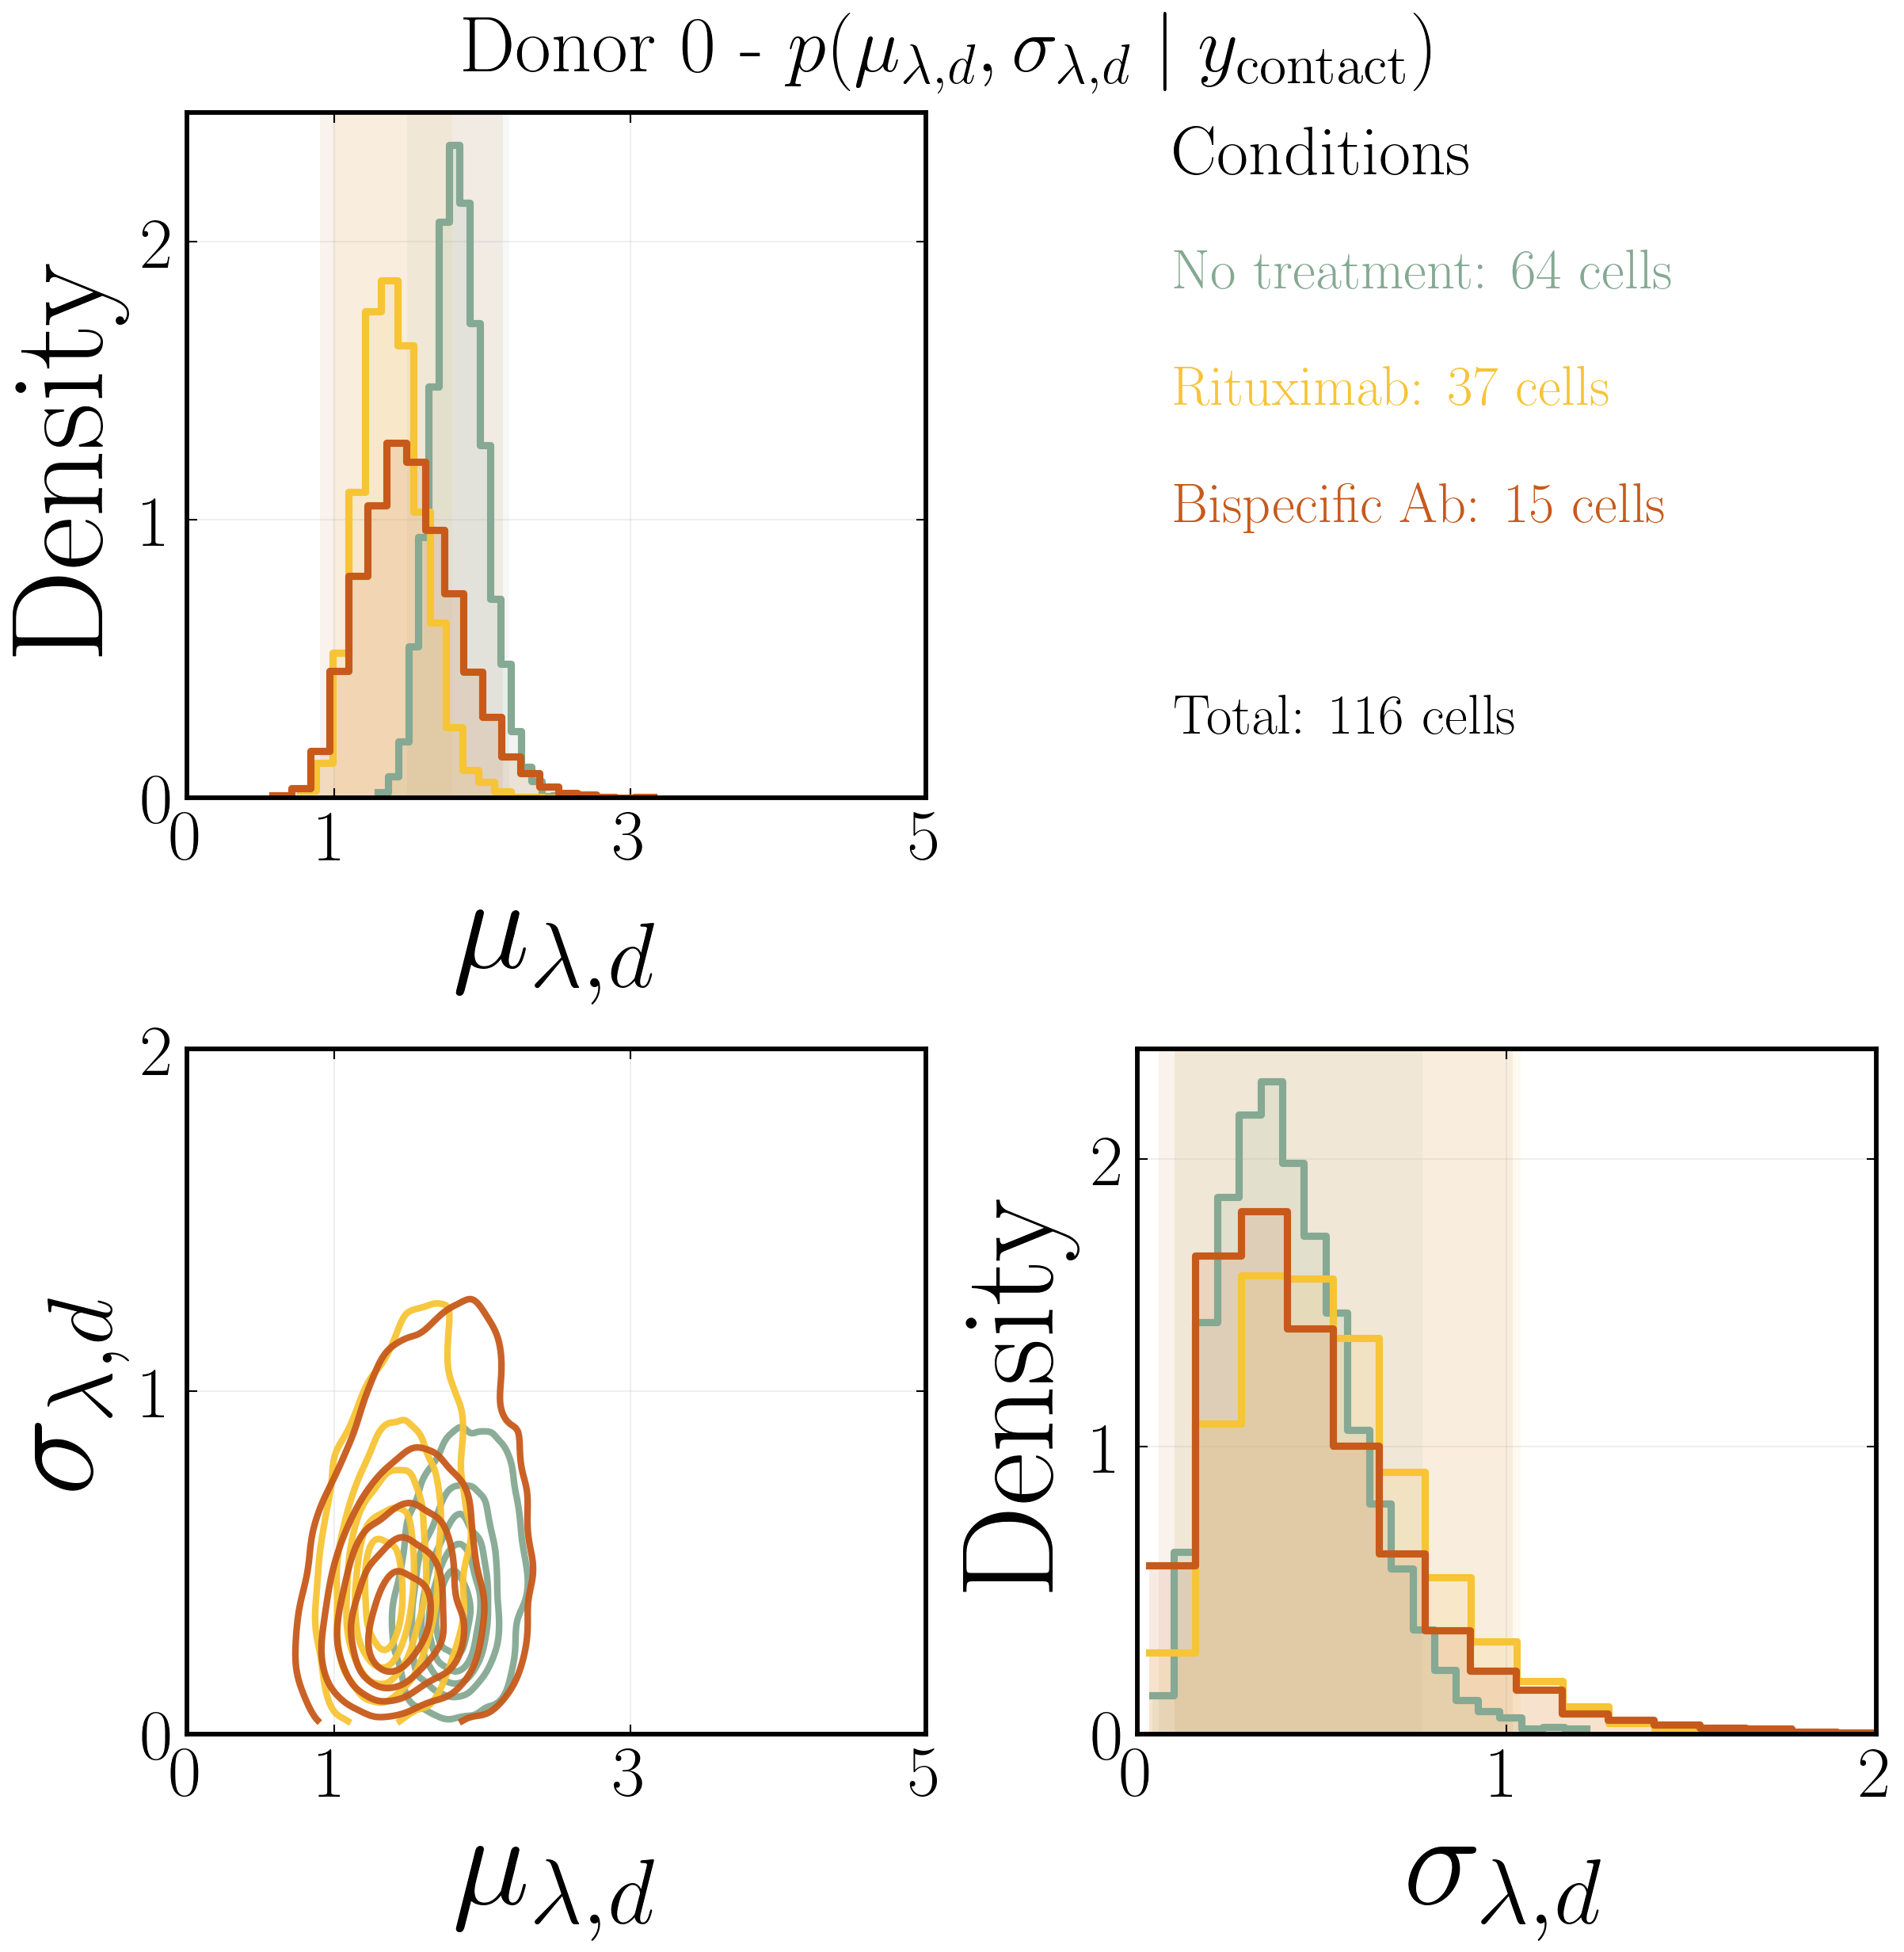

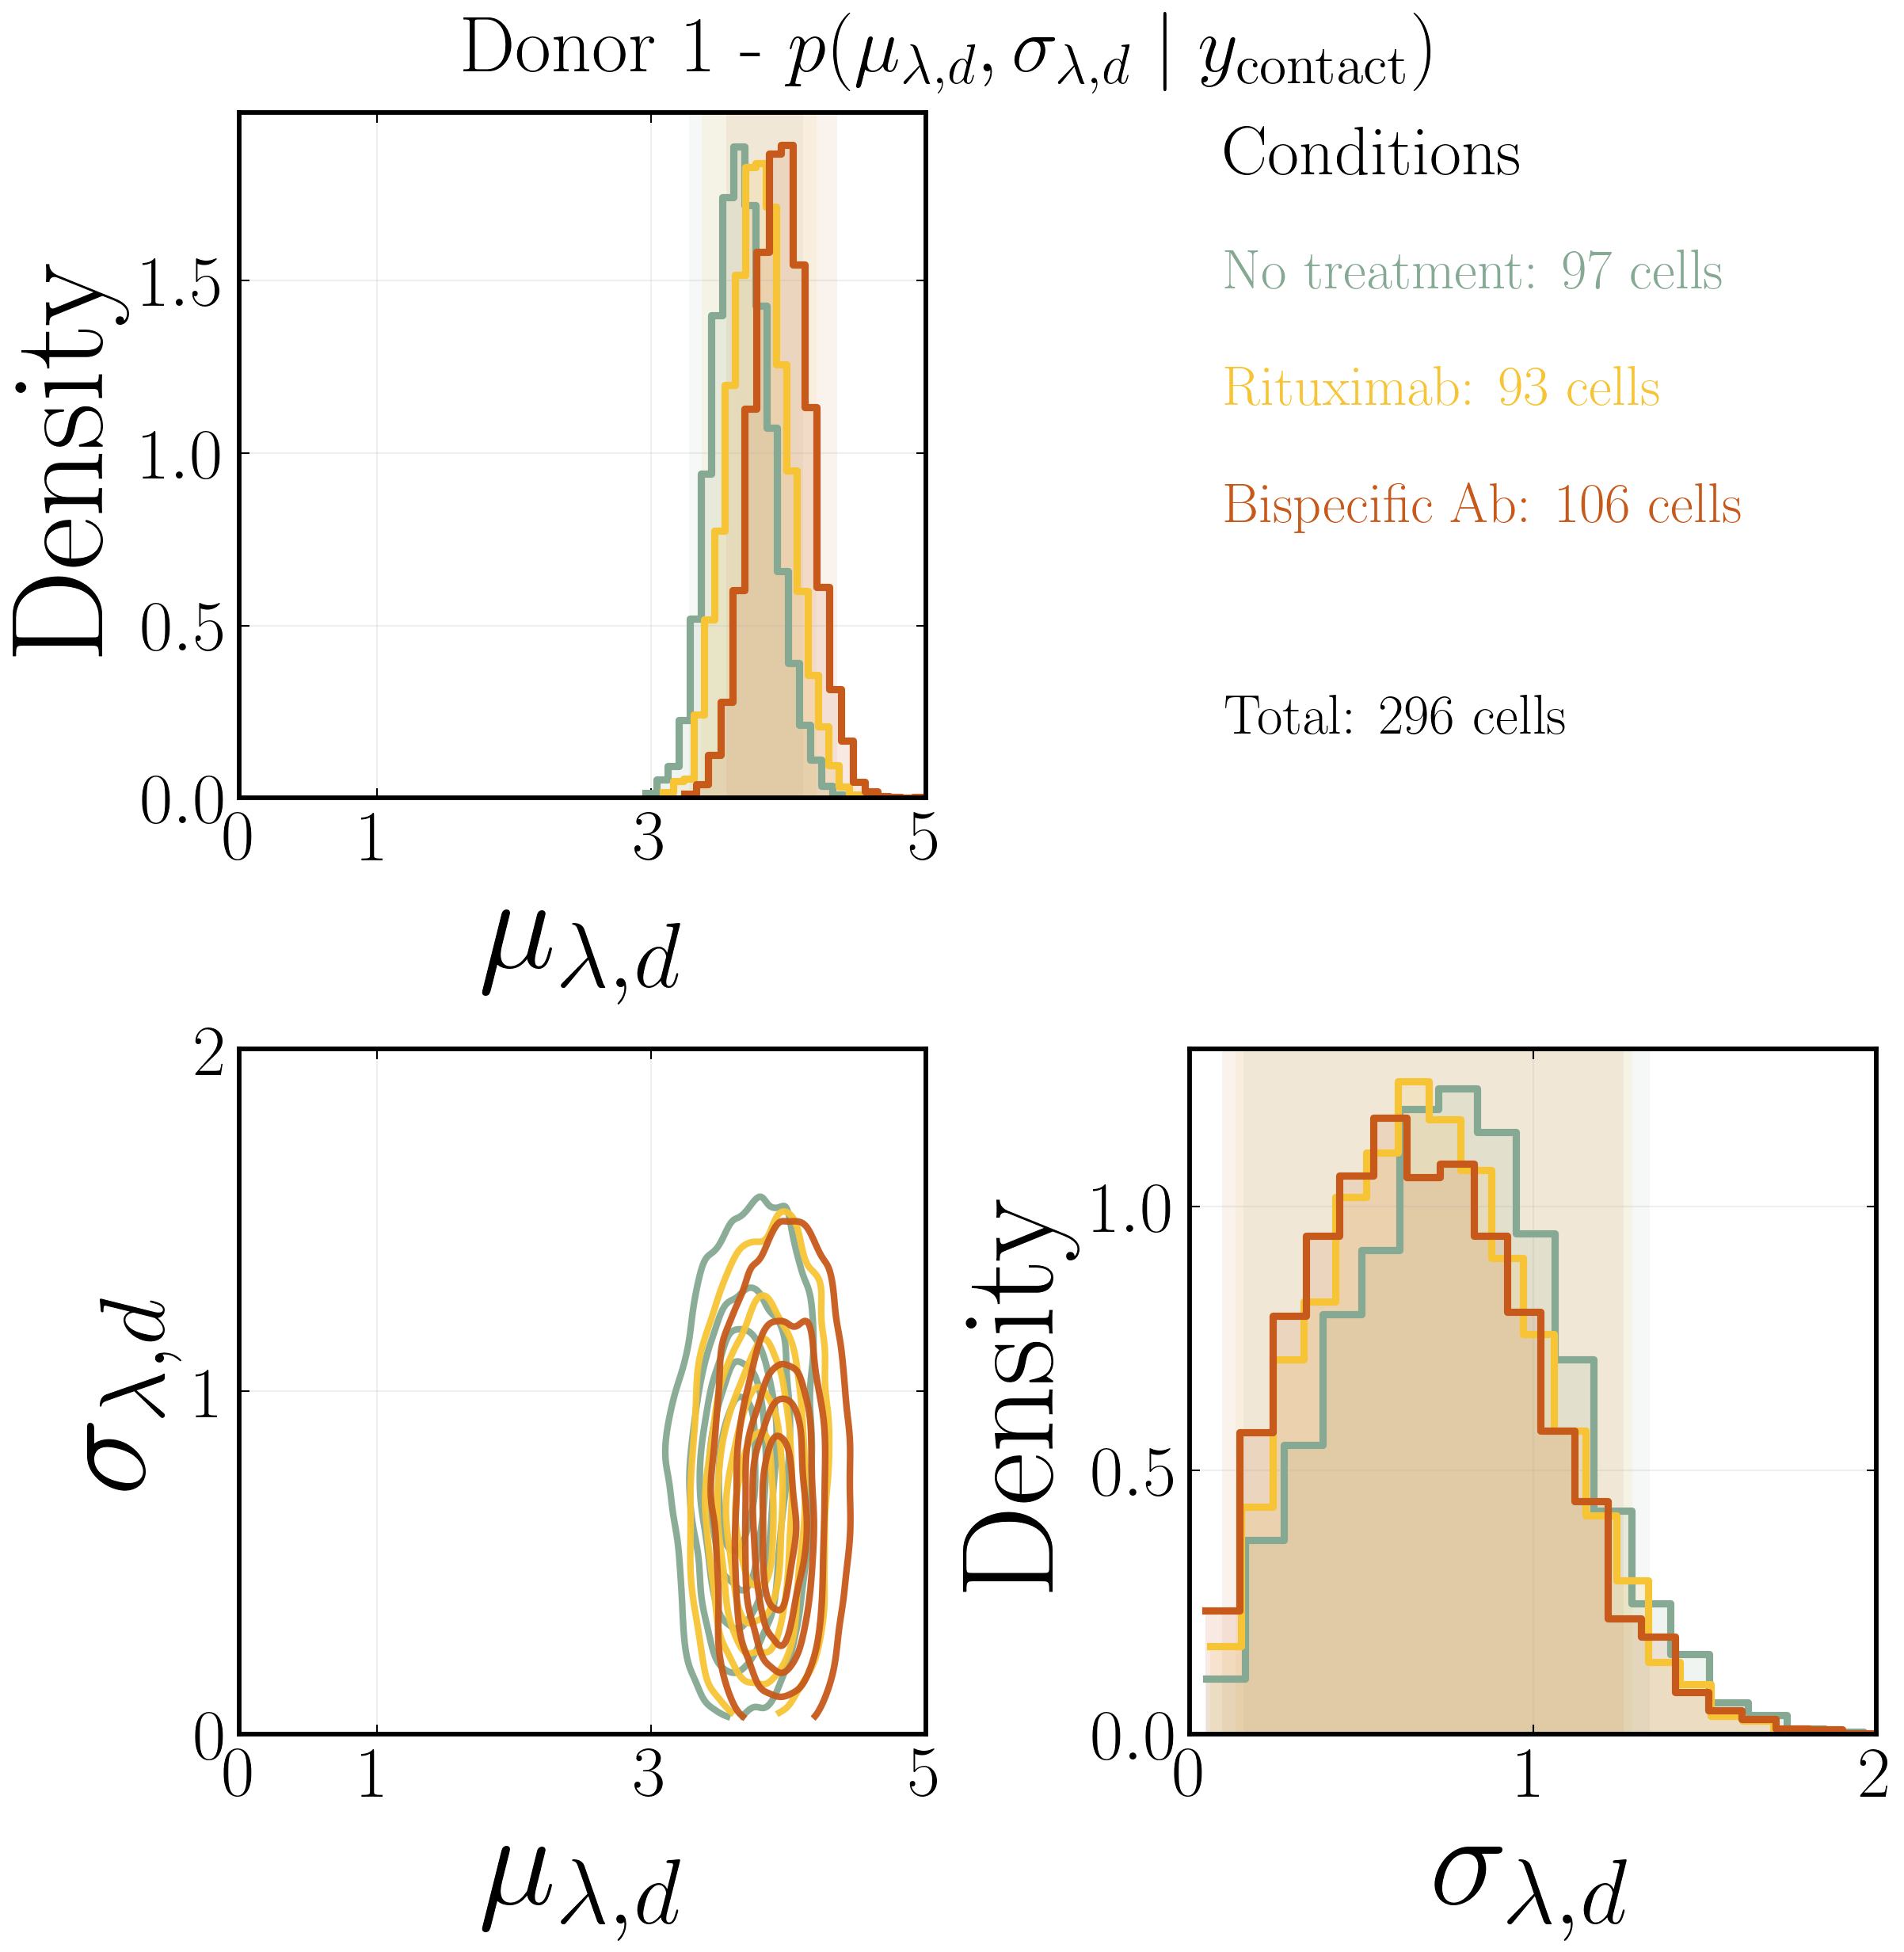

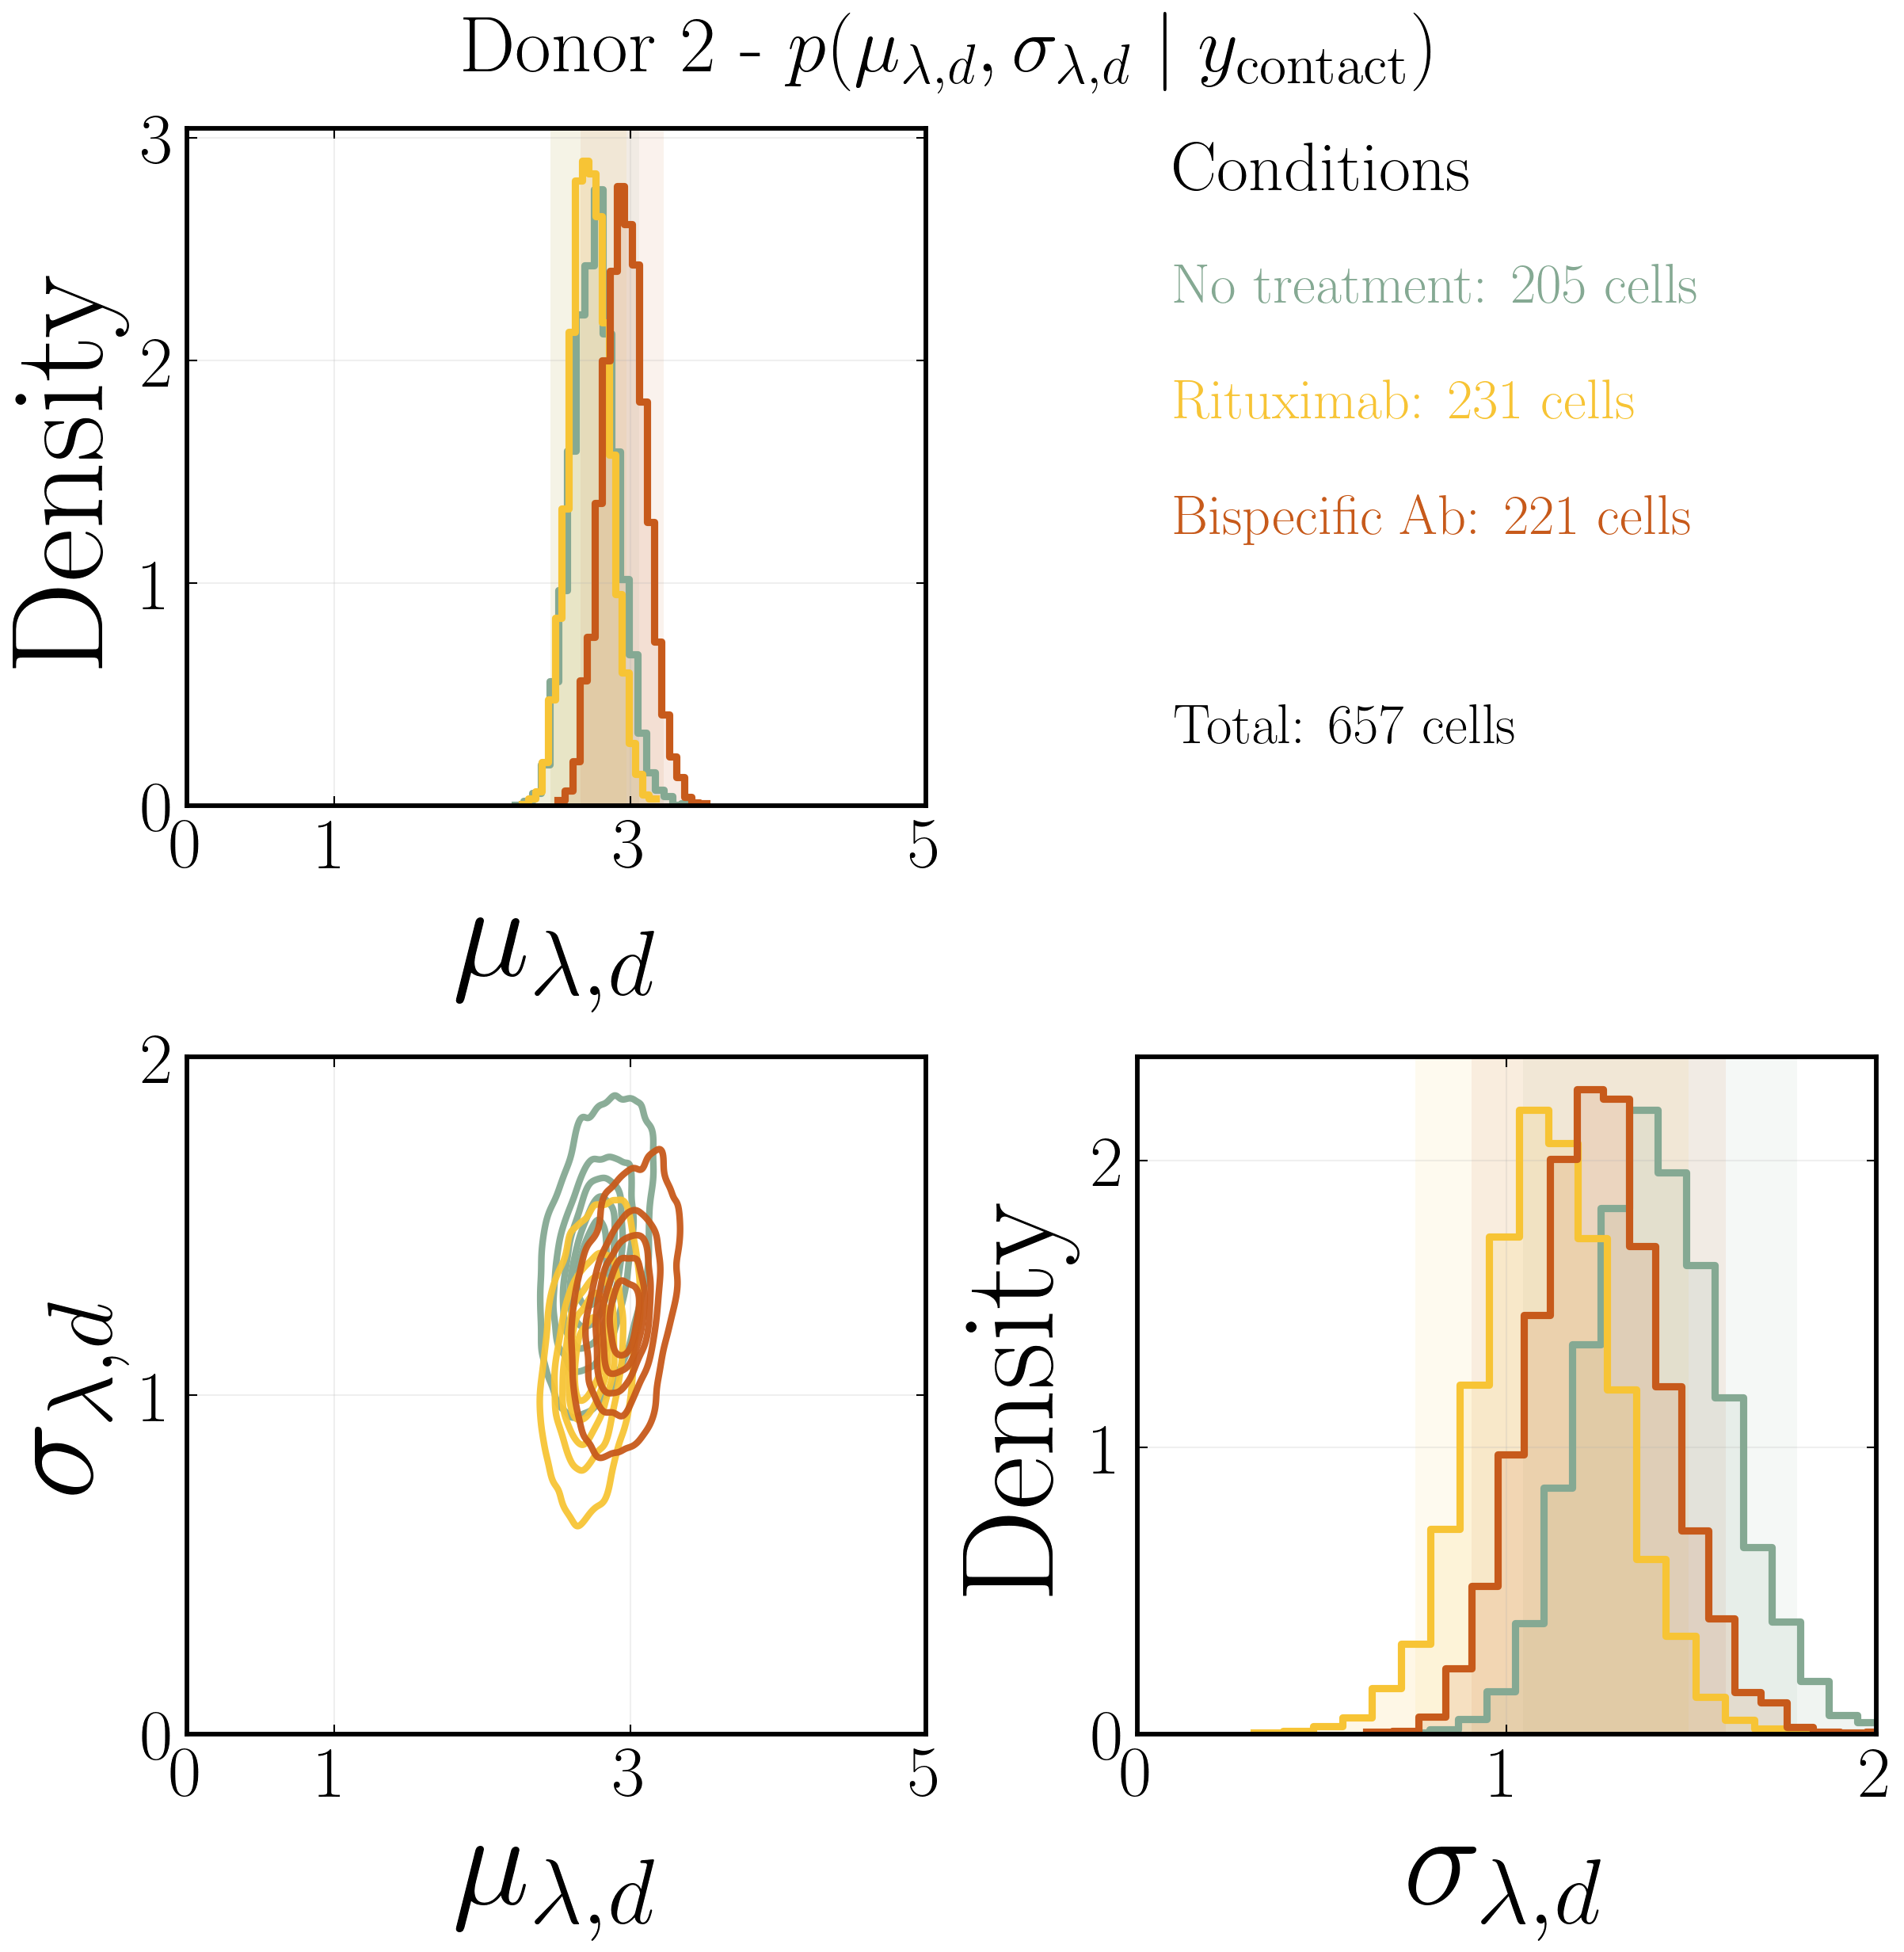

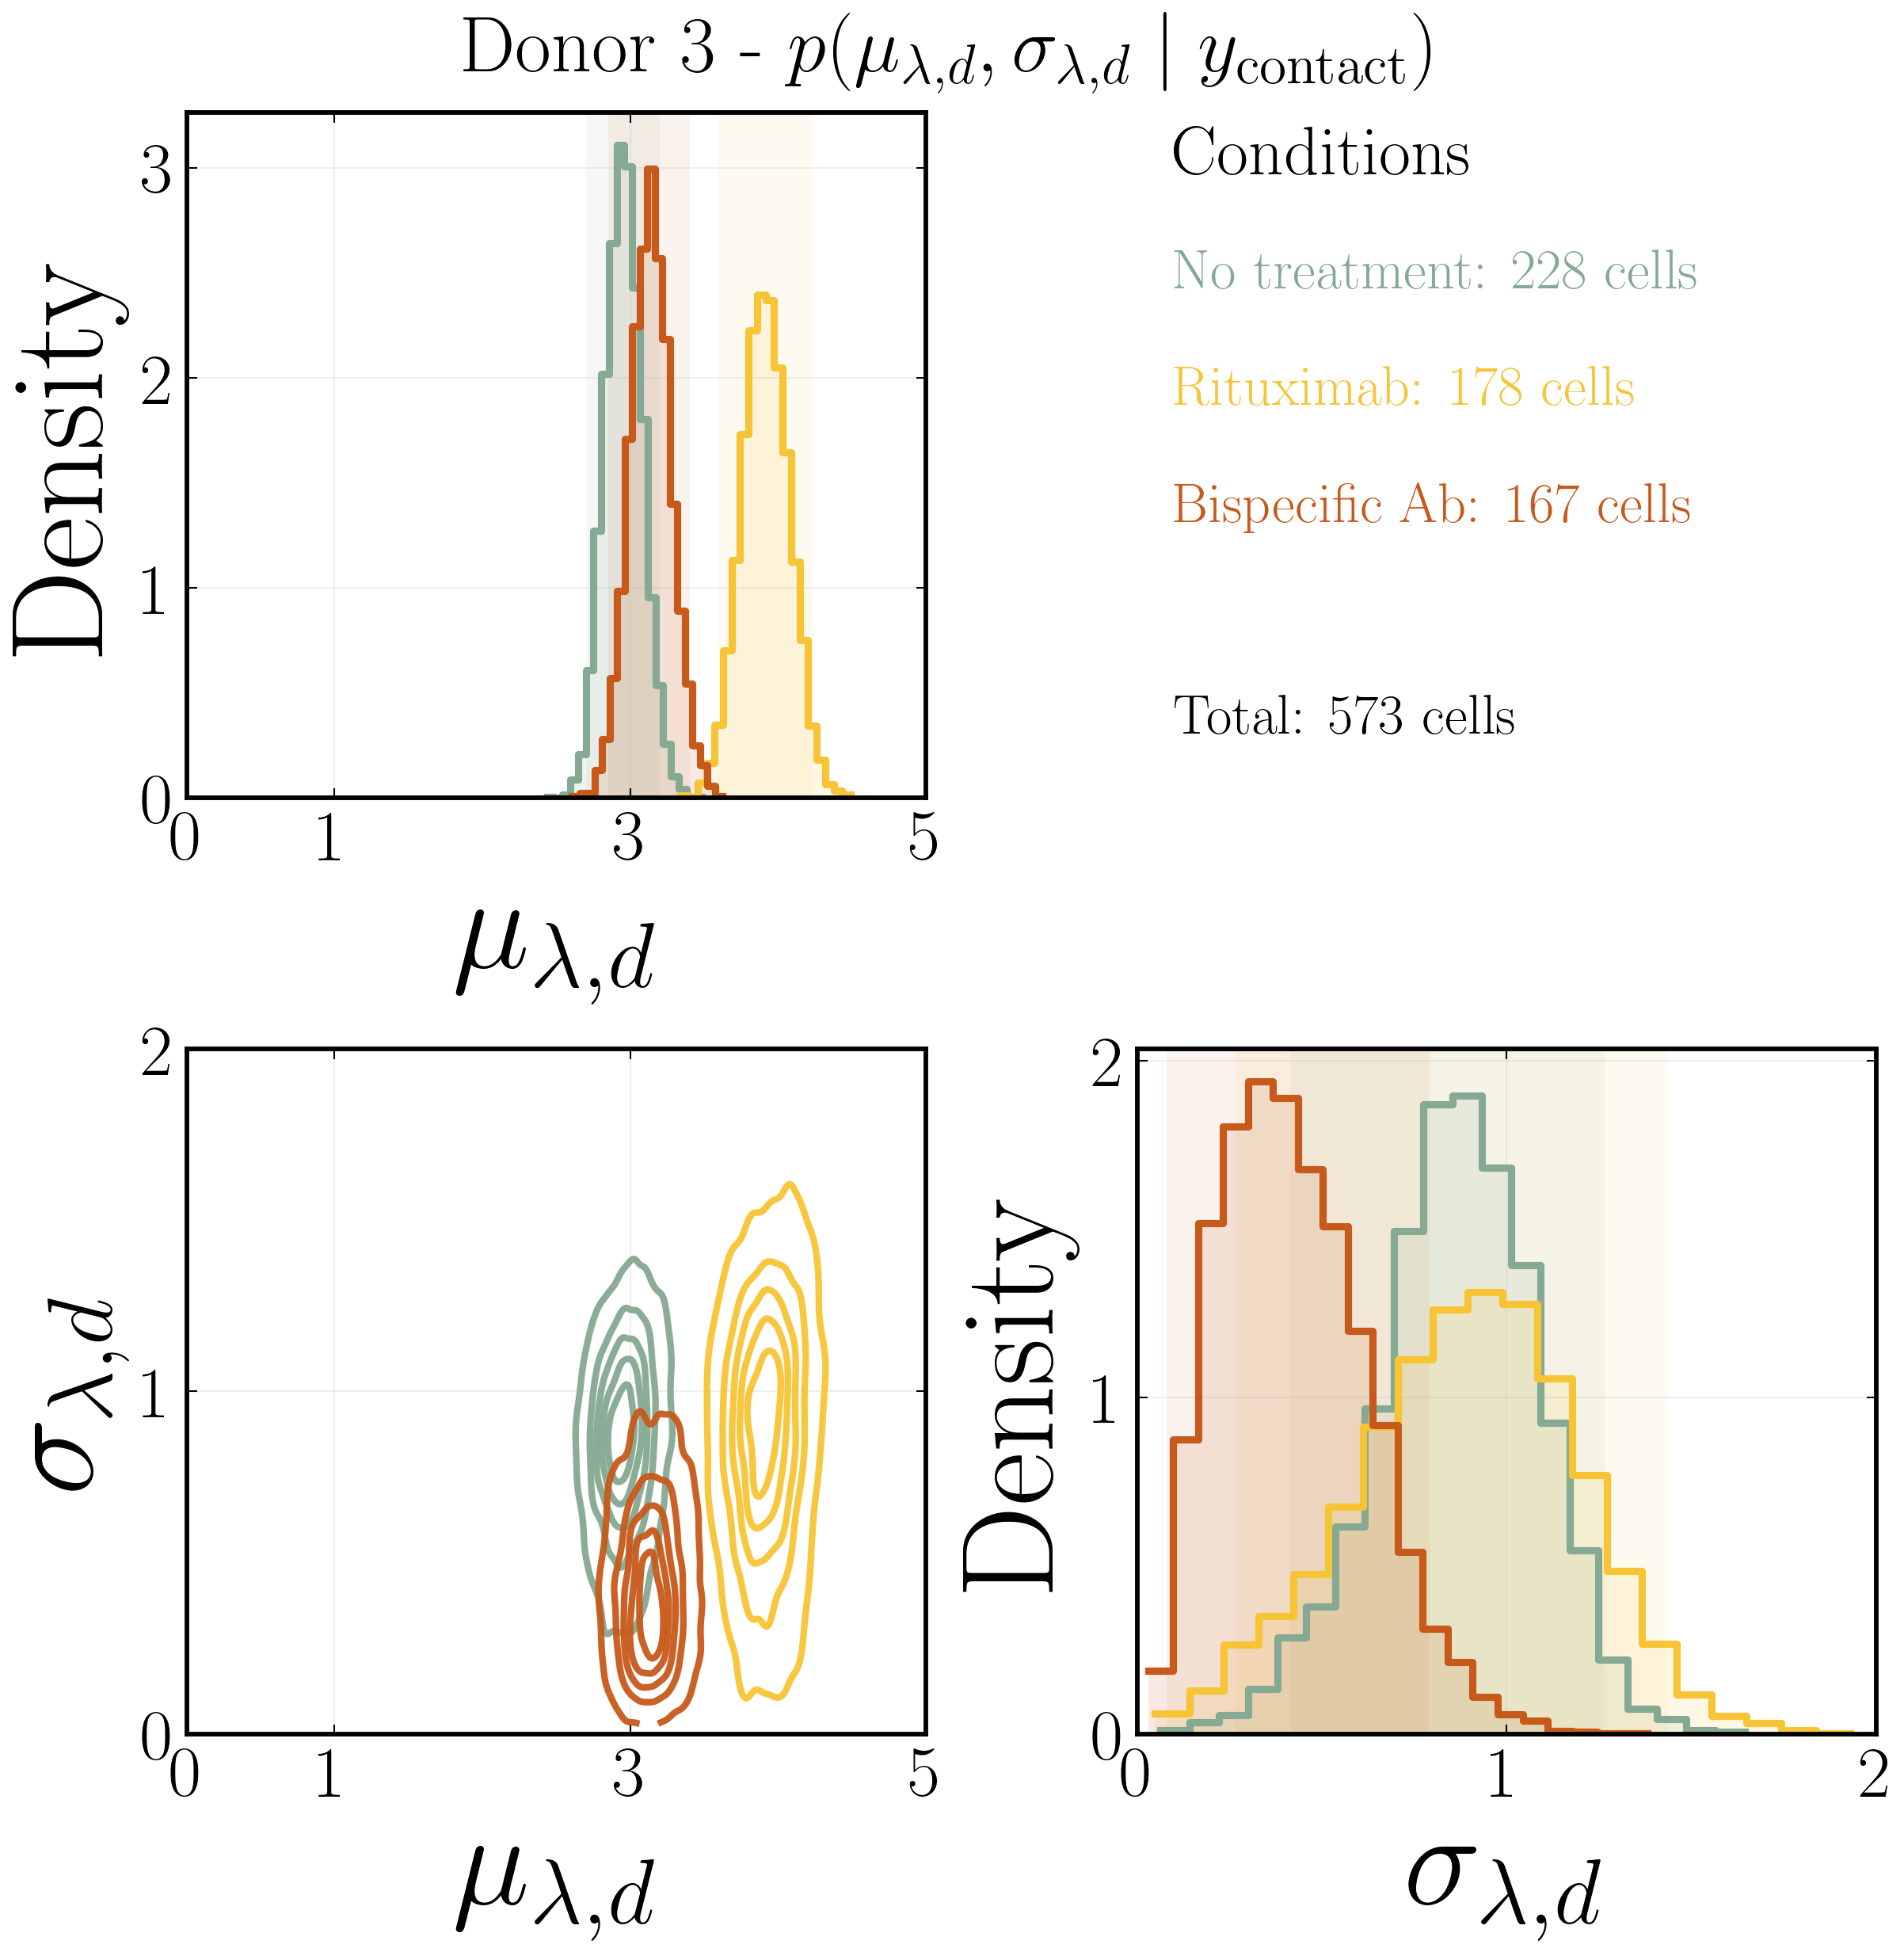

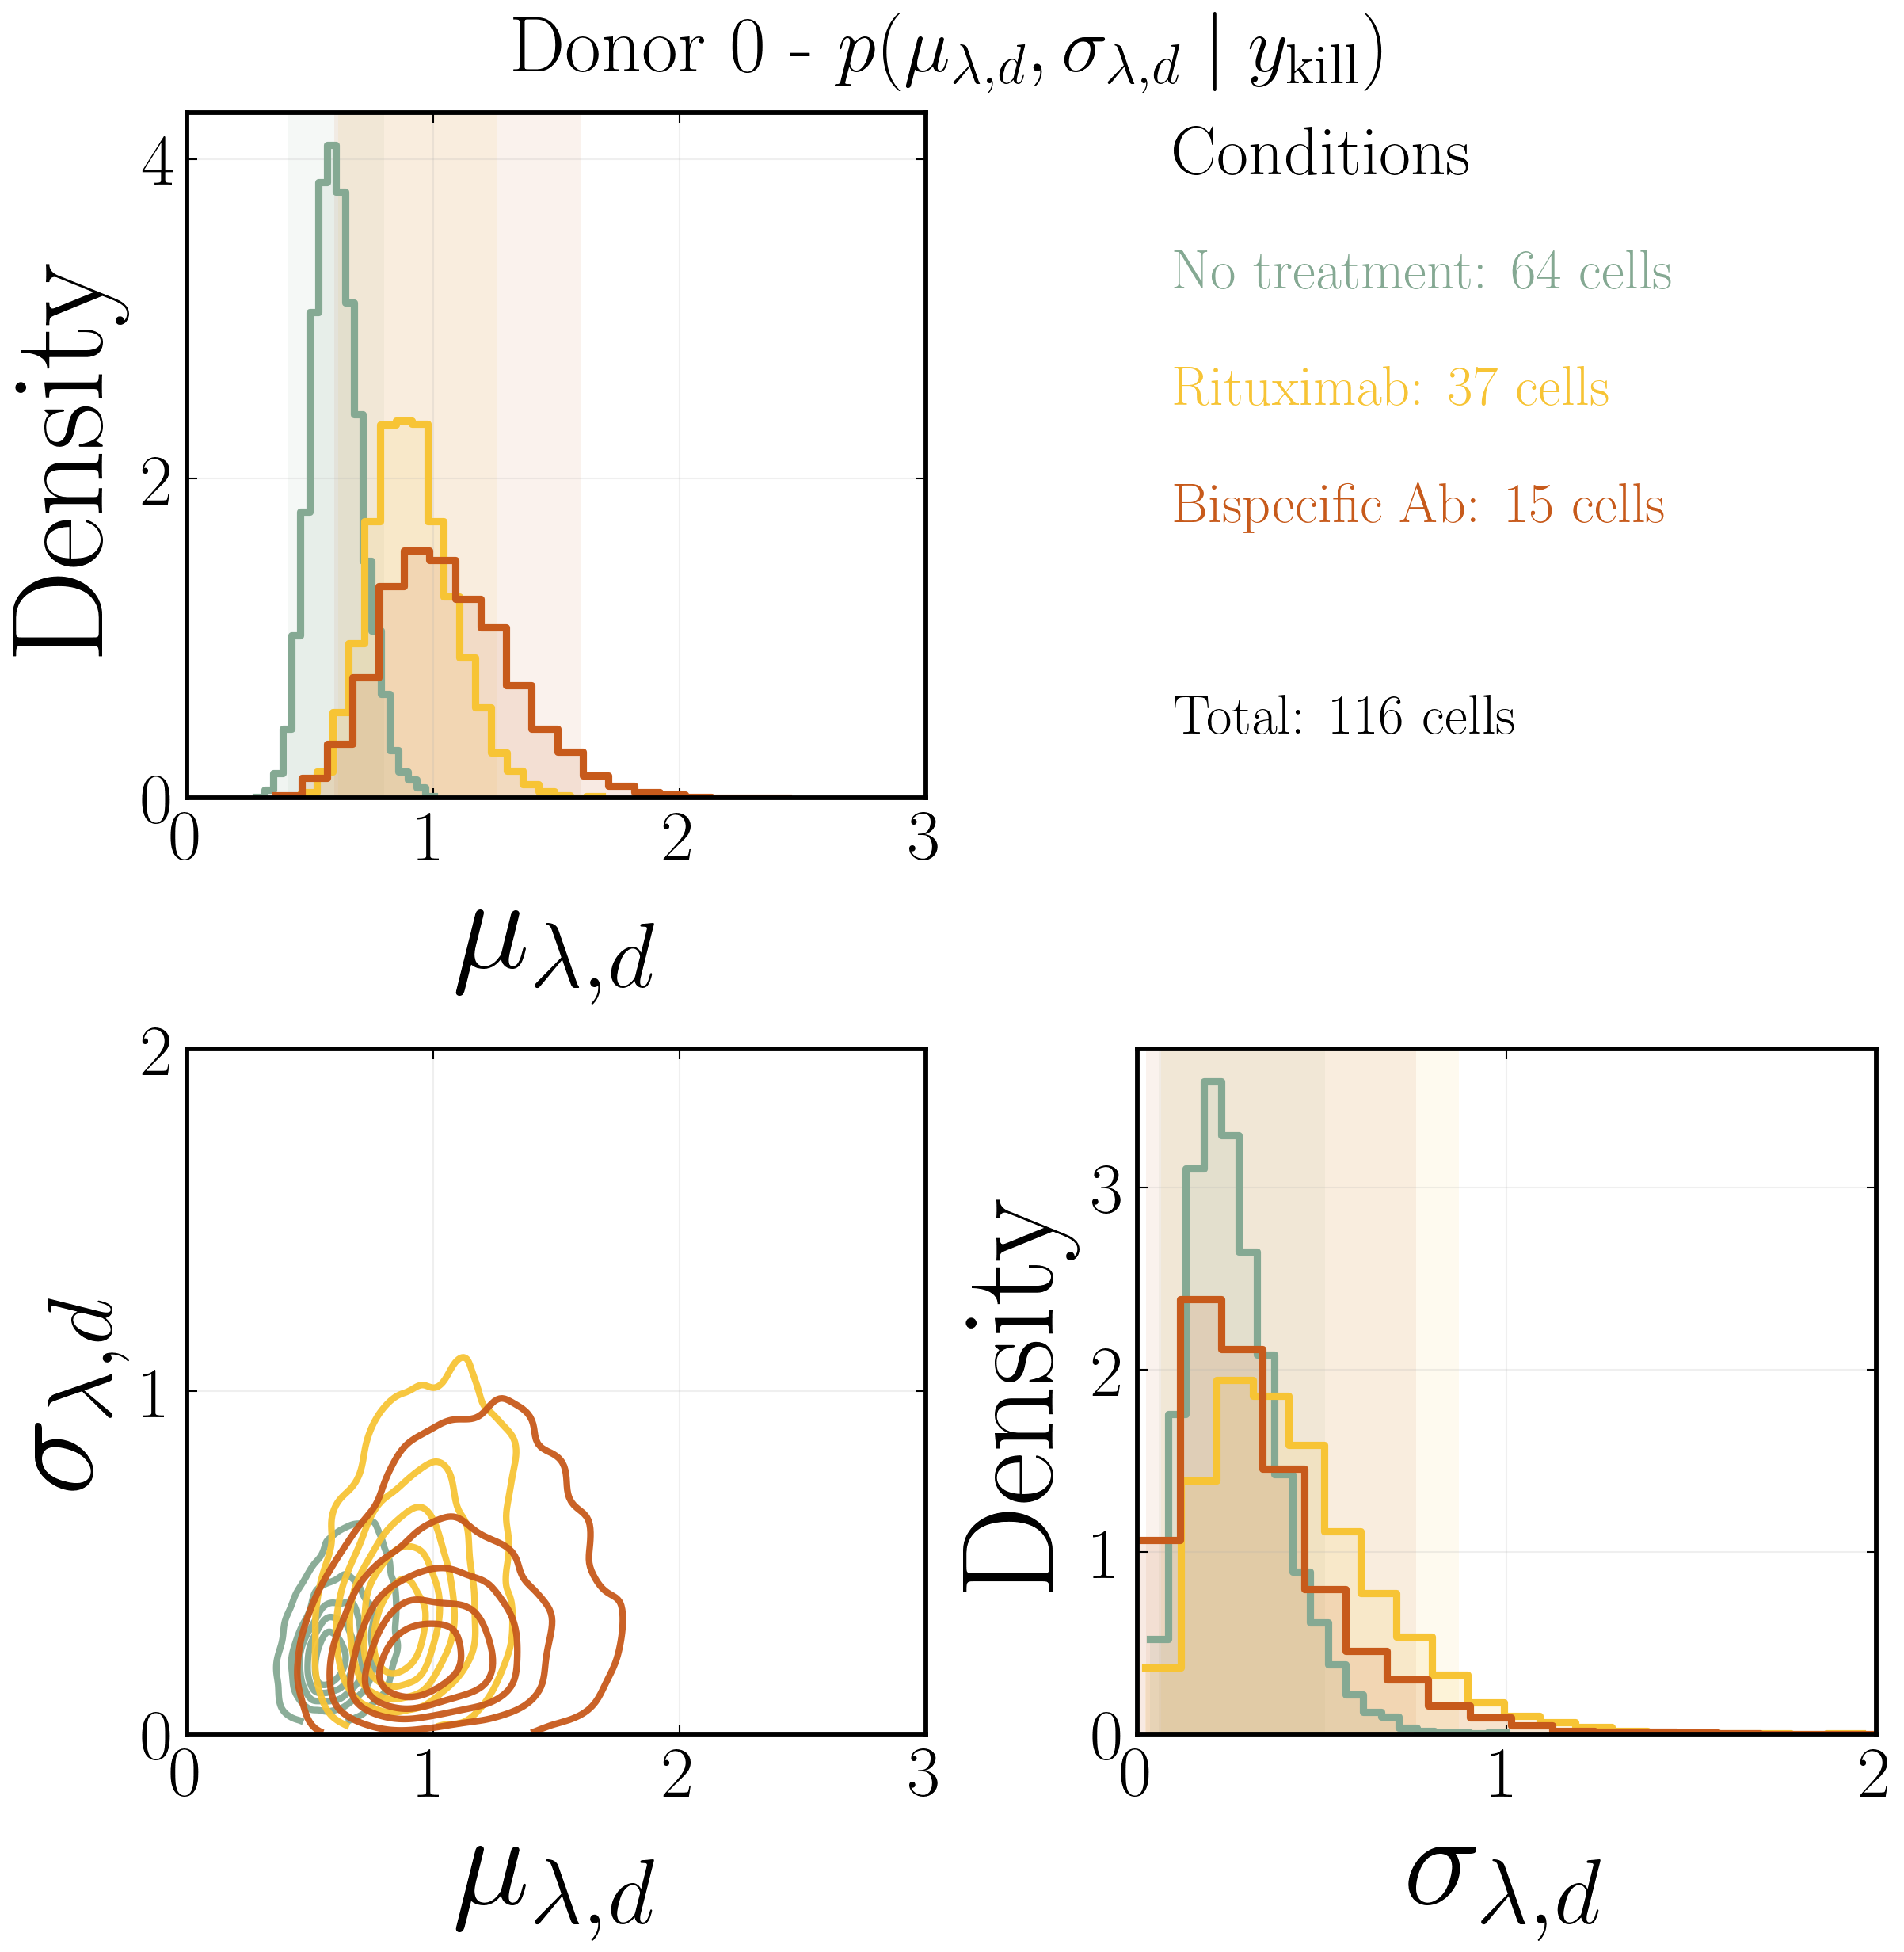

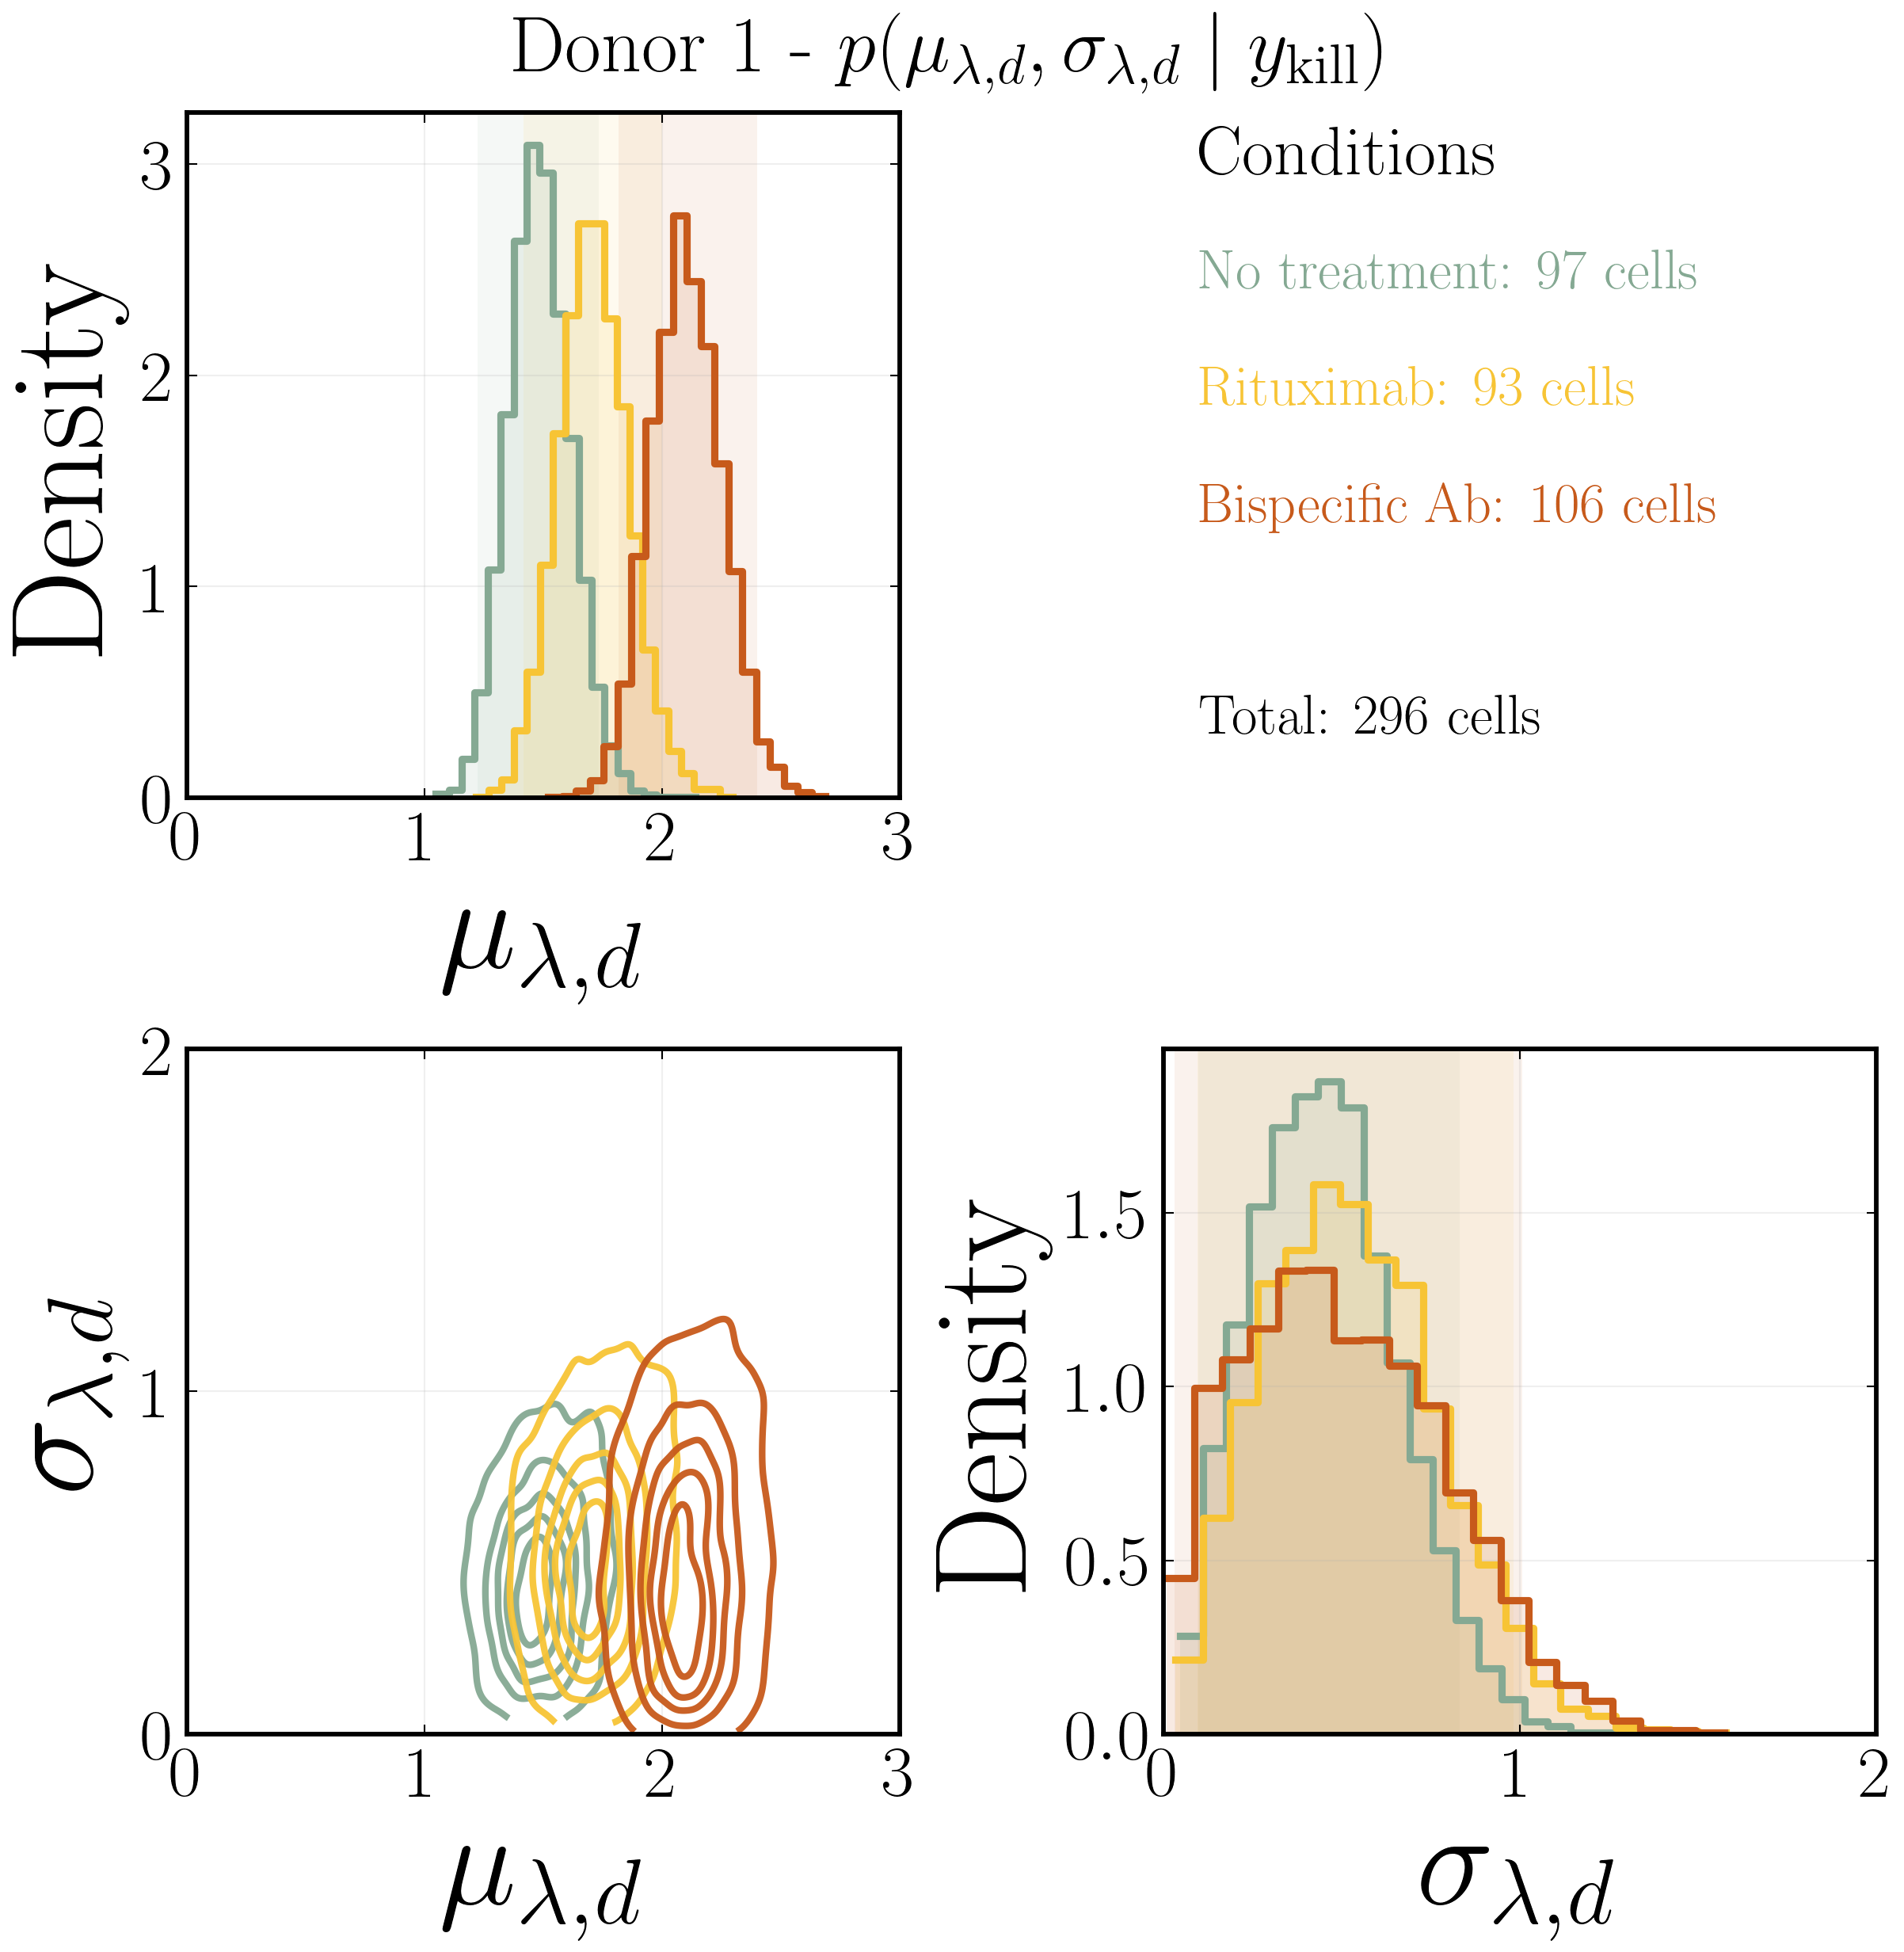

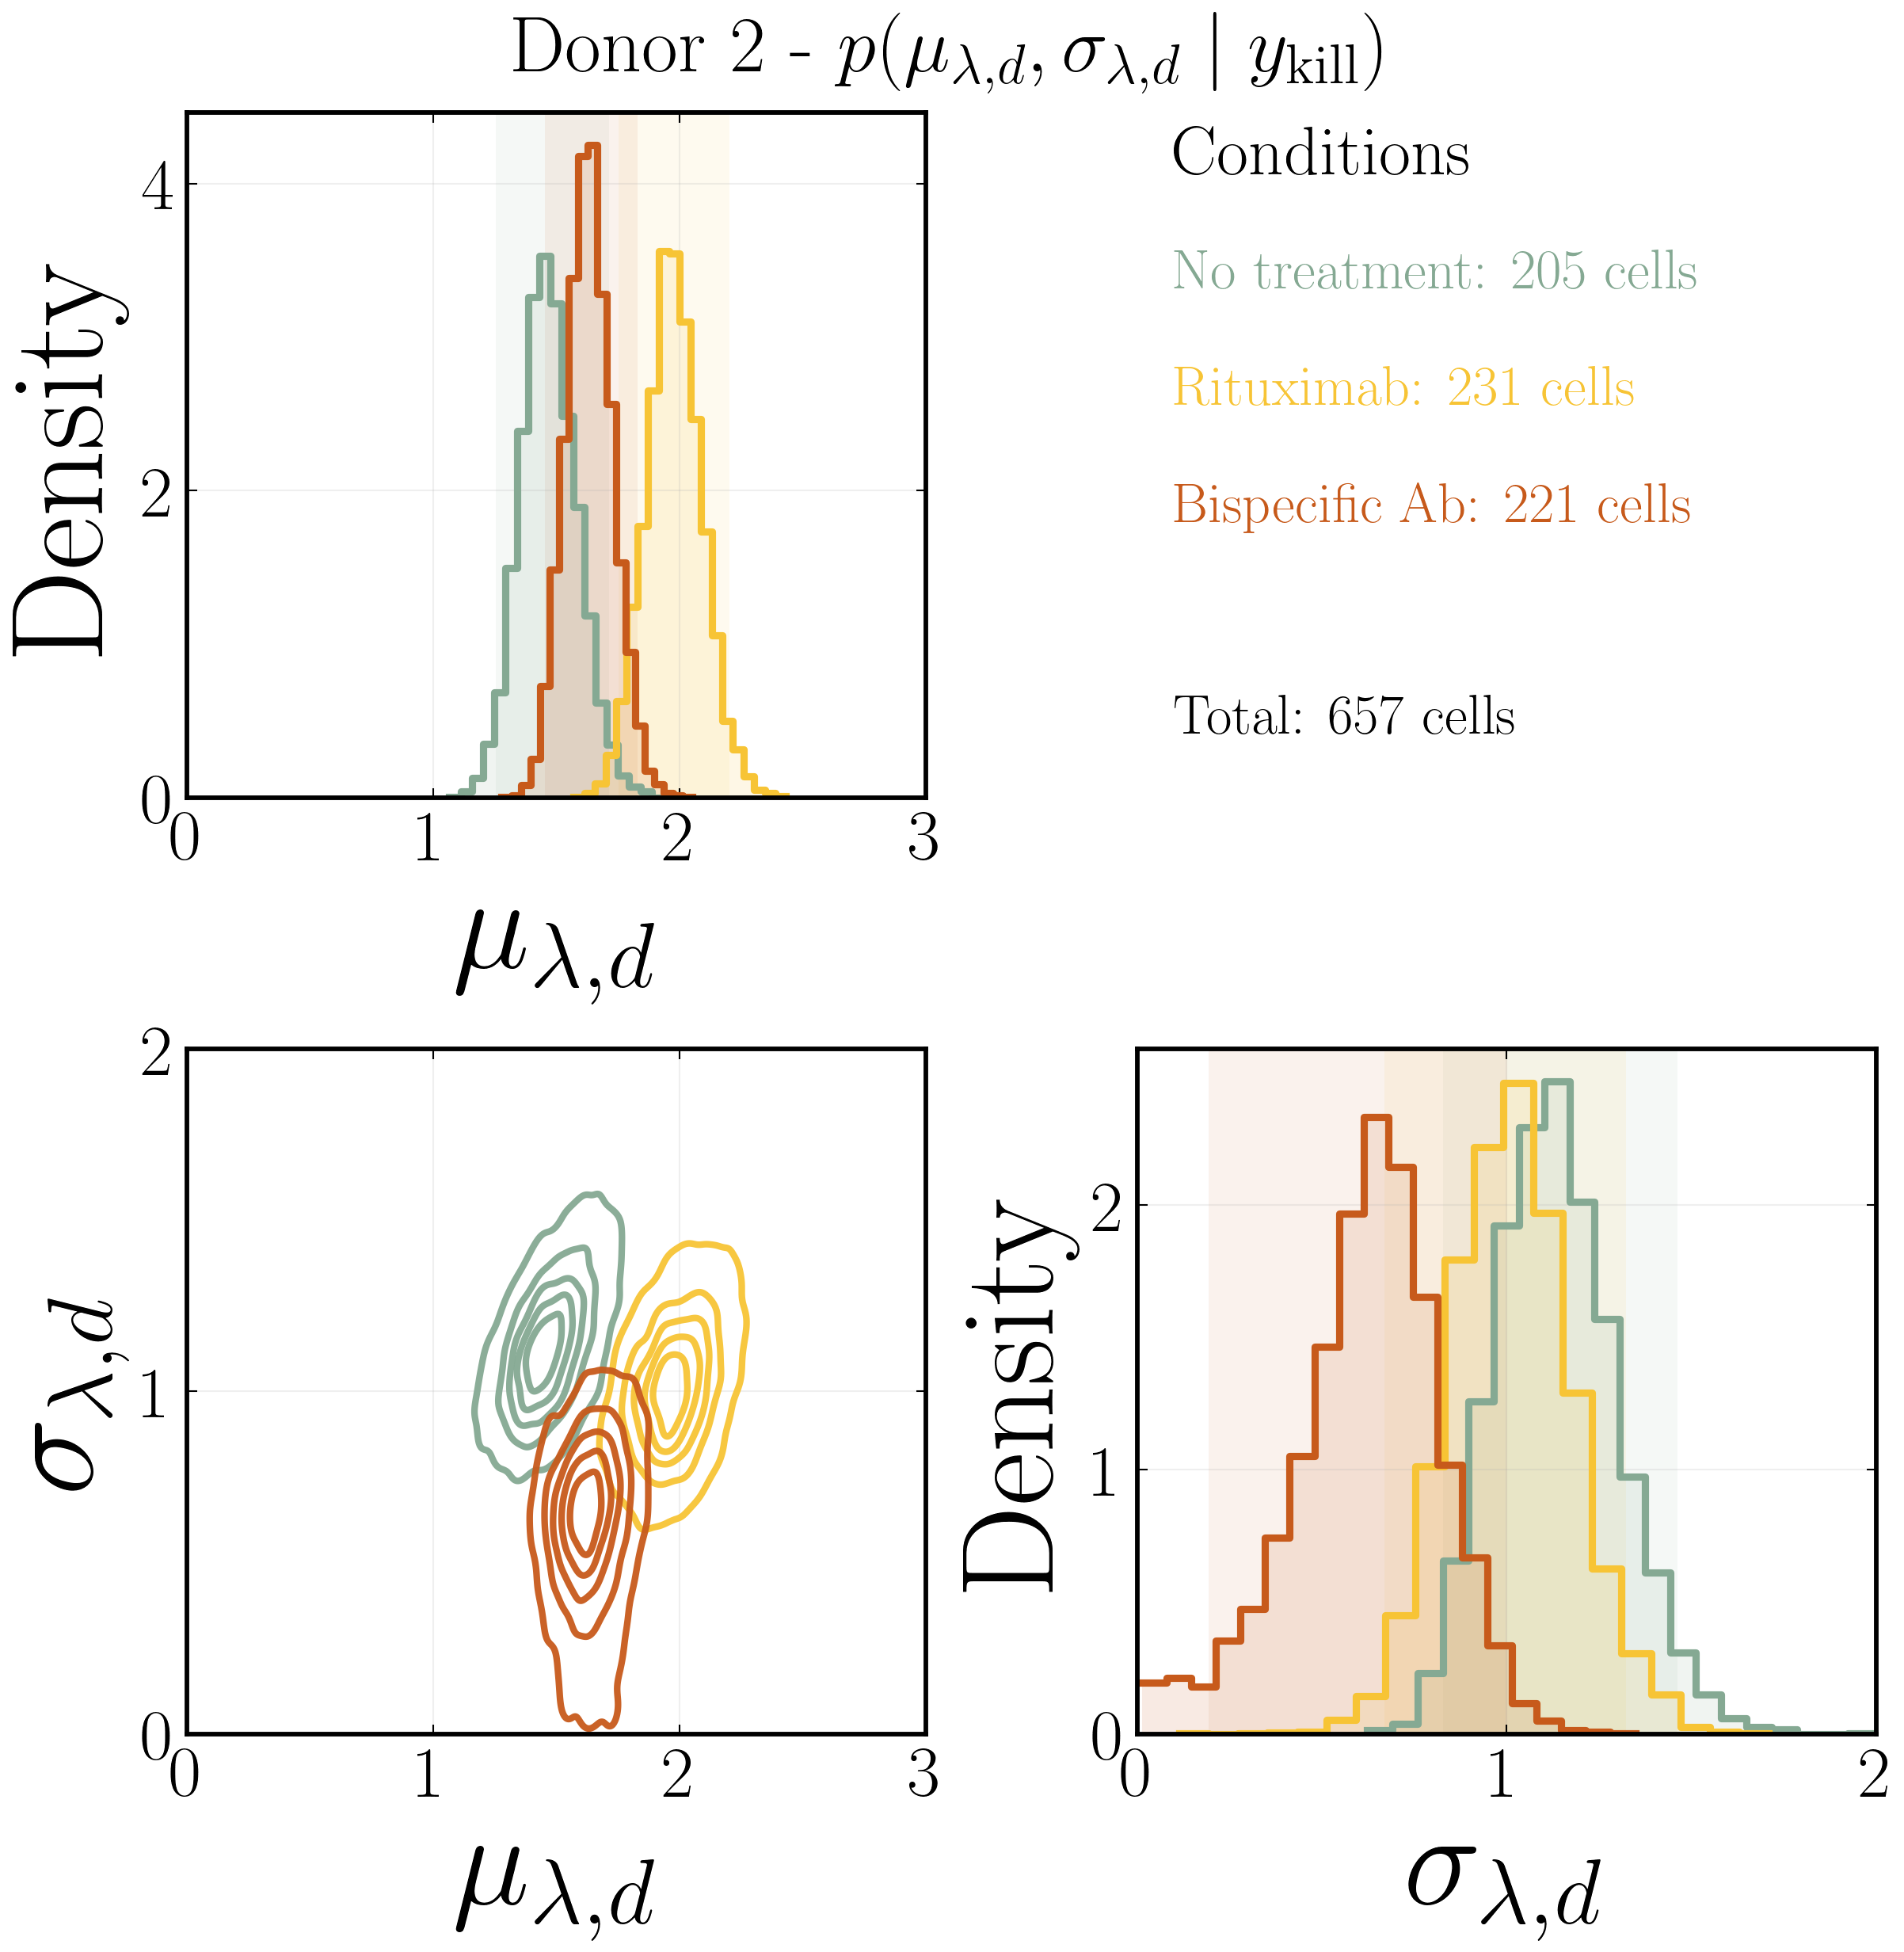

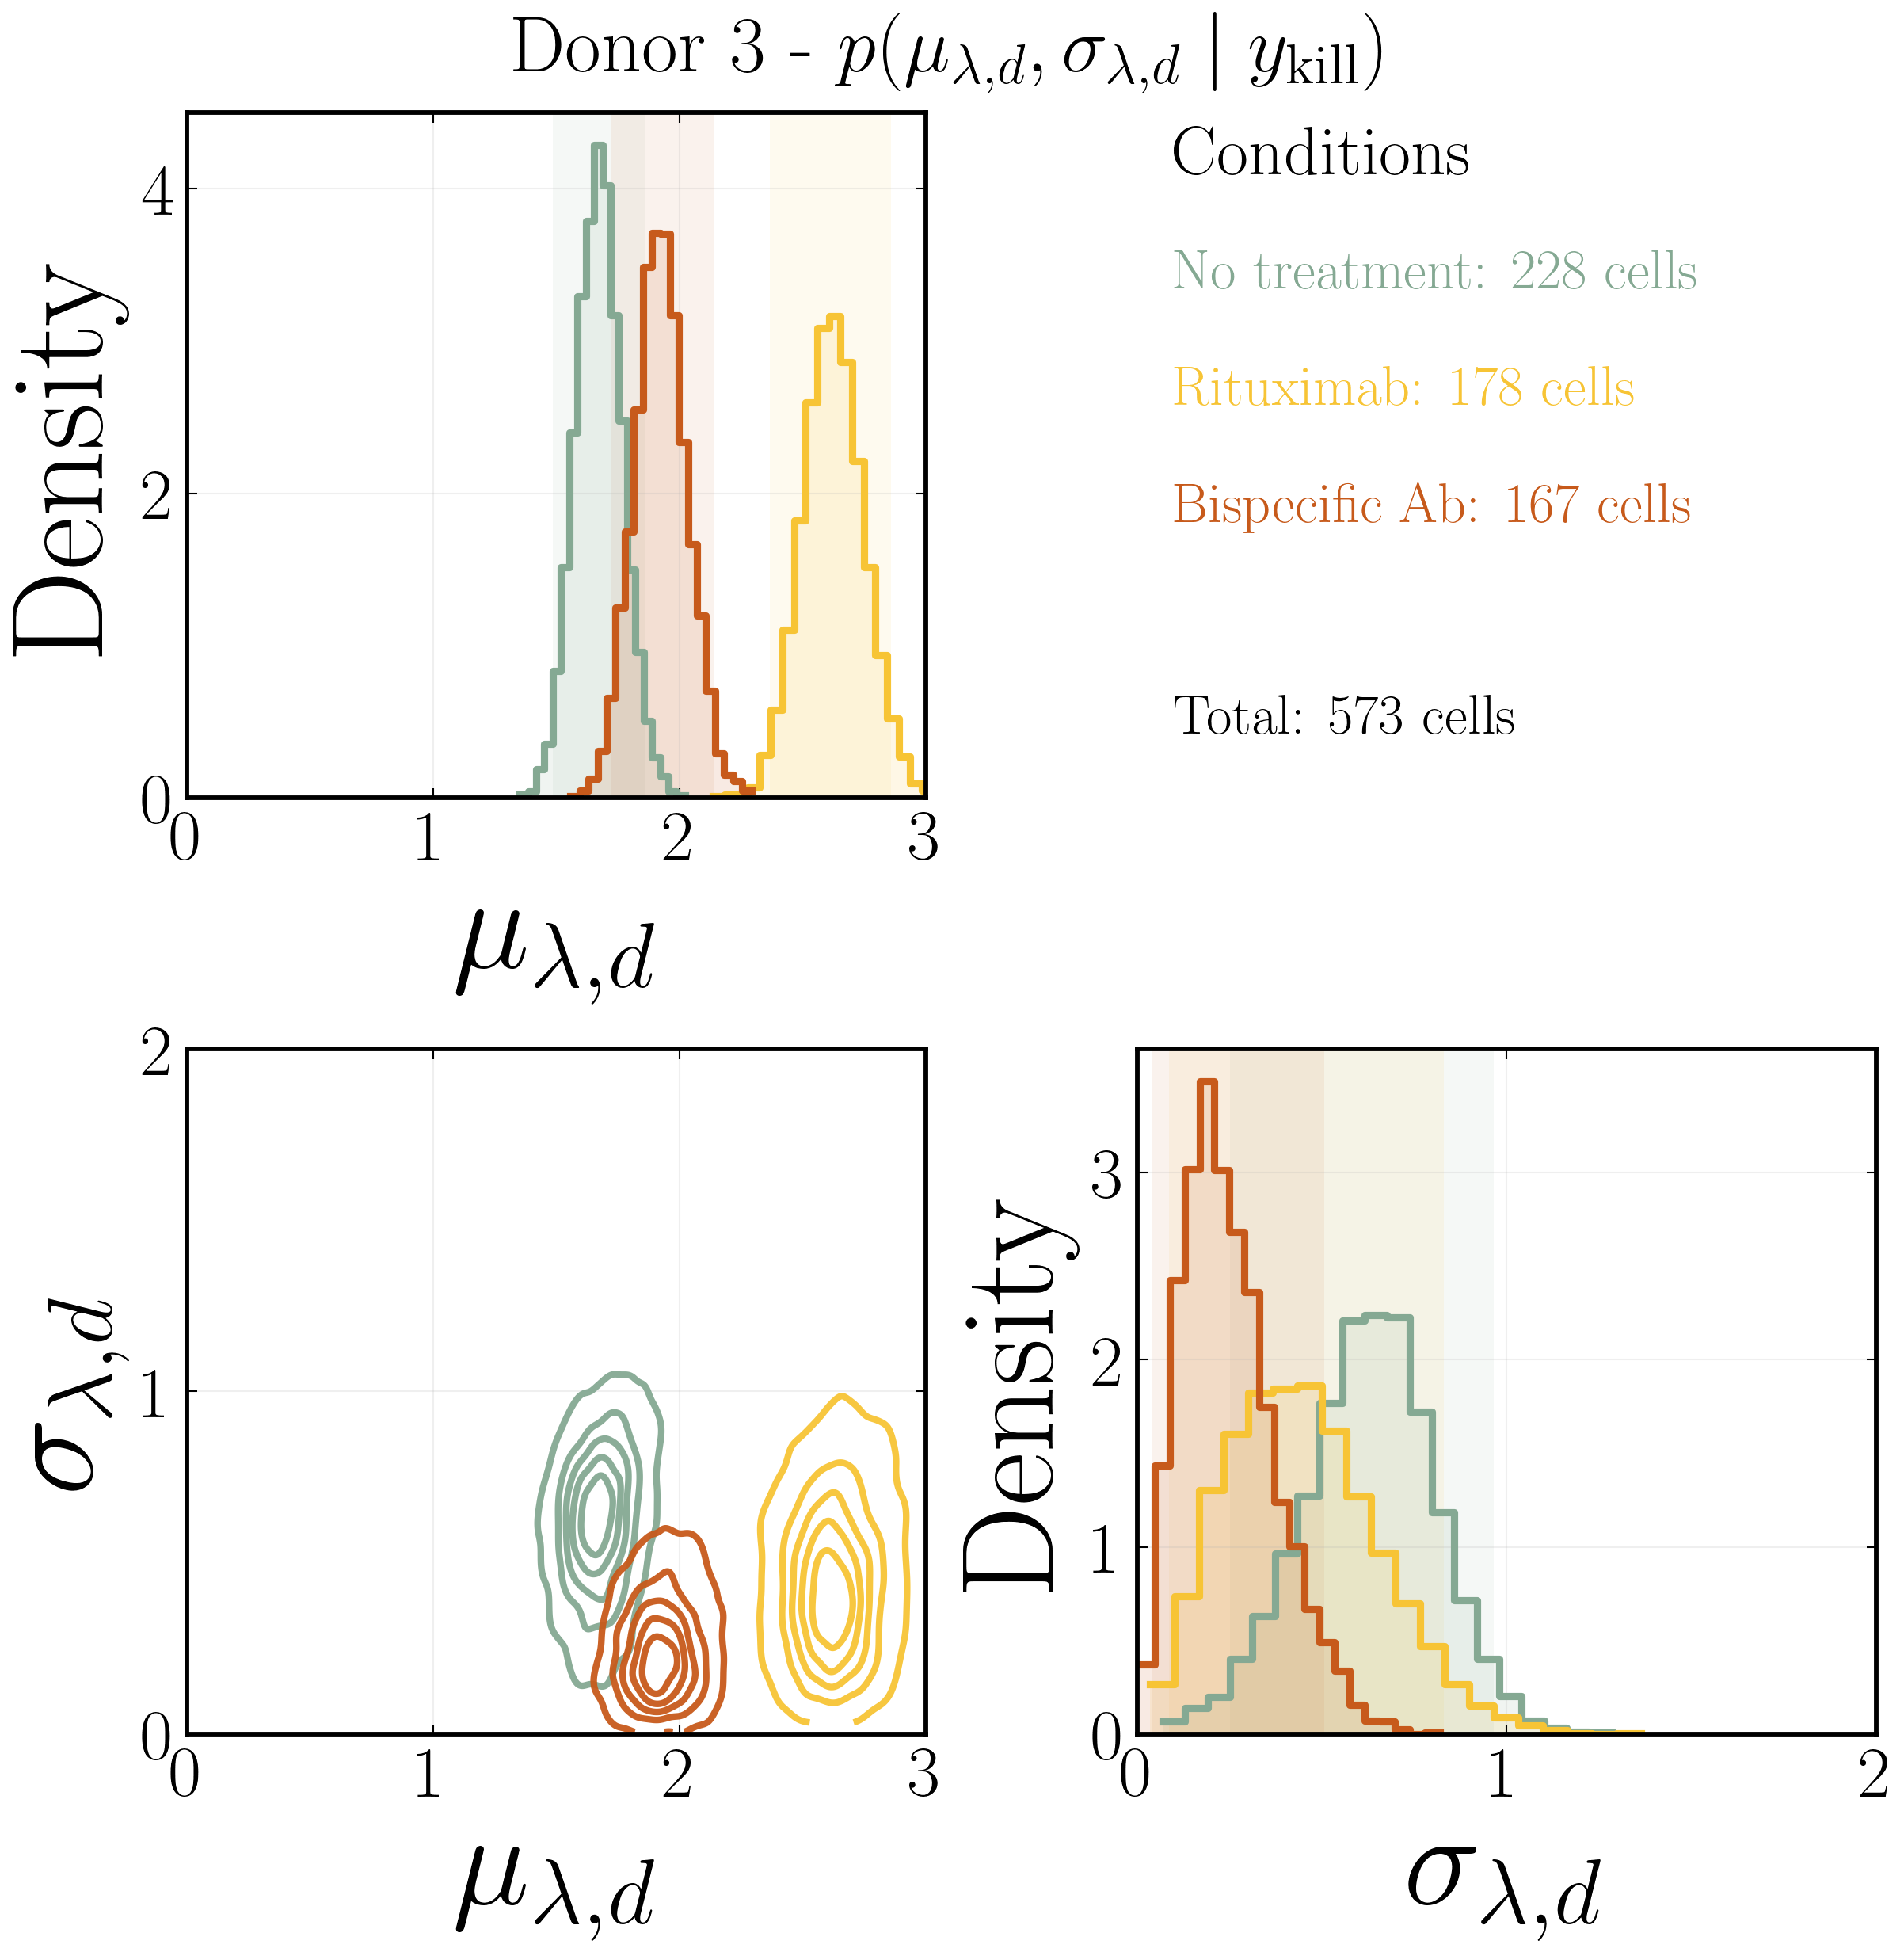

,outcome,donor,conditions,svg
0,contacts,0,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
1,contacts,1,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
2,contacts,2,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
3,contacts,3,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
4,kills,0,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
5,kills,1,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
6,kills,2,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
7,kills,3,"No treatment, Rituximab, Bispecific Ab",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...


In [57]:
def plot_one_donor_all_conditions(
    posterior_data: dict,
    outcome: str,
    donor_label: int,
    *,
    model_name: str = "Dis2P",
    conditions: list[str] | None = None,
    colors: dict[str, str] | None = None,
    sample_size: int = 6000,
    hdi_prob: float = 0.95,
    bins: int = 20,
    param_limits: dict[str, tuple[float, float]] | None = None,
    param_ticks: dict[str, list[float]] | None = None,
    cell_counts: dict | None = None,
    save_root: Path = FIGURE_ROOT,
    dpi: int = 300,
) -> Path:
    """
    Plot all condition-specific posteriors together for one donor.

    The marginal and joint posterior distributions from each
    condition are overlaid using condition-specific colors.
    """
    if conditions is None:
        conditions = CONDITION_ORDER

    if colors is None:
        colors = DONOR_CONDITION_COLORS

    if donor_label not in DONOR_MAP:
        raise ValueError(
            f"Unknown donor {donor_label}; "
            f"expected one of {DONOR_LABELS}"
        )

    # Keep only conditions with available posterior data.
    available_conditions = [
        condition
        for condition in conditions
        if (
            condition,
            outcome,
            model_name,
        ) in posterior_data
    ]

    if not available_conditions:
        raise ValueError(
            f"No posterior data found for "
            f"outcome={outcome!r}, model={model_name!r}"
        )

    donor_index = DONOR_MAP[donor_label]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8, 8.2),
        dpi=dpi,
        constrained_layout=True,
        squeeze=False,
    )

    # The upper-right panel is used for condition labels
    # and cell counts.
    axes[0, 1].axis("off")

    axes[0, 1].text(
        0.05,
        0.98,
        "Conditions",
        transform=axes[0, 1].transAxes,
        ha="left",
        va="top",
        fontsize=21,
        fontweight="bold",
        color="black",
    )

    total_cells = 0
    valid_cell_counts = True

    for condition_index, condition in enumerate(
        available_conditions
    ):
        posterior_key = (
            condition,
            outcome,
            model_name,
        )

        idata = posterior_data[posterior_key]

        mu_samples, sigma_samples = (
            get_paired_donor_samples(
                idata,
                donor_index,
                sample_size=sample_size,
                seed=(
                    17
                    + 100 * donor_index
                    + condition_index
                ),
            )
        )

        color = colors.get(
            condition,
            "#4C72B0",
        )

        # ----------------------------------------------------------
        # Condition label and cell count
        # ----------------------------------------------------------

        condition_text = condition

        if cell_counts is not None:
            number_of_cells = cell_counts.get(
                (
                    donor_label,
                    condition,
                )
            )

            if number_of_cells is not None:
                number_of_cells = int(
                    number_of_cells
                )

                total_cells += number_of_cells

                condition_text += (
                    f": {number_of_cells:,} cells"
                )
            else:
                valid_cell_counts = False
        else:
            valid_cell_counts = False

        axes[0, 1].text(
            0.05,
            0.80 - 0.17 * condition_index,
            condition_text,
            transform=axes[0, 1].transAxes,
            ha="left",
            va="top",
            fontsize=17,
            fontweight="bold",
            color=color,
        )

        # ----------------------------------------------------------
        # Marginal posterior: mu_lambda
        # ----------------------------------------------------------

        sns.histplot(
            mu_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=True,
            color=color,
            alpha=0.12,
            linewidth=0,
            ax=axes[0, 0],
        )

        sns.histplot(
            mu_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            color=color,
            linewidth=2.2,
            label=condition,
            ax=axes[0, 0],
        )

        mu_hdi = np.asarray(
            az.hdi(
                mu_samples,
                hdi_prob=hdi_prob,
            ),
            dtype=float,
        ).ravel()

        axes[0, 0].axvspan(
            mu_hdi[0],
            mu_hdi[1],
            color=color,
            alpha=0.08,
            linewidth=0,
            zorder=0,
        )

        # ----------------------------------------------------------
        # Marginal posterior: sigma_lambda
        # ----------------------------------------------------------

        sns.histplot(
            sigma_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=True,
            color=color,
            alpha=0.12,
            linewidth=0,
            ax=axes[1, 1],
        )

        sns.histplot(
            sigma_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            color=color,
            linewidth=2.2,
            ax=axes[1, 1],
        )

        sigma_hdi = np.asarray(
            az.hdi(
                sigma_samples,
                hdi_prob=hdi_prob,
            ),
            dtype=float,
        ).ravel()

        axes[1, 1].axvspan(
            sigma_hdi[0],
            sigma_hdi[1],
            color=color,
            alpha=0.08,
            linewidth=0,
            zorder=0,
        )

        # ----------------------------------------------------------
        # Joint posterior
        # ----------------------------------------------------------

        sns.kdeplot(
            x=mu_samples,
            y=sigma_samples,
            color=color,
            linewidths=2.0,
            levels=6,
            fill=False,
            alpha=0.95,
            cut=0,
            warn_singular=False,
            ax=axes[1, 0],
        )

    # Add the total cell count when all condition counts exist.
    if valid_cell_counts:
        axes[0, 1].text(
            0.05,
            0.15,
            f"Total: {total_cells:,} cells",
            transform=axes[0, 1].transAxes,
            ha="left",
            va="top",
            fontsize=17,
            fontweight="bold",
            color="black",
        )

    # --------------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------------
    axis_title_fontsize = 40
    axes[0, 0].set_xlabel(
        DONOR_PARAM_DISPLAY["mu_lambda"],
        fontsize=axis_title_fontsize,
    )
    axes[0, 0].set_ylabel(
        "Density",
        fontsize=axis_title_fontsize,
    )

    axes[1, 0].set_xlabel(
        DONOR_PARAM_DISPLAY["mu_lambda"],
        fontsize=axis_title_fontsize,
    )
    axes[1, 0].set_ylabel(
        DONOR_PARAM_DISPLAY["sigma_lambda"],
        fontsize=axis_title_fontsize,
    )

    axes[1, 1].set_xlabel(
        DONOR_PARAM_DISPLAY["sigma_lambda"],
        fontsize=axis_title_fontsize,
    )
    axes[1, 1].set_ylabel(
        "Density",
        fontsize=axis_title_fontsize,
    )

    # --------------------------------------------------------------
    # Shared parameter limits
    # --------------------------------------------------------------

    if param_limits is not None:
        if "mu_lambda" in param_limits:
            axes[0, 0].set_xlim(
                *param_limits["mu_lambda"]
            )
            axes[1, 0].set_xlim(
                *param_limits["mu_lambda"]
            )

        if "sigma_lambda" in param_limits:
            axes[1, 1].set_xlim(
                *param_limits["sigma_lambda"]
            )
            axes[1, 0].set_ylim(
                *param_limits["sigma_lambda"]
            )

    # --------------------------------------------------------------
    # Shared parameter ticks
    # --------------------------------------------------------------

    if param_ticks is not None:
        if "mu_lambda" in param_ticks:
            mu_ticks = param_ticks[
                "mu_lambda"
            ]

            axes[0, 0].set_xticks(
                mu_ticks
            )
            axes[1, 0].set_xticks(
                mu_ticks
            )

        if "sigma_lambda" in param_ticks:
            sigma_ticks = param_ticks[
                "sigma_lambda"
            ]

            axes[1, 1].set_xticks(
                sigma_ticks
            )
            axes[1, 0].set_yticks(
                sigma_ticks
            )

    # --------------------------------------------------------------
    # Styling
    # --------------------------------------------------------------

    for row, column in [
        (0, 0),
        (1, 0),
        (1, 1),
    ]:
        ax = axes[row, column]

        ax.set_facecolor("white")

        ax.tick_params(
            axis="both",
            labelsize=22,
        )

        ax.minorticks_off()
        ax.grid(alpha=0.20)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_color("black")

    fig.suptitle(
        (
            f"Donor {donor_label} - "
            rf"$p(\mu_{{\lambda,d}},"
            rf"\sigma_{{\lambda,d}}"
            rf"\mid {OUTCOME_SYMBOL[outcome]})$"
        ),
        fontsize=24,
    )

    # --------------------------------------------------------------
    # Save into a clearly labelled subfolder
    # --------------------------------------------------------------

    donor_save_dir = (
        Path(save_root)
        / "donor_posteriors_all_conditions"
        / outcome
        / f"donor_{donor_label}"
    )

    donor_save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = donor_save_dir / (
        f"joint_posterior_"
        f"donor_{donor_label}_"
        f"{outcome}_"
        f"{model_name}_"
        f"all_conditions.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.25,
        transparent=True,
    )

    plt.show()

    return out_path


# ==================================================================
# Generate one all-condition posterior plot per donor and outcome
# ==================================================================

DONOR_ALL_CONDITIONS_POSTERIOR_RECORDS = []

for outcome in [
    "contacts",
    "kills",
]:
    for donor_label in DONOR_LABELS:
        figure_path = (
            plot_one_donor_all_conditions(
                posterior_data,
                outcome=outcome,
                donor_label=donor_label,
                model_name="Dis2P",
                conditions=CONDITION_ORDER,
                colors=DONOR_CONDITION_COLORS,
                param_limits=(
                    DONOR_PARAMETER_LIMITS[
                        outcome
                    ]
                ),
                param_ticks=(
                    DONOR_PARAMETER_TICKS[
                        outcome
                    ]
                ),
                cell_counts=cell_numbers,
                save_root=FIGURE_ROOT,
            )
        )

        DONOR_ALL_CONDITIONS_POSTERIOR_RECORDS.append(
            {
                "outcome": outcome,
                "donor": donor_label,
                "conditions": ", ".join(
                    CONDITION_ORDER
                ),
                "svg": figure_path,
            }
        )


DONOR_ALL_CONDITIONS_POSTERIOR_PATHS = (
    pd.DataFrame(
        DONOR_ALL_CONDITIONS_POSTERIOR_RECORDS
    )
)

display(
    DONOR_ALL_CONDITIONS_POSTERIOR_PATHS
)

In [58]:
def plot_conditions_with_donors_joint_posterior(
    posterior_data: dict,
    outcome: str,
    *,
    model_name: str = "Dis2P",
    conditions: list[str] | None = None,
    donor_labels: list[int] | None = None,
    donor_colors: dict[int, str] | None = None,
    sample_size: int = 6000,
    hdi_prob: float = 0.95,
    bins: int = 20,
    param_limits: dict[str, tuple[float, float]] | None = None,
    save_dir: Path = FIGURE_ROOT,
    dpi: int = 300,
) -> Path:
    if conditions is None:
        conditions = CONDITION_ORDER
    if donor_labels is None:
        donor_labels = DONOR_LABELS
    if donor_colors is None:
        donor_colors = DONOR_COLORS

    conditions = [
        condition
        for condition in conditions
        if (condition, outcome, model_name) in posterior_data
    ]

    if not conditions:
        raise ValueError(
            f"No posterior data for outcome={outcome!r}, "
            f"model={model_name!r}"
        )

    fig = plt.figure(
        figsize=(7.0 * len(conditions), 6.6),
        dpi=dpi,
        constrained_layout=True,
    )

    # One outer column per experimental condition.
    subfigures = fig.subfigures(
        nrows=1,
        ncols=len(conditions),
        wspace=0.04,
    )
    subfigures = np.atleast_1d(subfigures).ravel()

    legend_axis = None

    for condition_index, (subfig, condition) in enumerate(
        zip(subfigures, conditions)
    ):
        axes = subfig.subplots(
            2,
            2,
            squeeze=False,
        )

        axes[0, 1].axis("off")

        idata = posterior_data[
            (condition, outcome, model_name)
        ]

        for donor_position, donor_label in enumerate(donor_labels):
            donor_index = DONOR_MAP[donor_label]
            color = donor_colors[donor_label]

            mu_samples, sigma_samples = get_paired_donor_samples(
                idata,
                donor_index,
                sample_size=sample_size,
                seed=(
                    17
                    + 100 * donor_index
                    + condition_index
                ),
            )

            # Marginal posterior of mu_lambda.
            sns.histplot(
                mu_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.10,
                linewidth=0,
                ax=axes[0, 0],
            )
            sns.histplot(
                mu_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.2,
                label=(
                    f"Donor {donor_label}"
                    if condition_index == 0
                    else None
                ),
                ax=axes[0, 0],
            )

            mu_hdi = np.asarray(
                az.hdi(
                    mu_samples,
                    hdi_prob=hdi_prob,
                ),
                dtype=float,
            )
            axes[0, 0].axvspan(
                mu_hdi[0],
                mu_hdi[1],
                color=color,
                alpha=0.06,
                linewidth=0,
            )

            # Marginal posterior of sigma_lambda.
            sns.histplot(
                sigma_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.10,
                linewidth=0,
                ax=axes[1, 1],
            )
            sns.histplot(
                sigma_samples,
                bins=bins,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.2,
                ax=axes[1, 1],
            )

            sigma_hdi = np.asarray(
                az.hdi(
                    sigma_samples,
                    hdi_prob=hdi_prob,
                ),
                dtype=float,
            )
            axes[1, 1].axvspan(
                sigma_hdi[0],
                sigma_hdi[1],
                color=color,
                alpha=0.06,
                linewidth=0,
            )

            # Joint posterior of mu_lambda and sigma_lambda.
            sns.kdeplot(
                x=mu_samples,
                y=sigma_samples,
                color=color,
                linewidths=1.8,
                levels=6,
                fill=False,
                alpha=0.90,
                warn_singular=False,
                ax=axes[1, 0],
            )

        axes[0, 0].set_xlabel(
            DONOR_PARAM_DISPLAY["mu_lambda"],
            fontsize=34,
        )
        axes[0, 0].set_ylabel(
            "Density",
            fontsize=34,
        )

        axes[1, 0].set_xlabel(
            DONOR_PARAM_DISPLAY["mu_lambda"],
            fontsize=34,
        )
        axes[1, 0].set_ylabel(
            DONOR_PARAM_DISPLAY["sigma_lambda"],
            fontsize=34,
        )

        axes[1, 1].set_xlabel(
            DONOR_PARAM_DISPLAY["sigma_lambda"],
            fontsize=34,
        )
        axes[1, 1].set_ylabel(
            "Density",
            fontsize=34,
        )

        if param_limits is not None:
            if "mu_lambda" in param_limits:
                axes[0, 0].set_xlim(
                    *param_limits["mu_lambda"]
                )
                axes[1, 0].set_xlim(
                    *param_limits["mu_lambda"]
                )

            if "sigma_lambda" in param_limits:
                axes[1, 1].set_xlim(
                    *param_limits["sigma_lambda"]
                )
                axes[1, 0].set_ylim(
                    *param_limits["sigma_lambda"]
                )

        for row, column in [
            (0, 0),
            (1, 0),
            (1, 1),
        ]:
            ax = axes[row, column]
            ax.set_facecolor("white")
            ax.tick_params(
                axis="both",
                labelsize=24,
            )
            ax.minorticks_off()
            ax.grid(alpha=0.20)

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.4)
                spine.set_color("black")

        subfig.suptitle(
            condition,
            fontsize=21,
        )

        if condition_index == 0:
            legend_axis = axes[0, 0]

    # One shared donor legend.
    handles, labels = legend_axis.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(donor_labels),
        frameon=True,
        edgecolor="black",
        fontsize=15,
    )

    fig.suptitle(
        # rf"Donor-specific posterior distributions: "
        rf"$p(\mu_{{\lambda,d}},\sigma_{{\lambda,d}}"
        rf"\mid {OUTCOME_SYMBOL[outcome]})$",
        fontsize=26,
        y=1.10,
    )

    save_dir = Path(save_dir)
    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = save_dir / (
        f"joint_posterior_three_conditions_"
        f"donors_{outcome}_{model_name}.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.3,
        transparent=True,
    )

    plt.show()
    return out_path

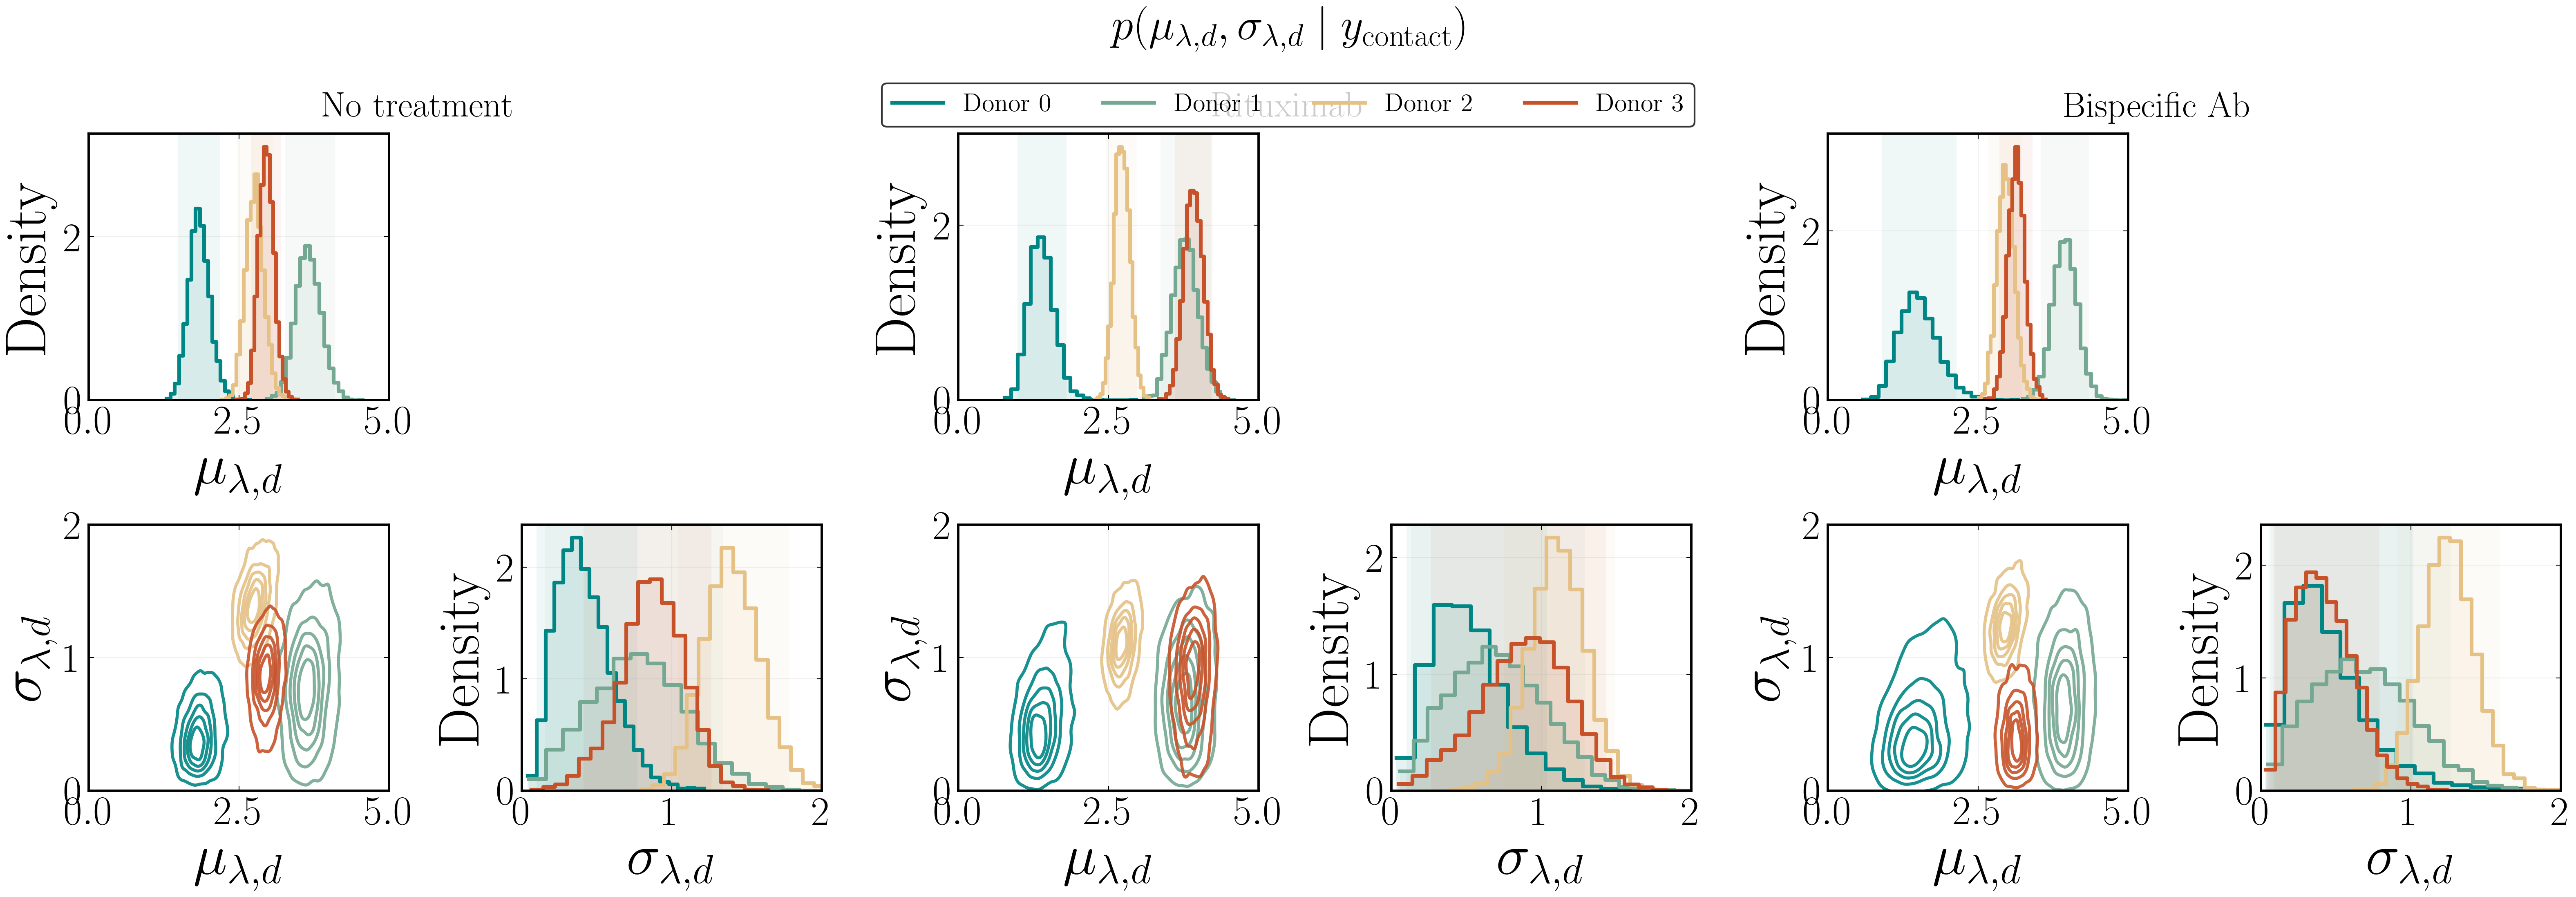

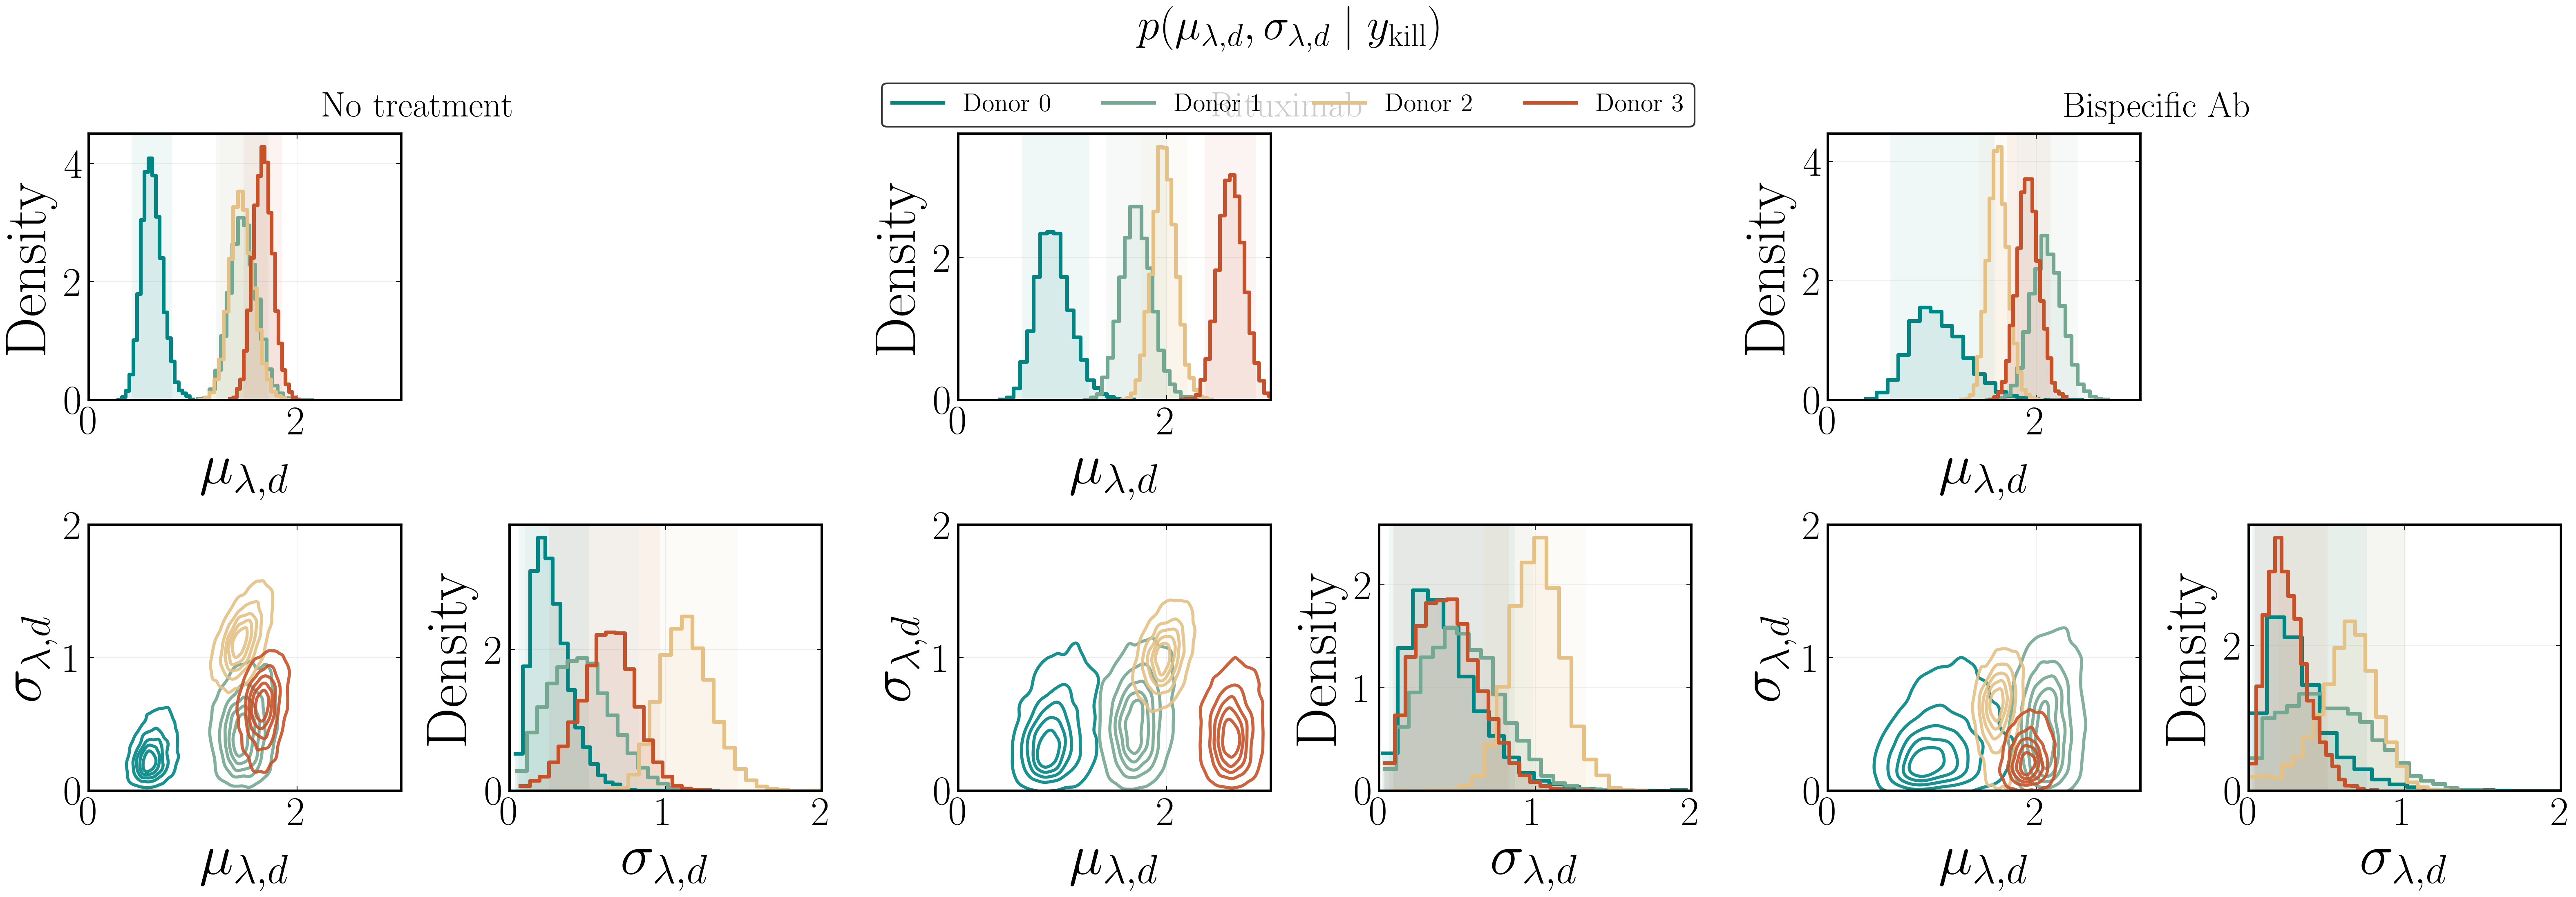

(PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/joint_posterior_three_conditions_donors_contacts_Dis2P.svg'),
 PosixPath('/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/figures/analysis_1_donor_logscale/joint_posterior_three_conditions_donors_kills_Dis2P.svg'))

In [59]:
DONOR_COLOR_VALUES = [
    "#008585",
    "#74a892",
    "#e5c185",
    "#c7522a"
]

if len(DONOR_LABELS) != len(DONOR_COLOR_VALUES):
    raise ValueError(
        f"Found {len(DONOR_LABELS)} donors but "
        f"{len(DONOR_COLOR_VALUES)} donor colors."
    )

DONOR_COLORS = dict(
    zip(DONOR_LABELS, DONOR_COLOR_VALUES)
)

DONOR_COLORS

CONTACTS_CONDITION_JOINT_PATH = (
    plot_conditions_with_donors_joint_posterior(
        posterior_data,
        outcome="contacts",
        model_name="Dis2P",
        donor_colors=DONOR_COLORS,
        param_limits=DONOR_PARAMETER_LIMITS["contacts"],
    )
)

KILLS_CONDITION_JOINT_PATH = (
    plot_conditions_with_donors_joint_posterior(
        posterior_data,
        outcome="kills",
        model_name="Dis2P",
        donor_colors=DONOR_COLORS,
        param_limits=DONOR_PARAMETER_LIMITS["kills"],
    )
)

CONTACTS_CONDITION_JOINT_PATH, KILLS_CONDITION_JOINT_PATH

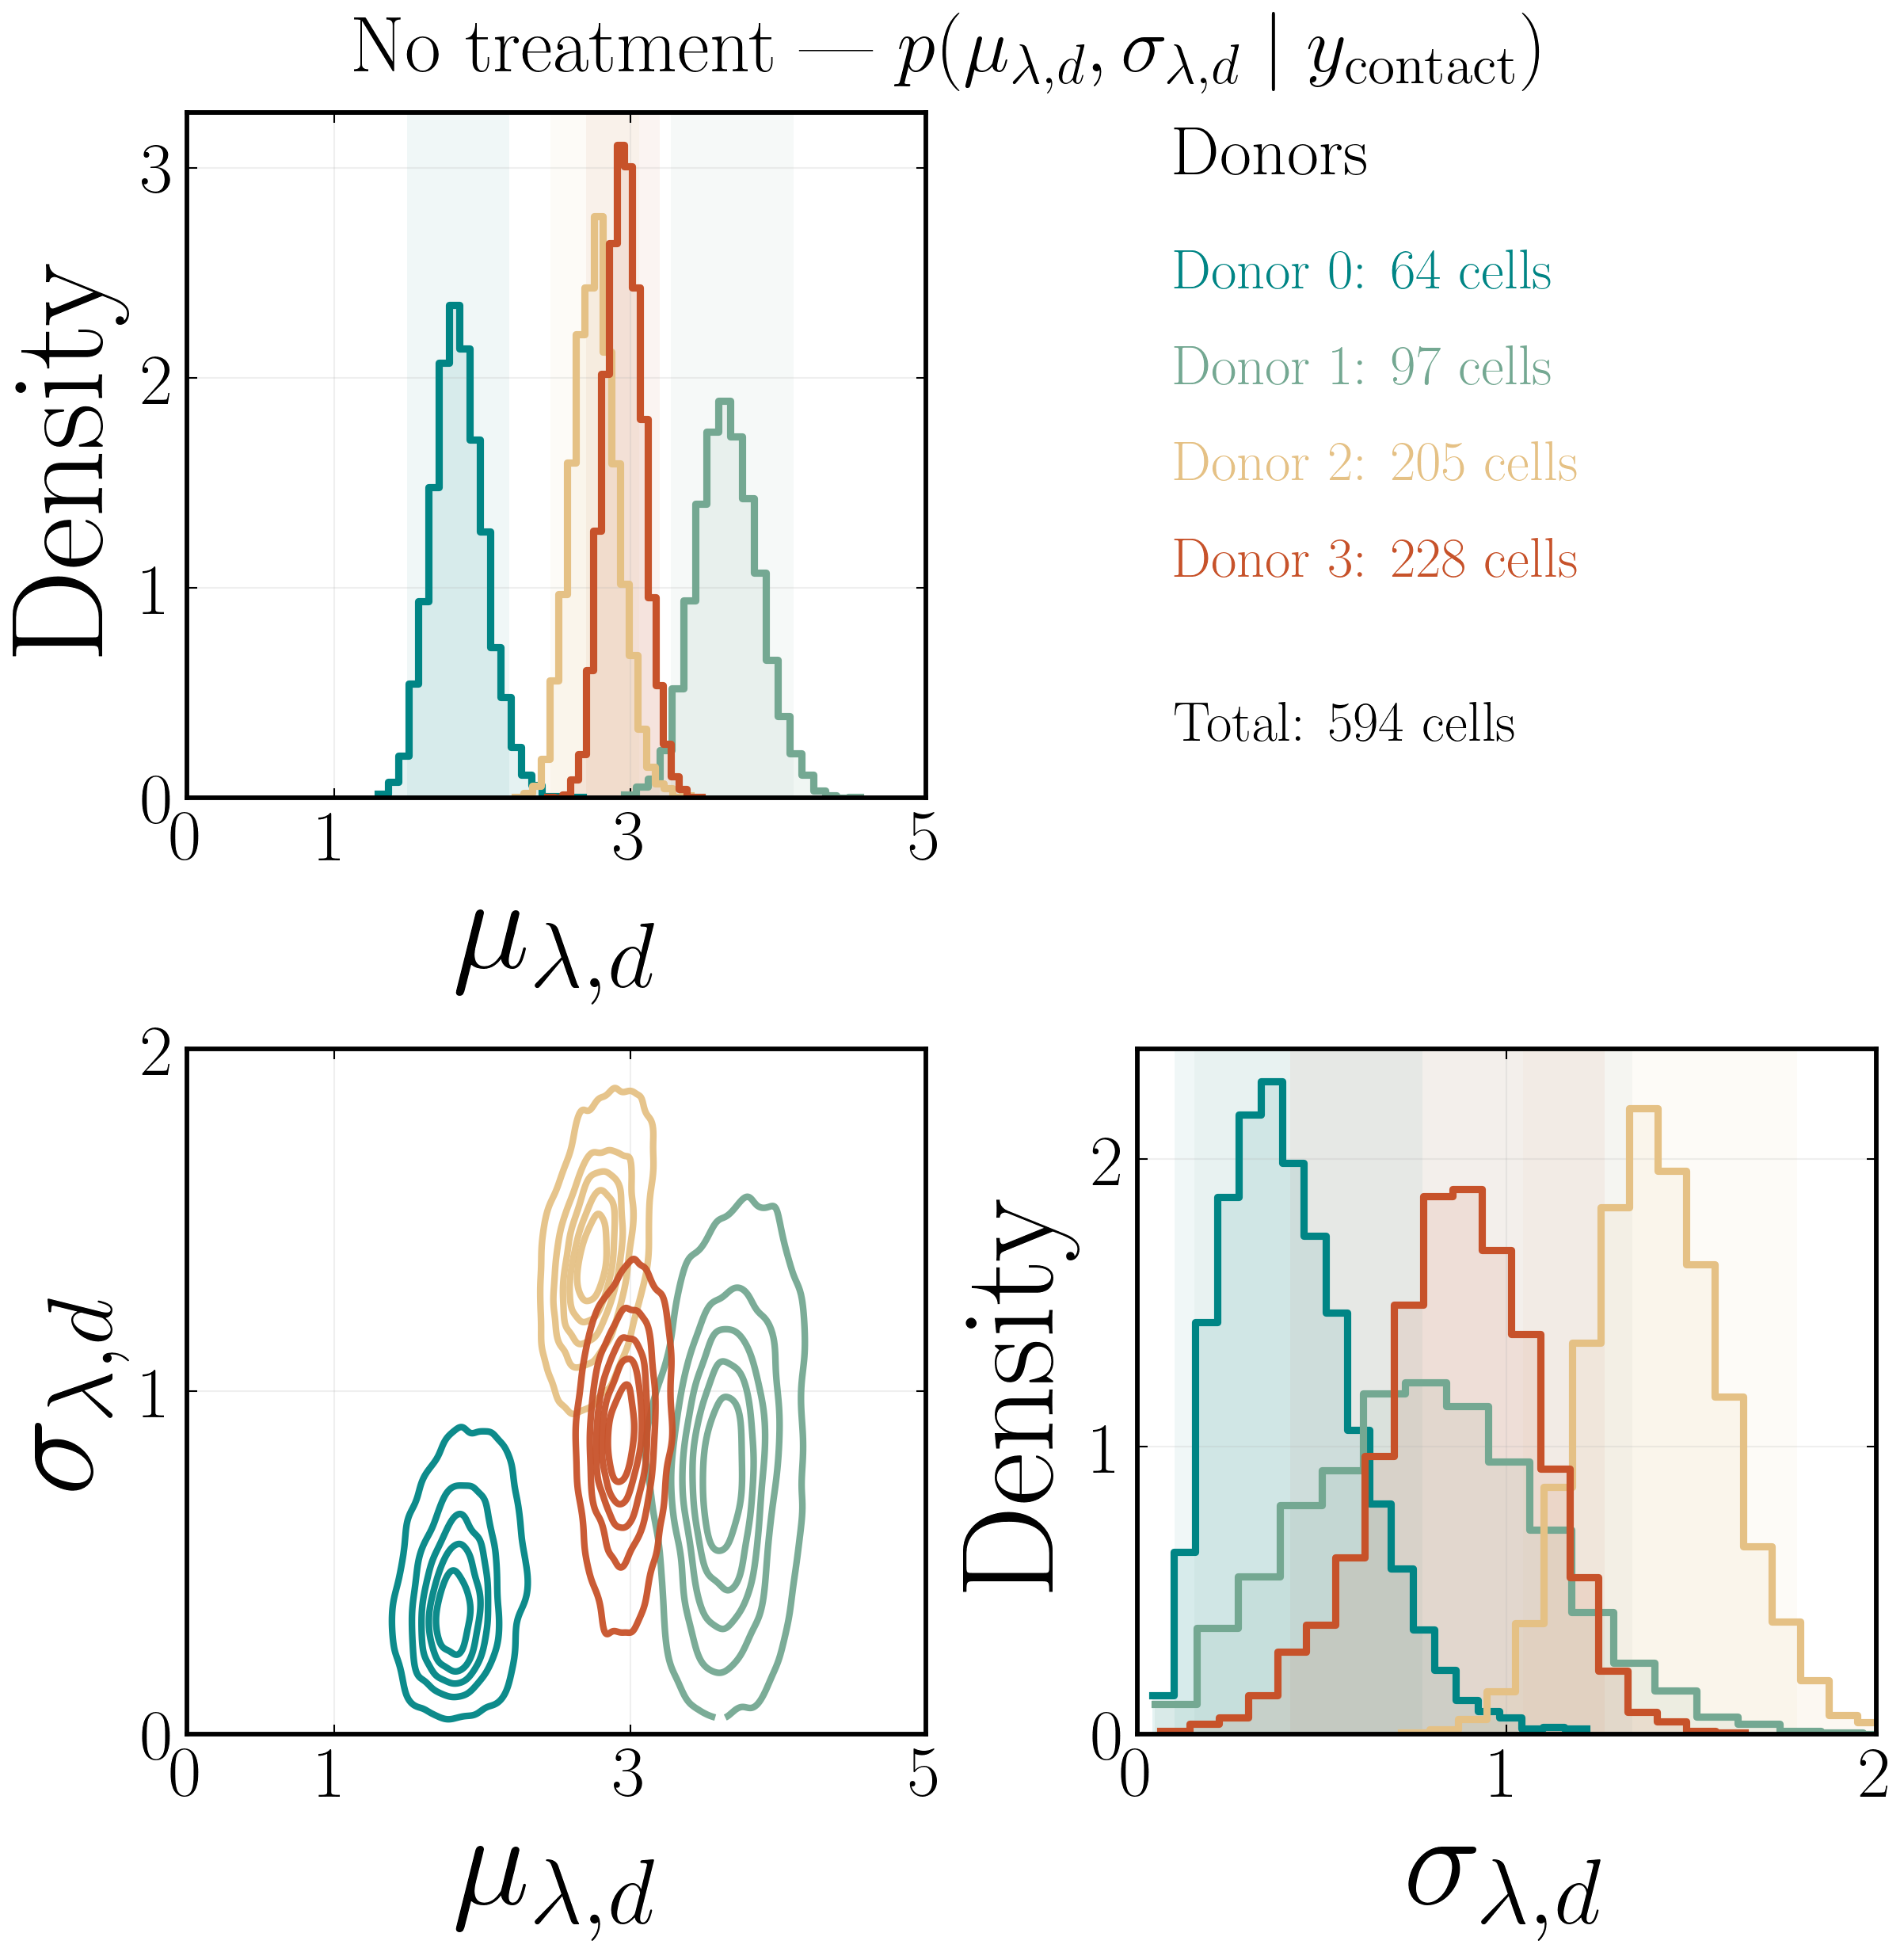

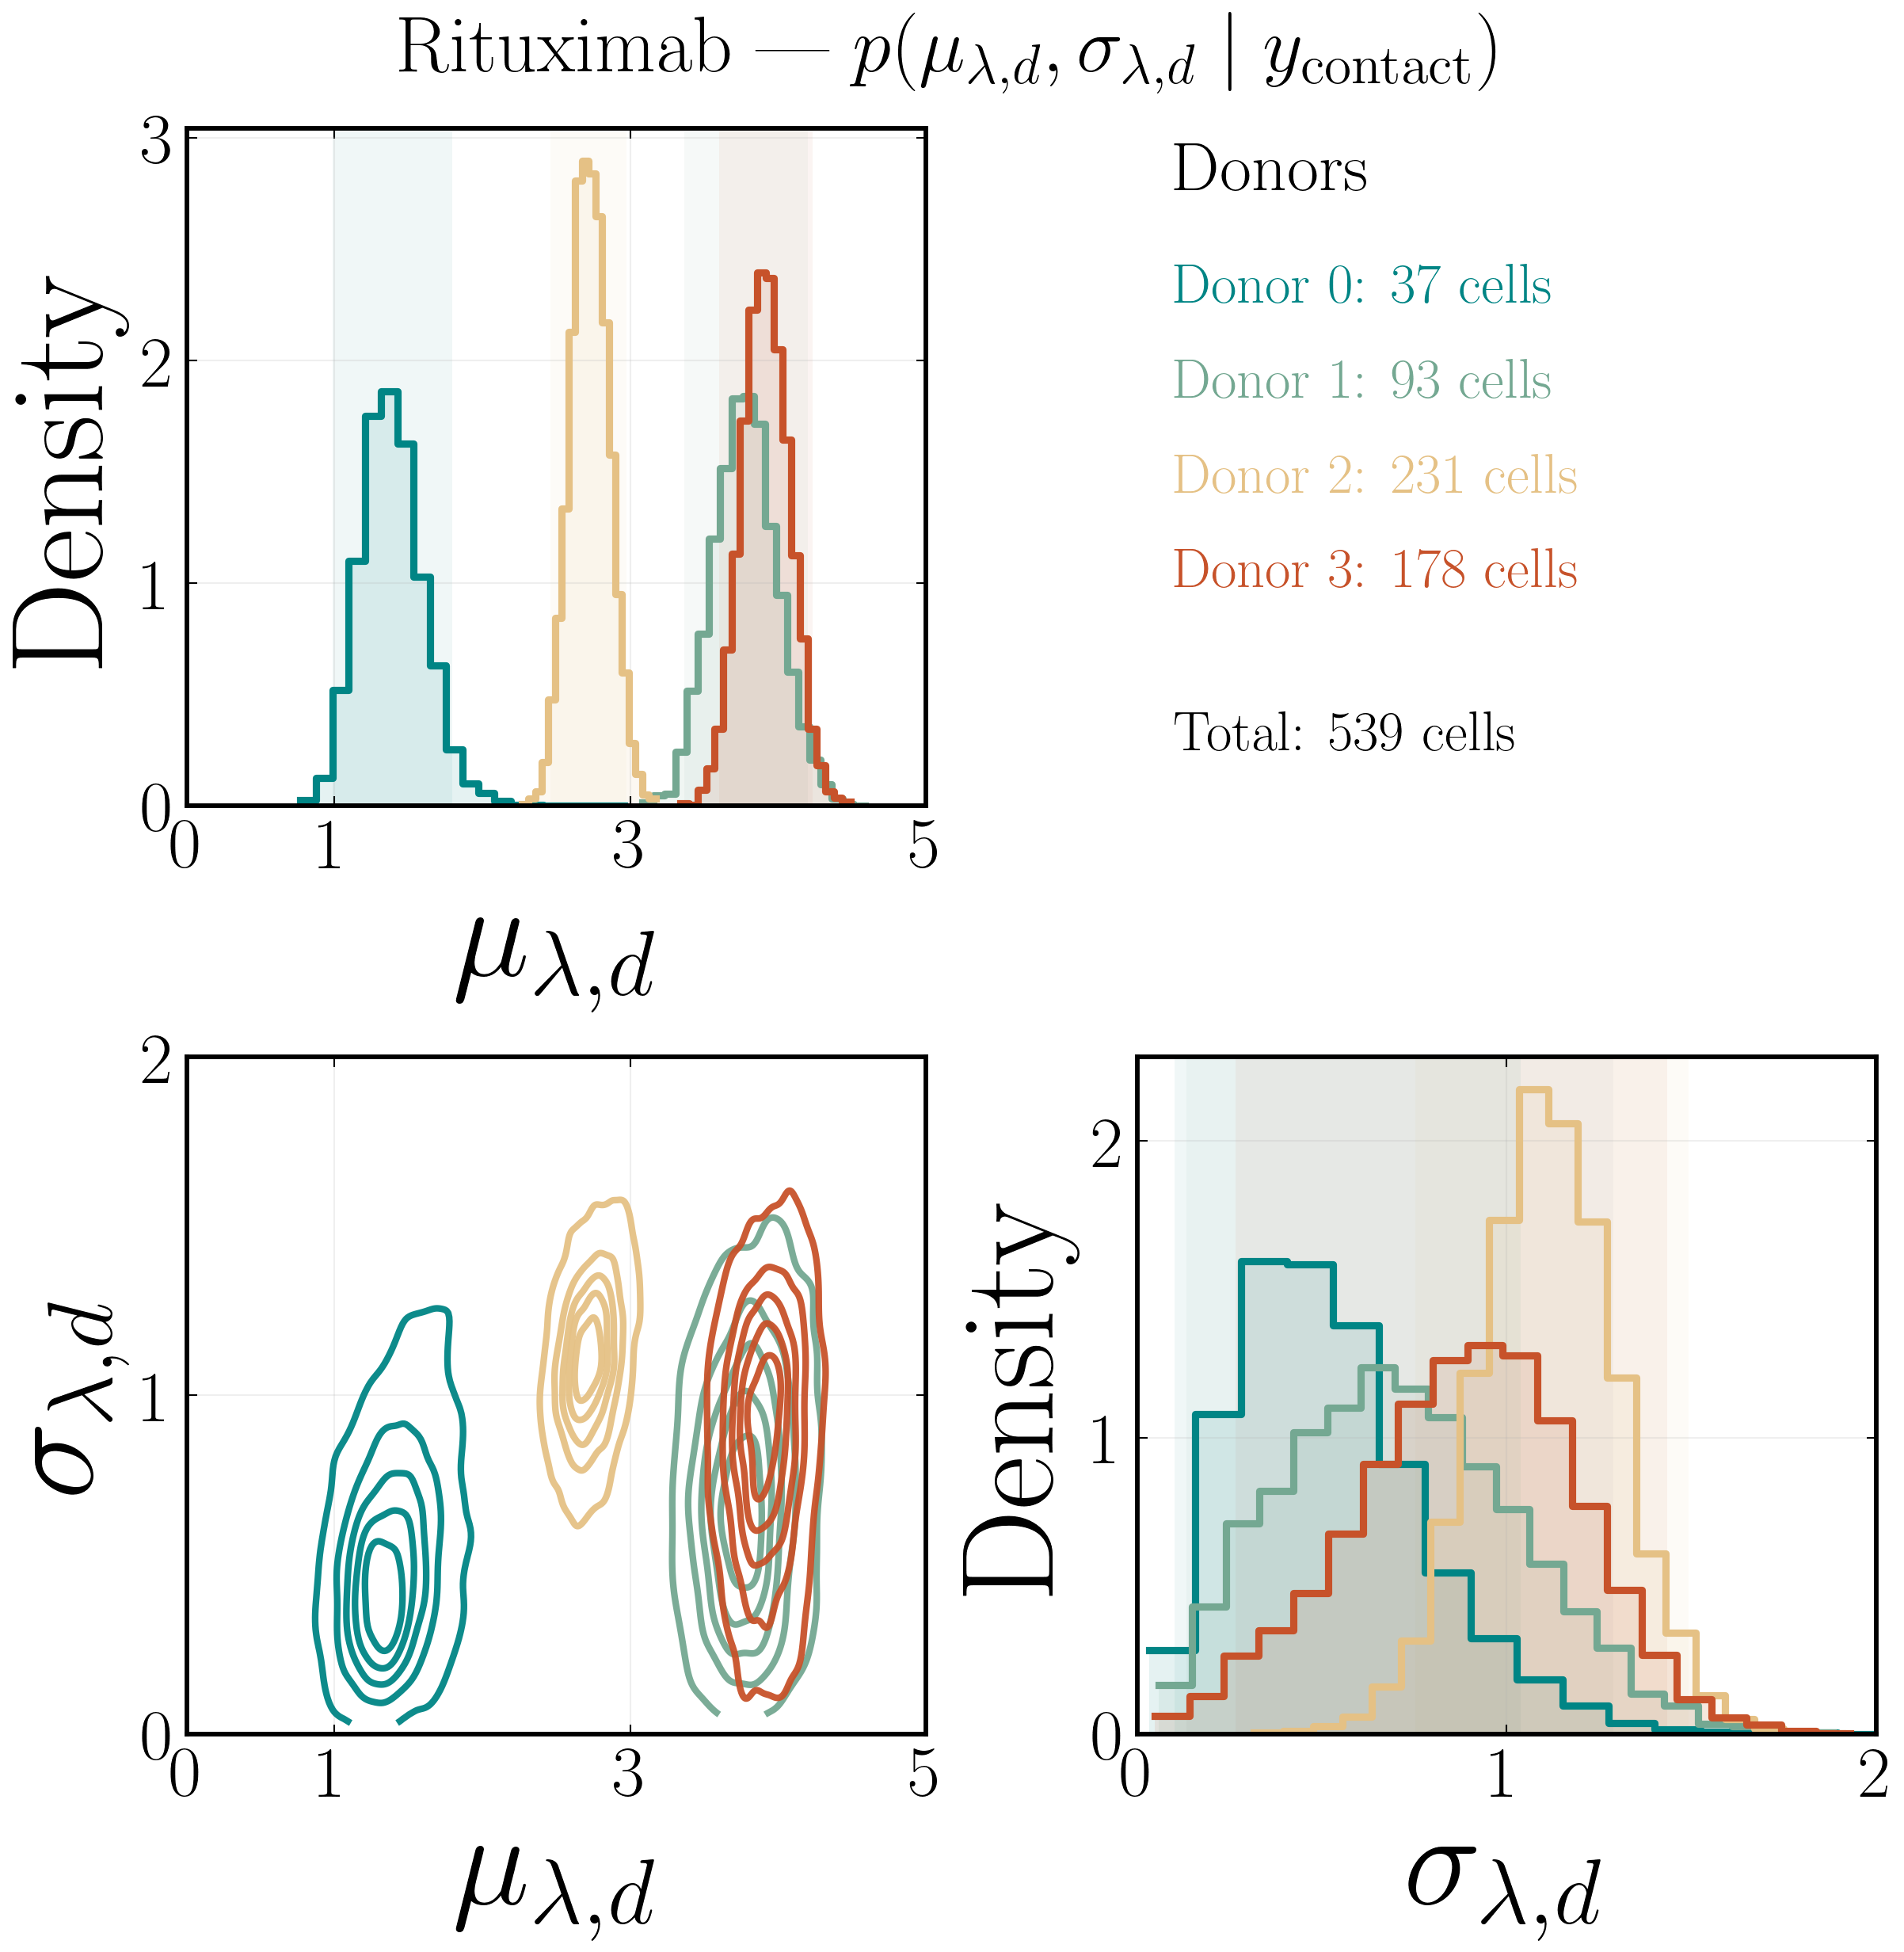

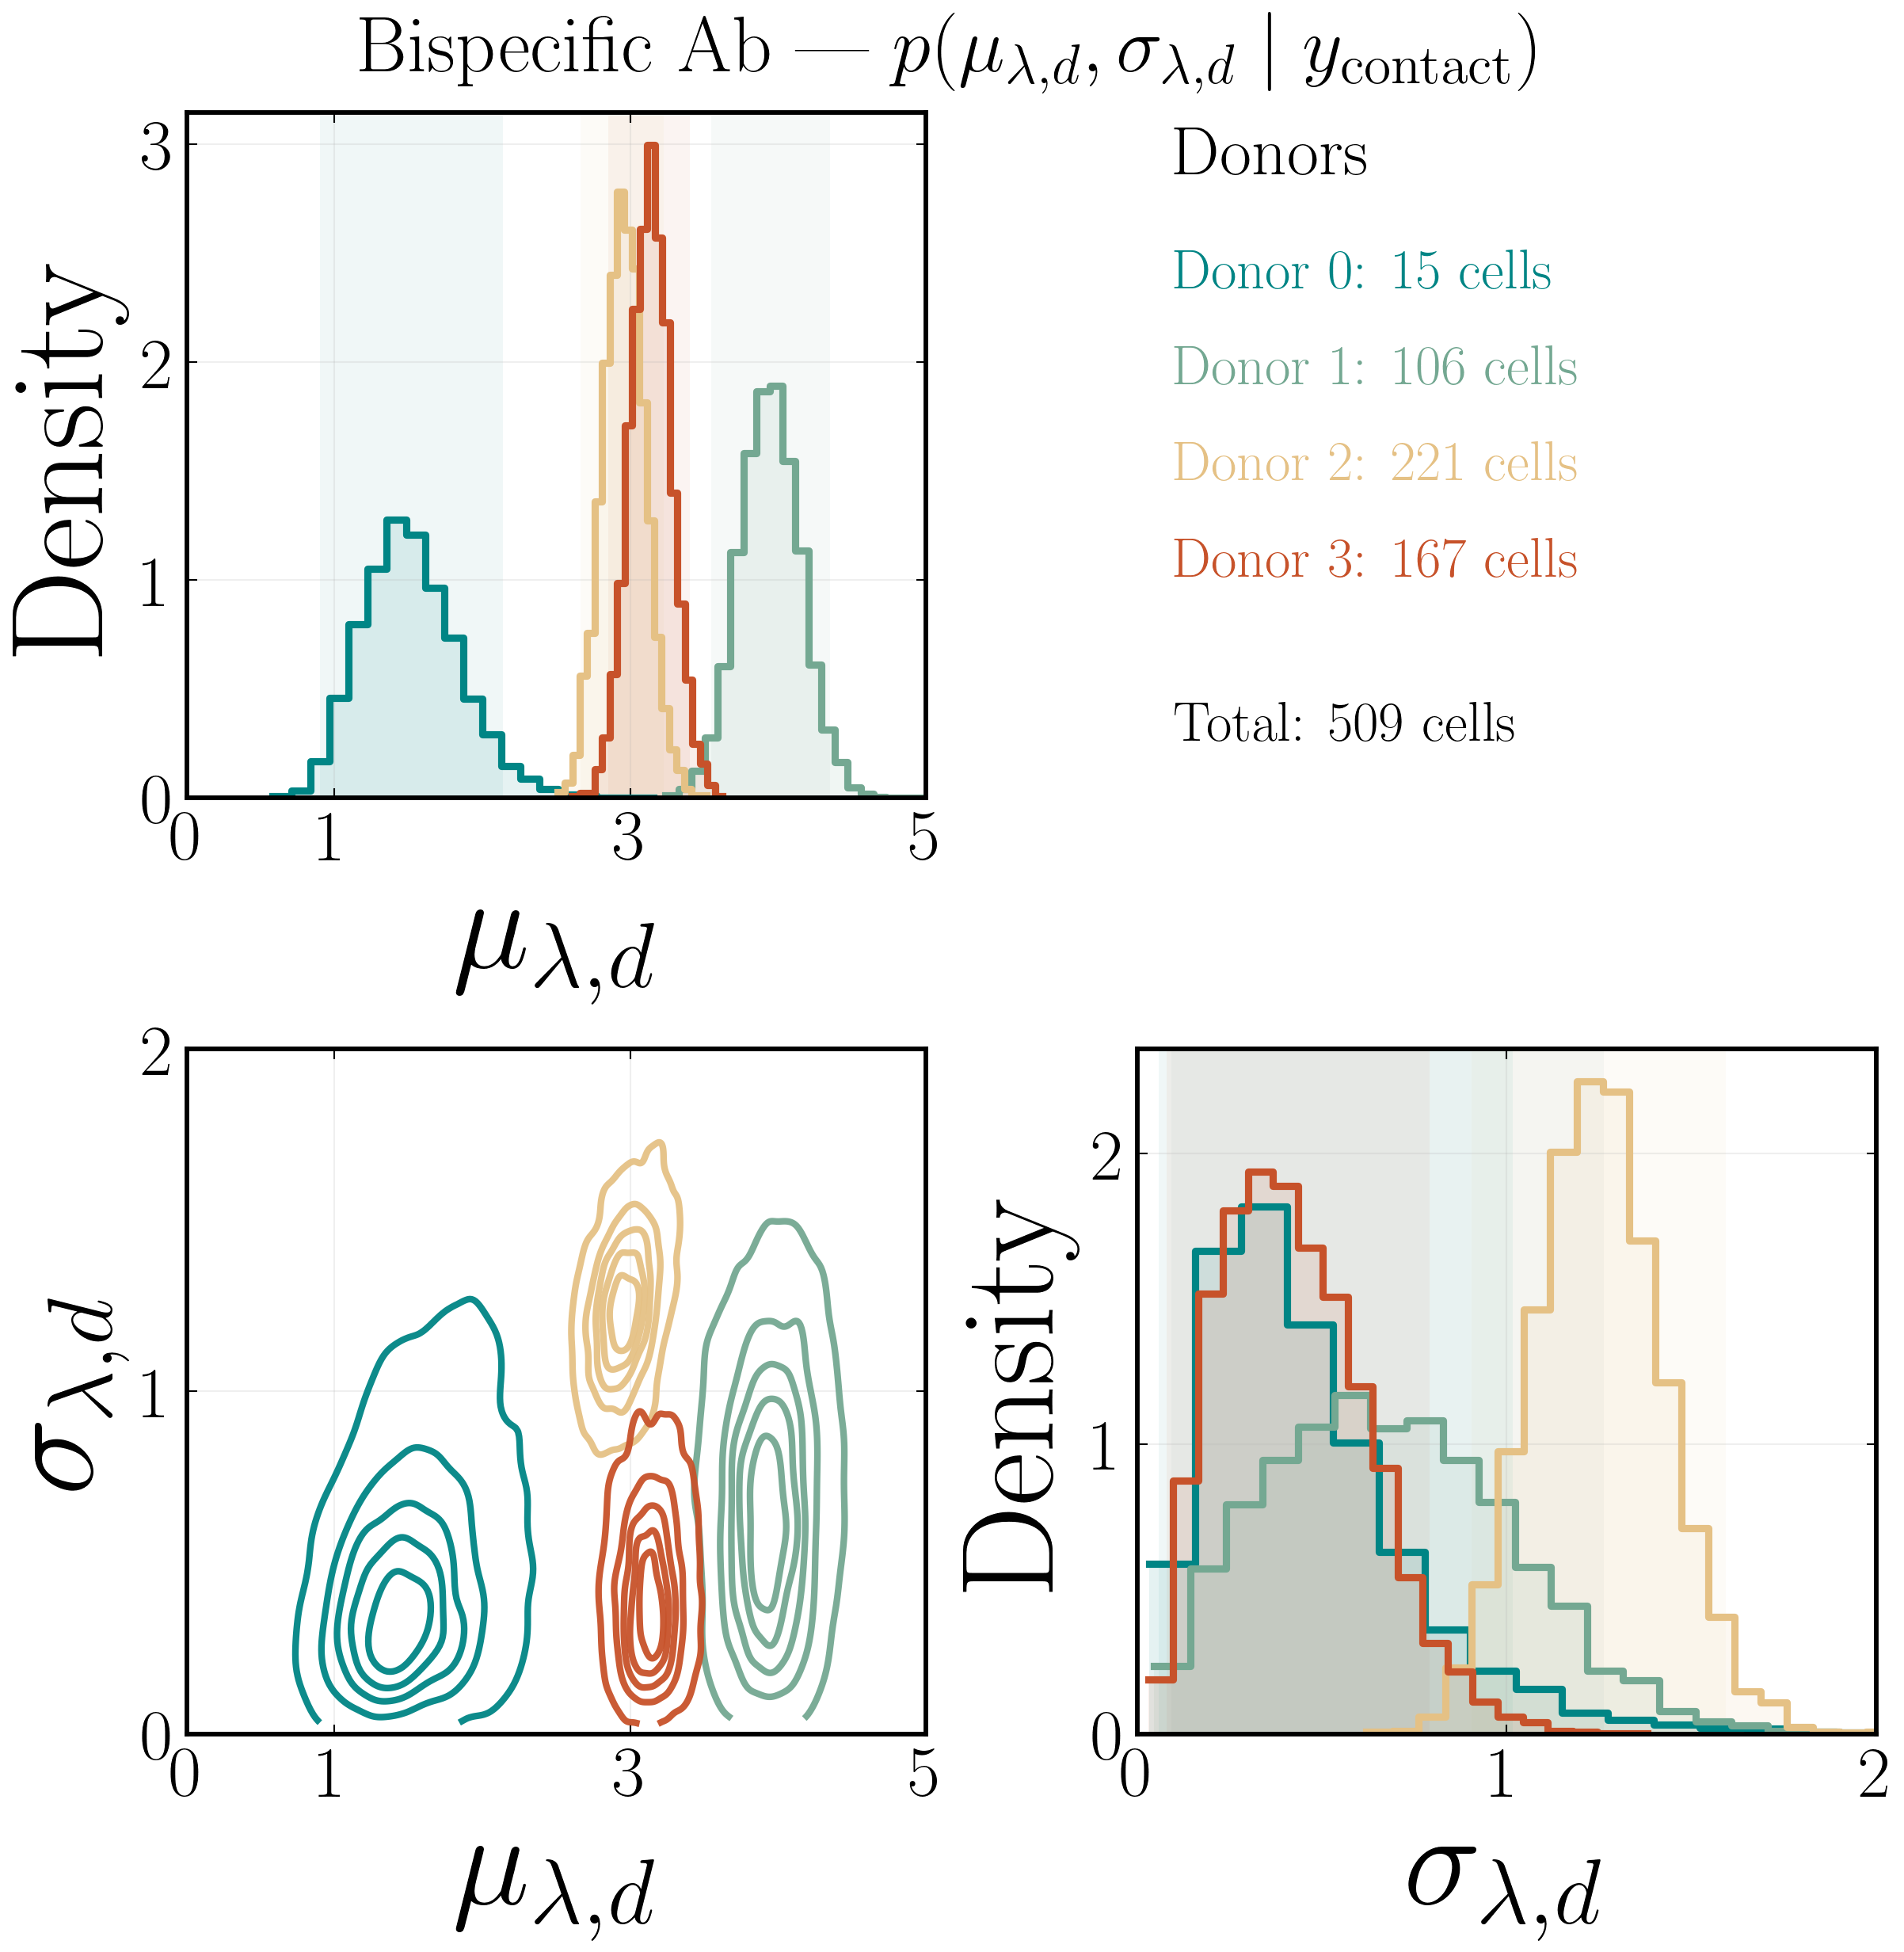

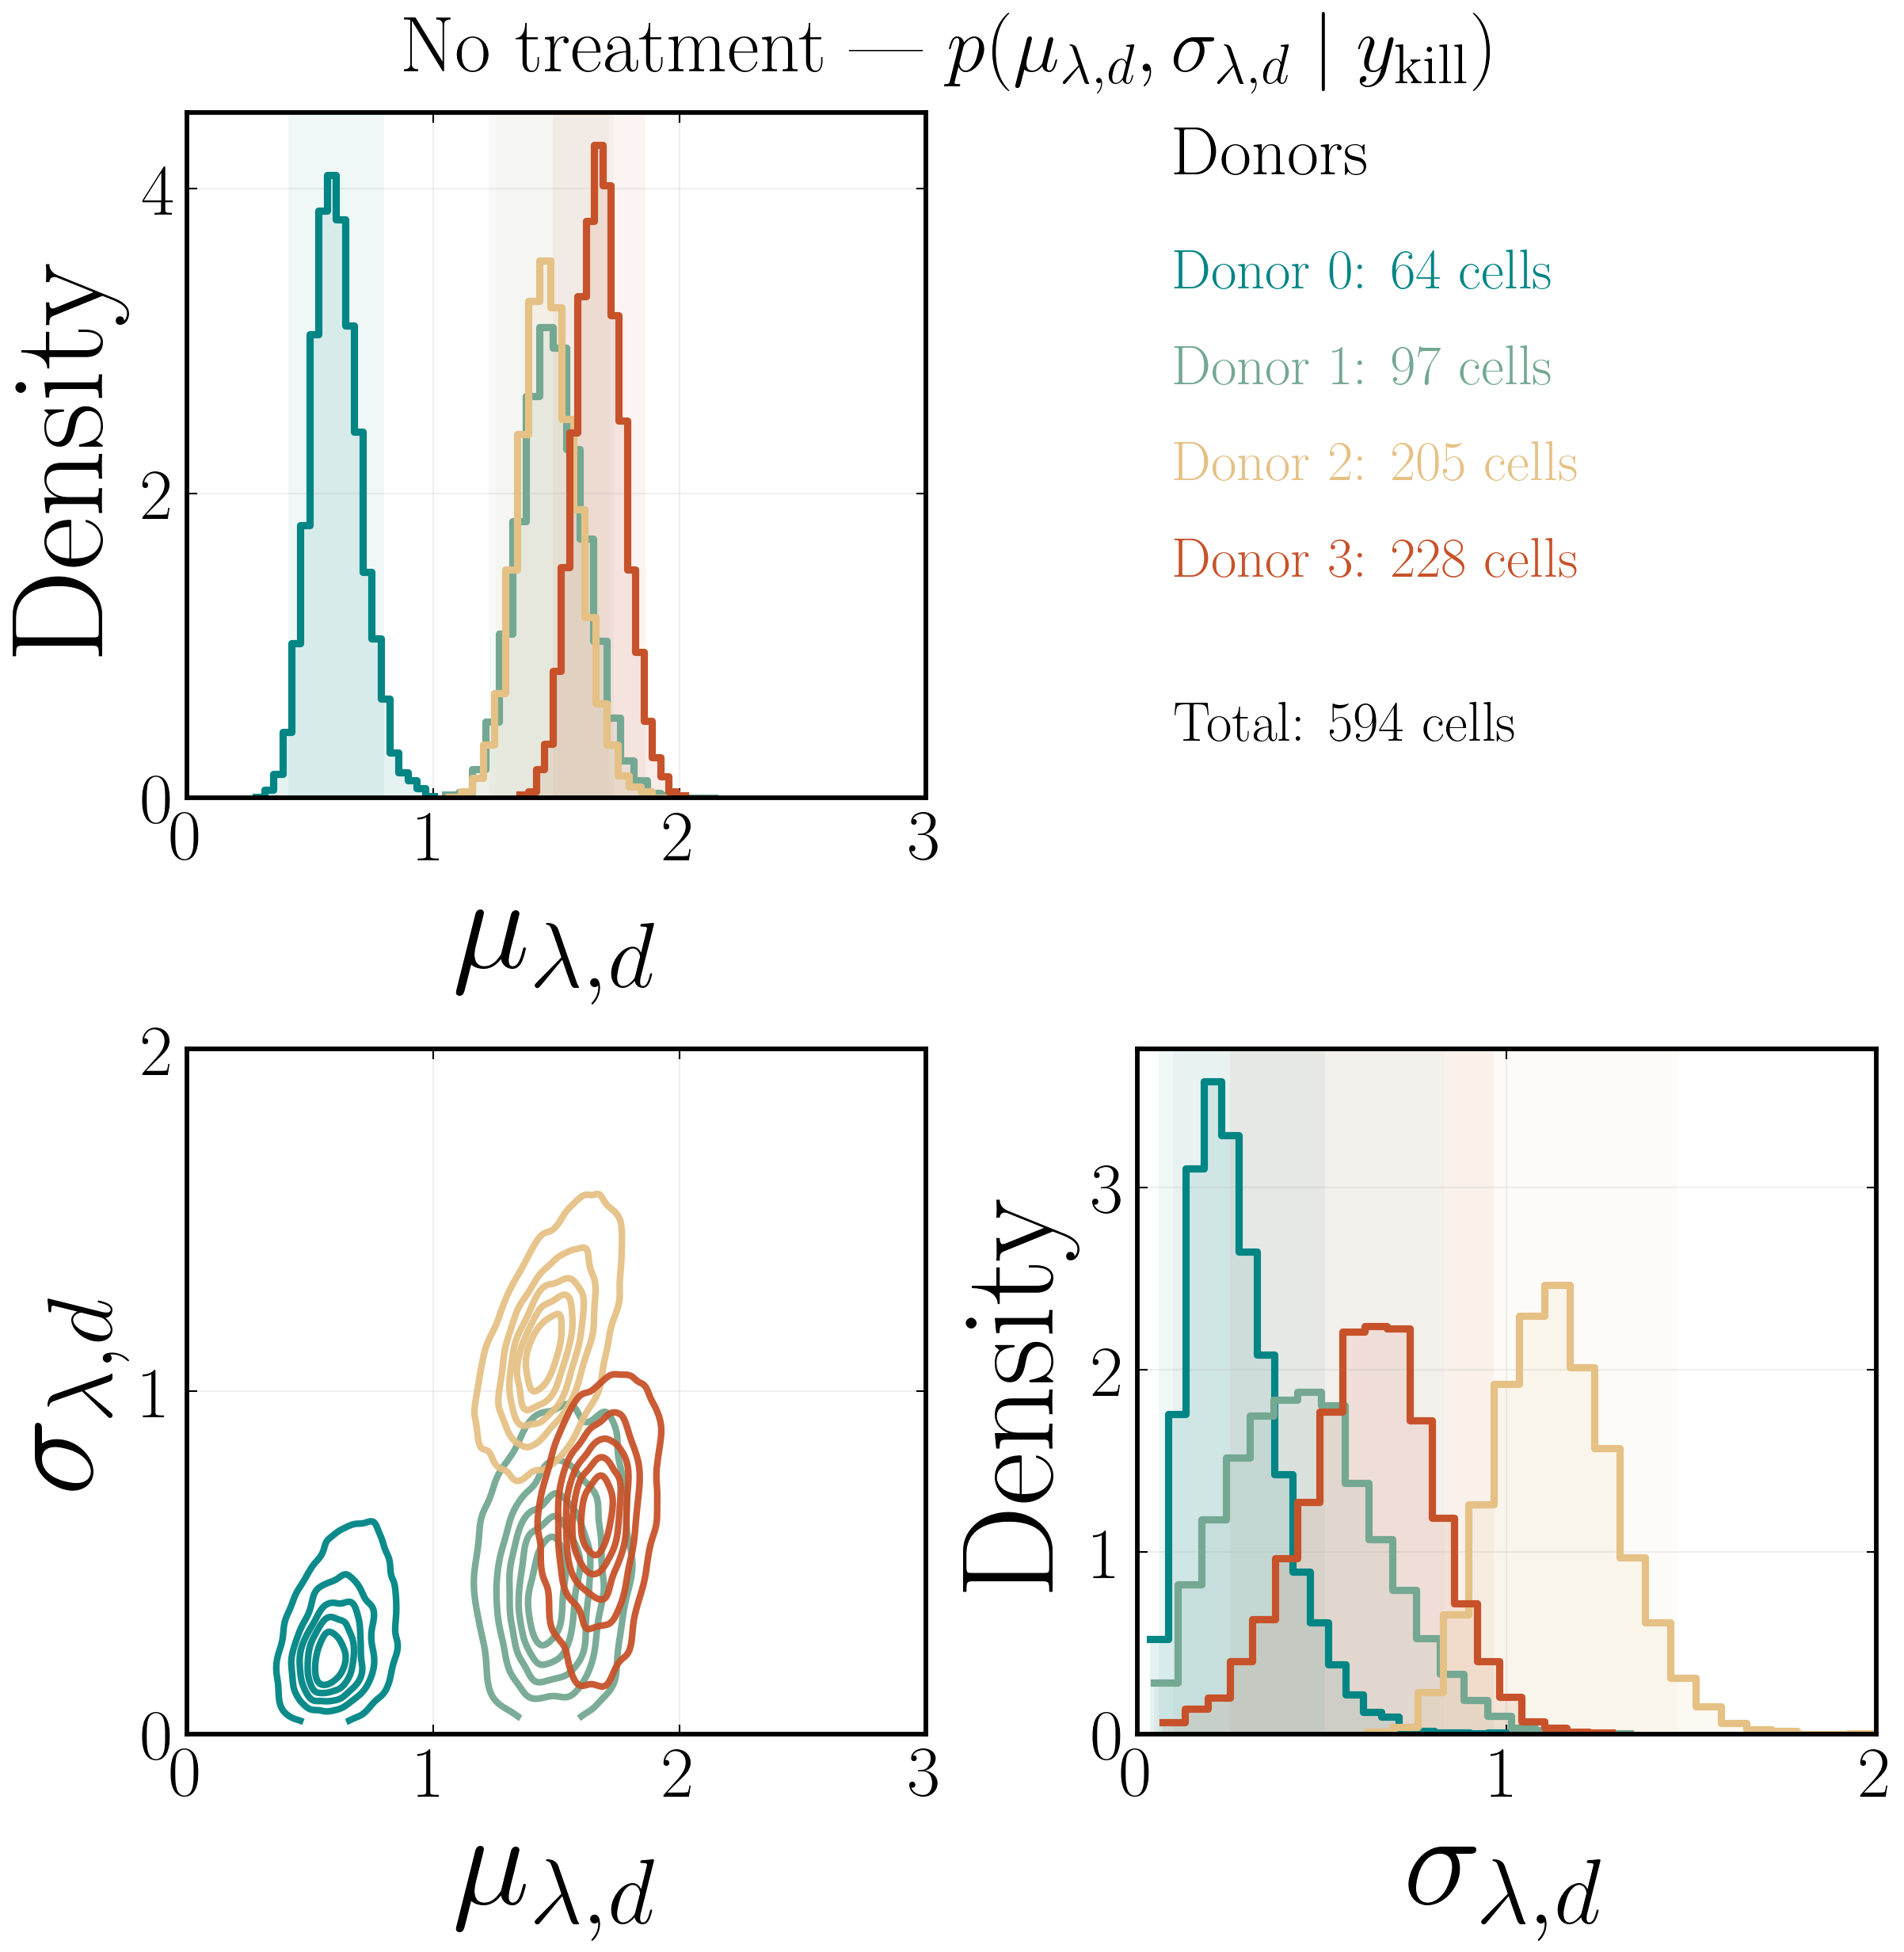

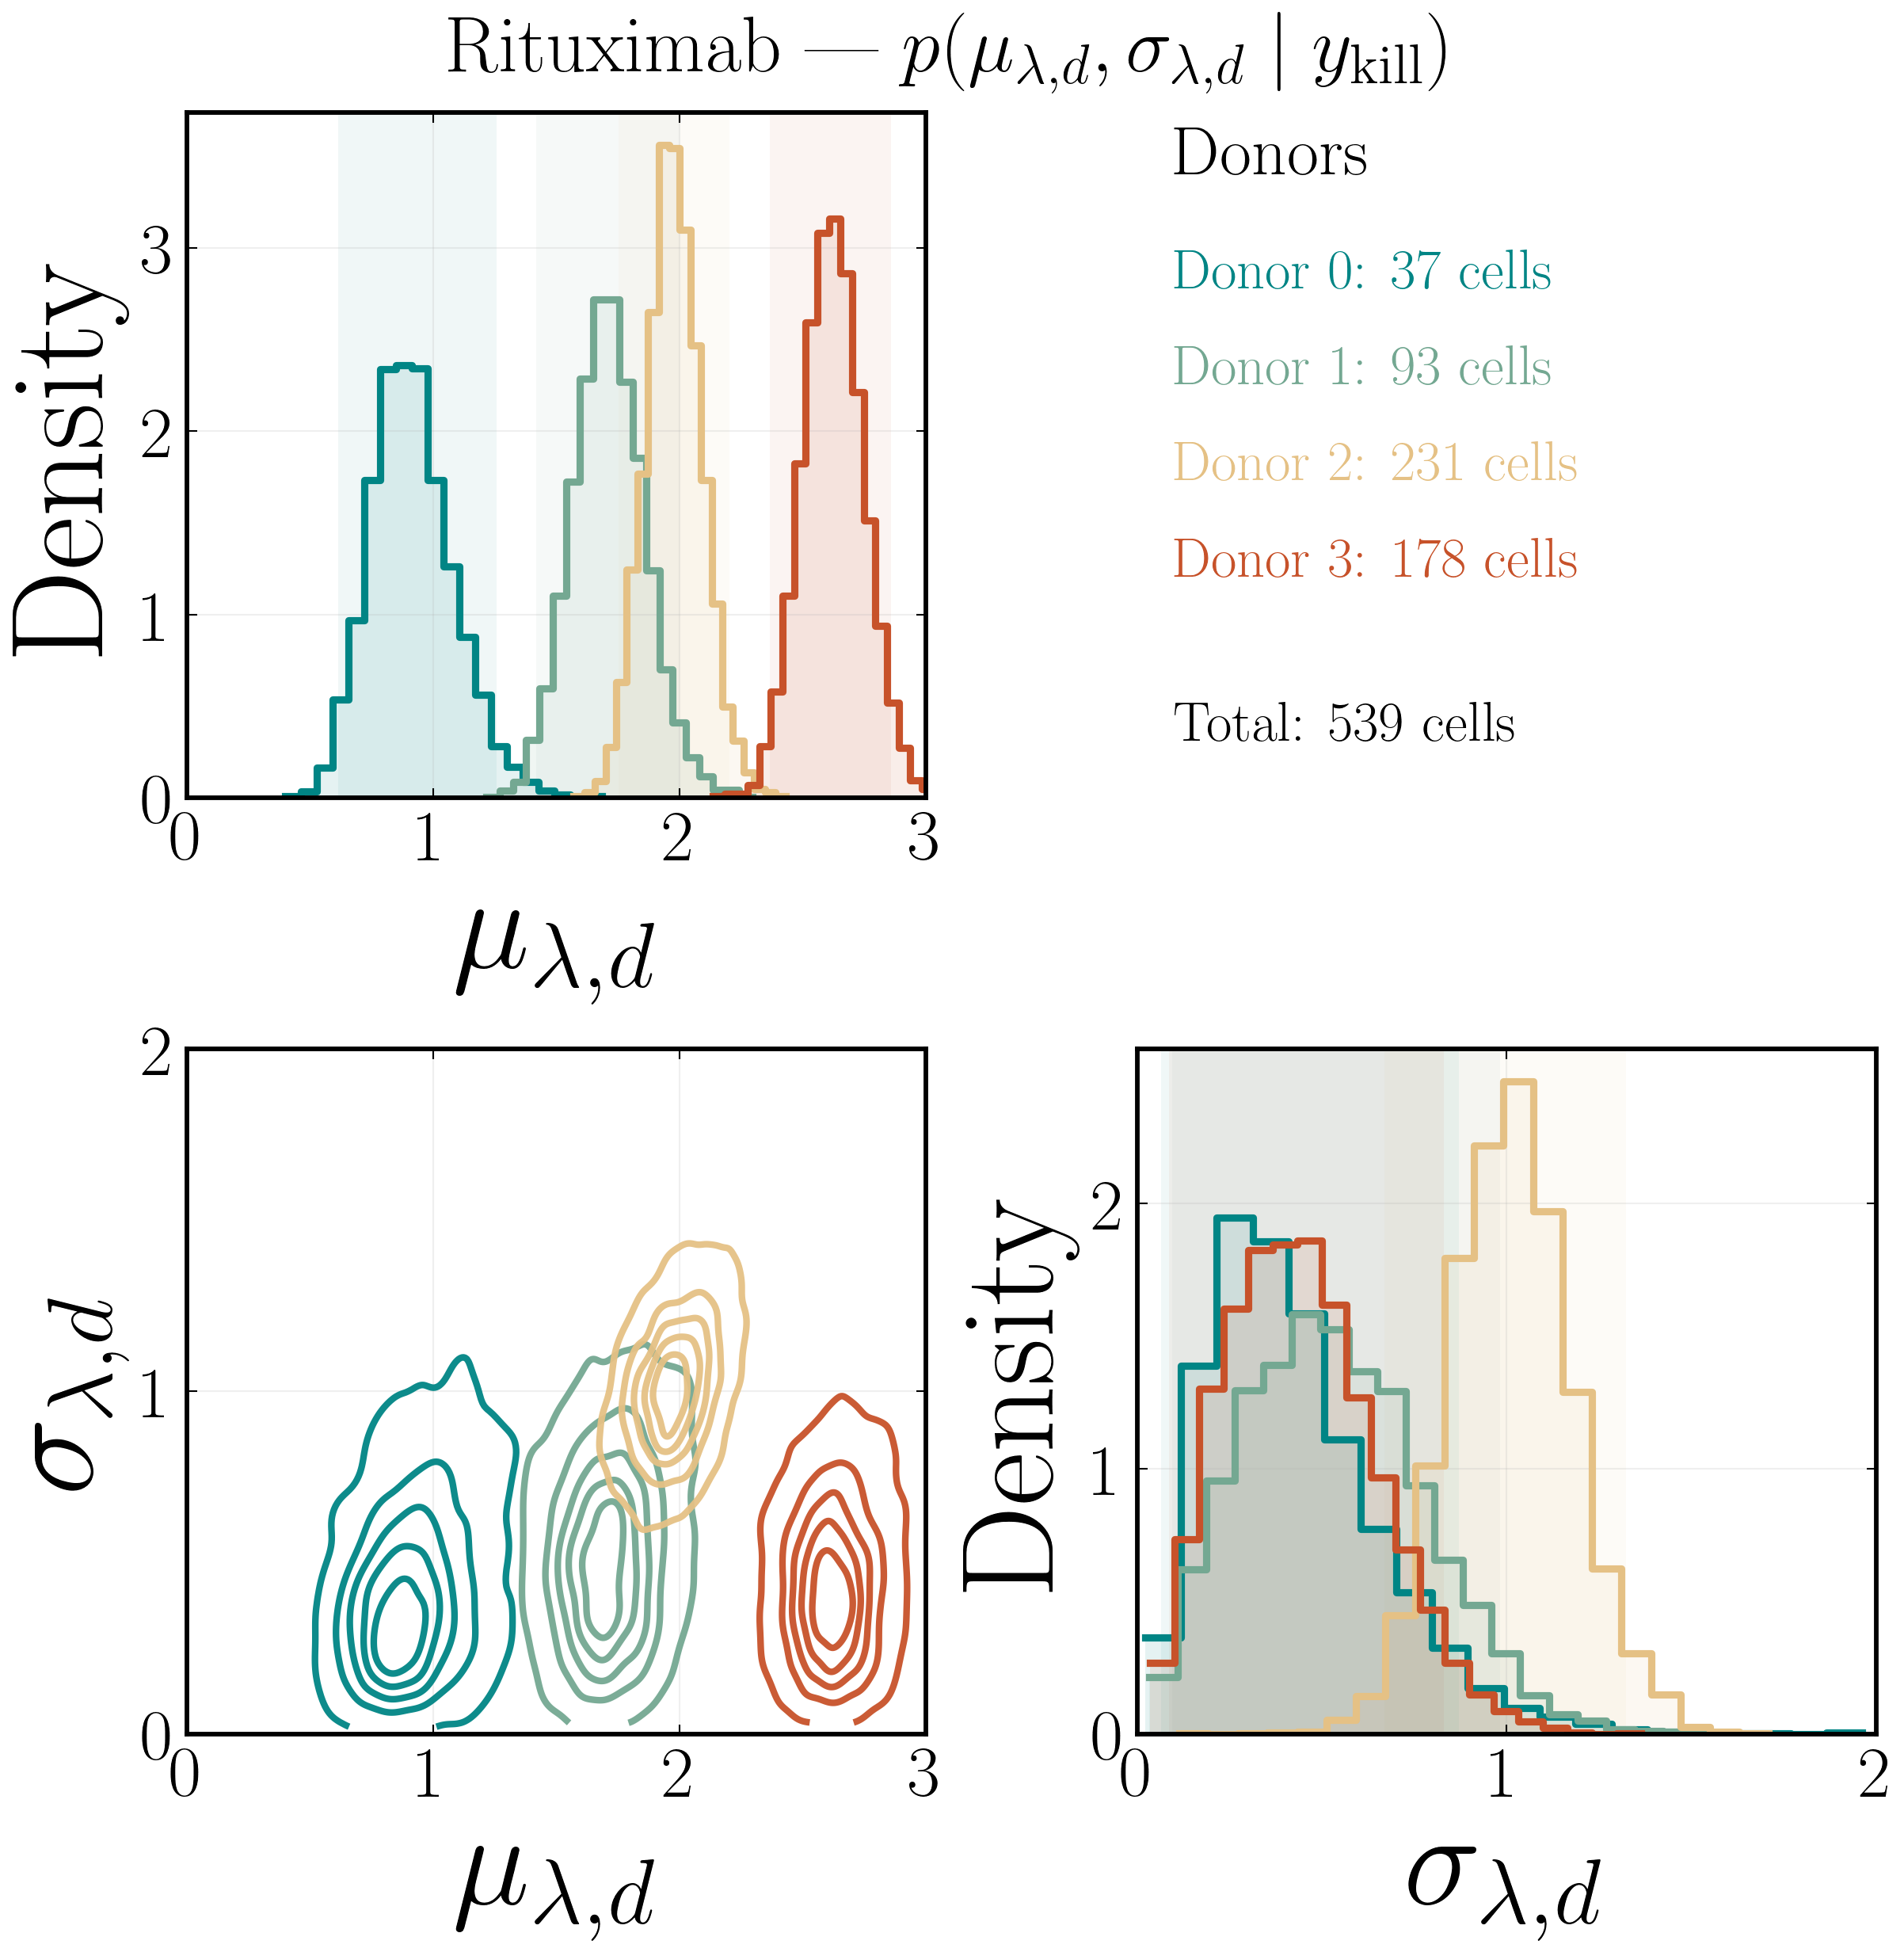

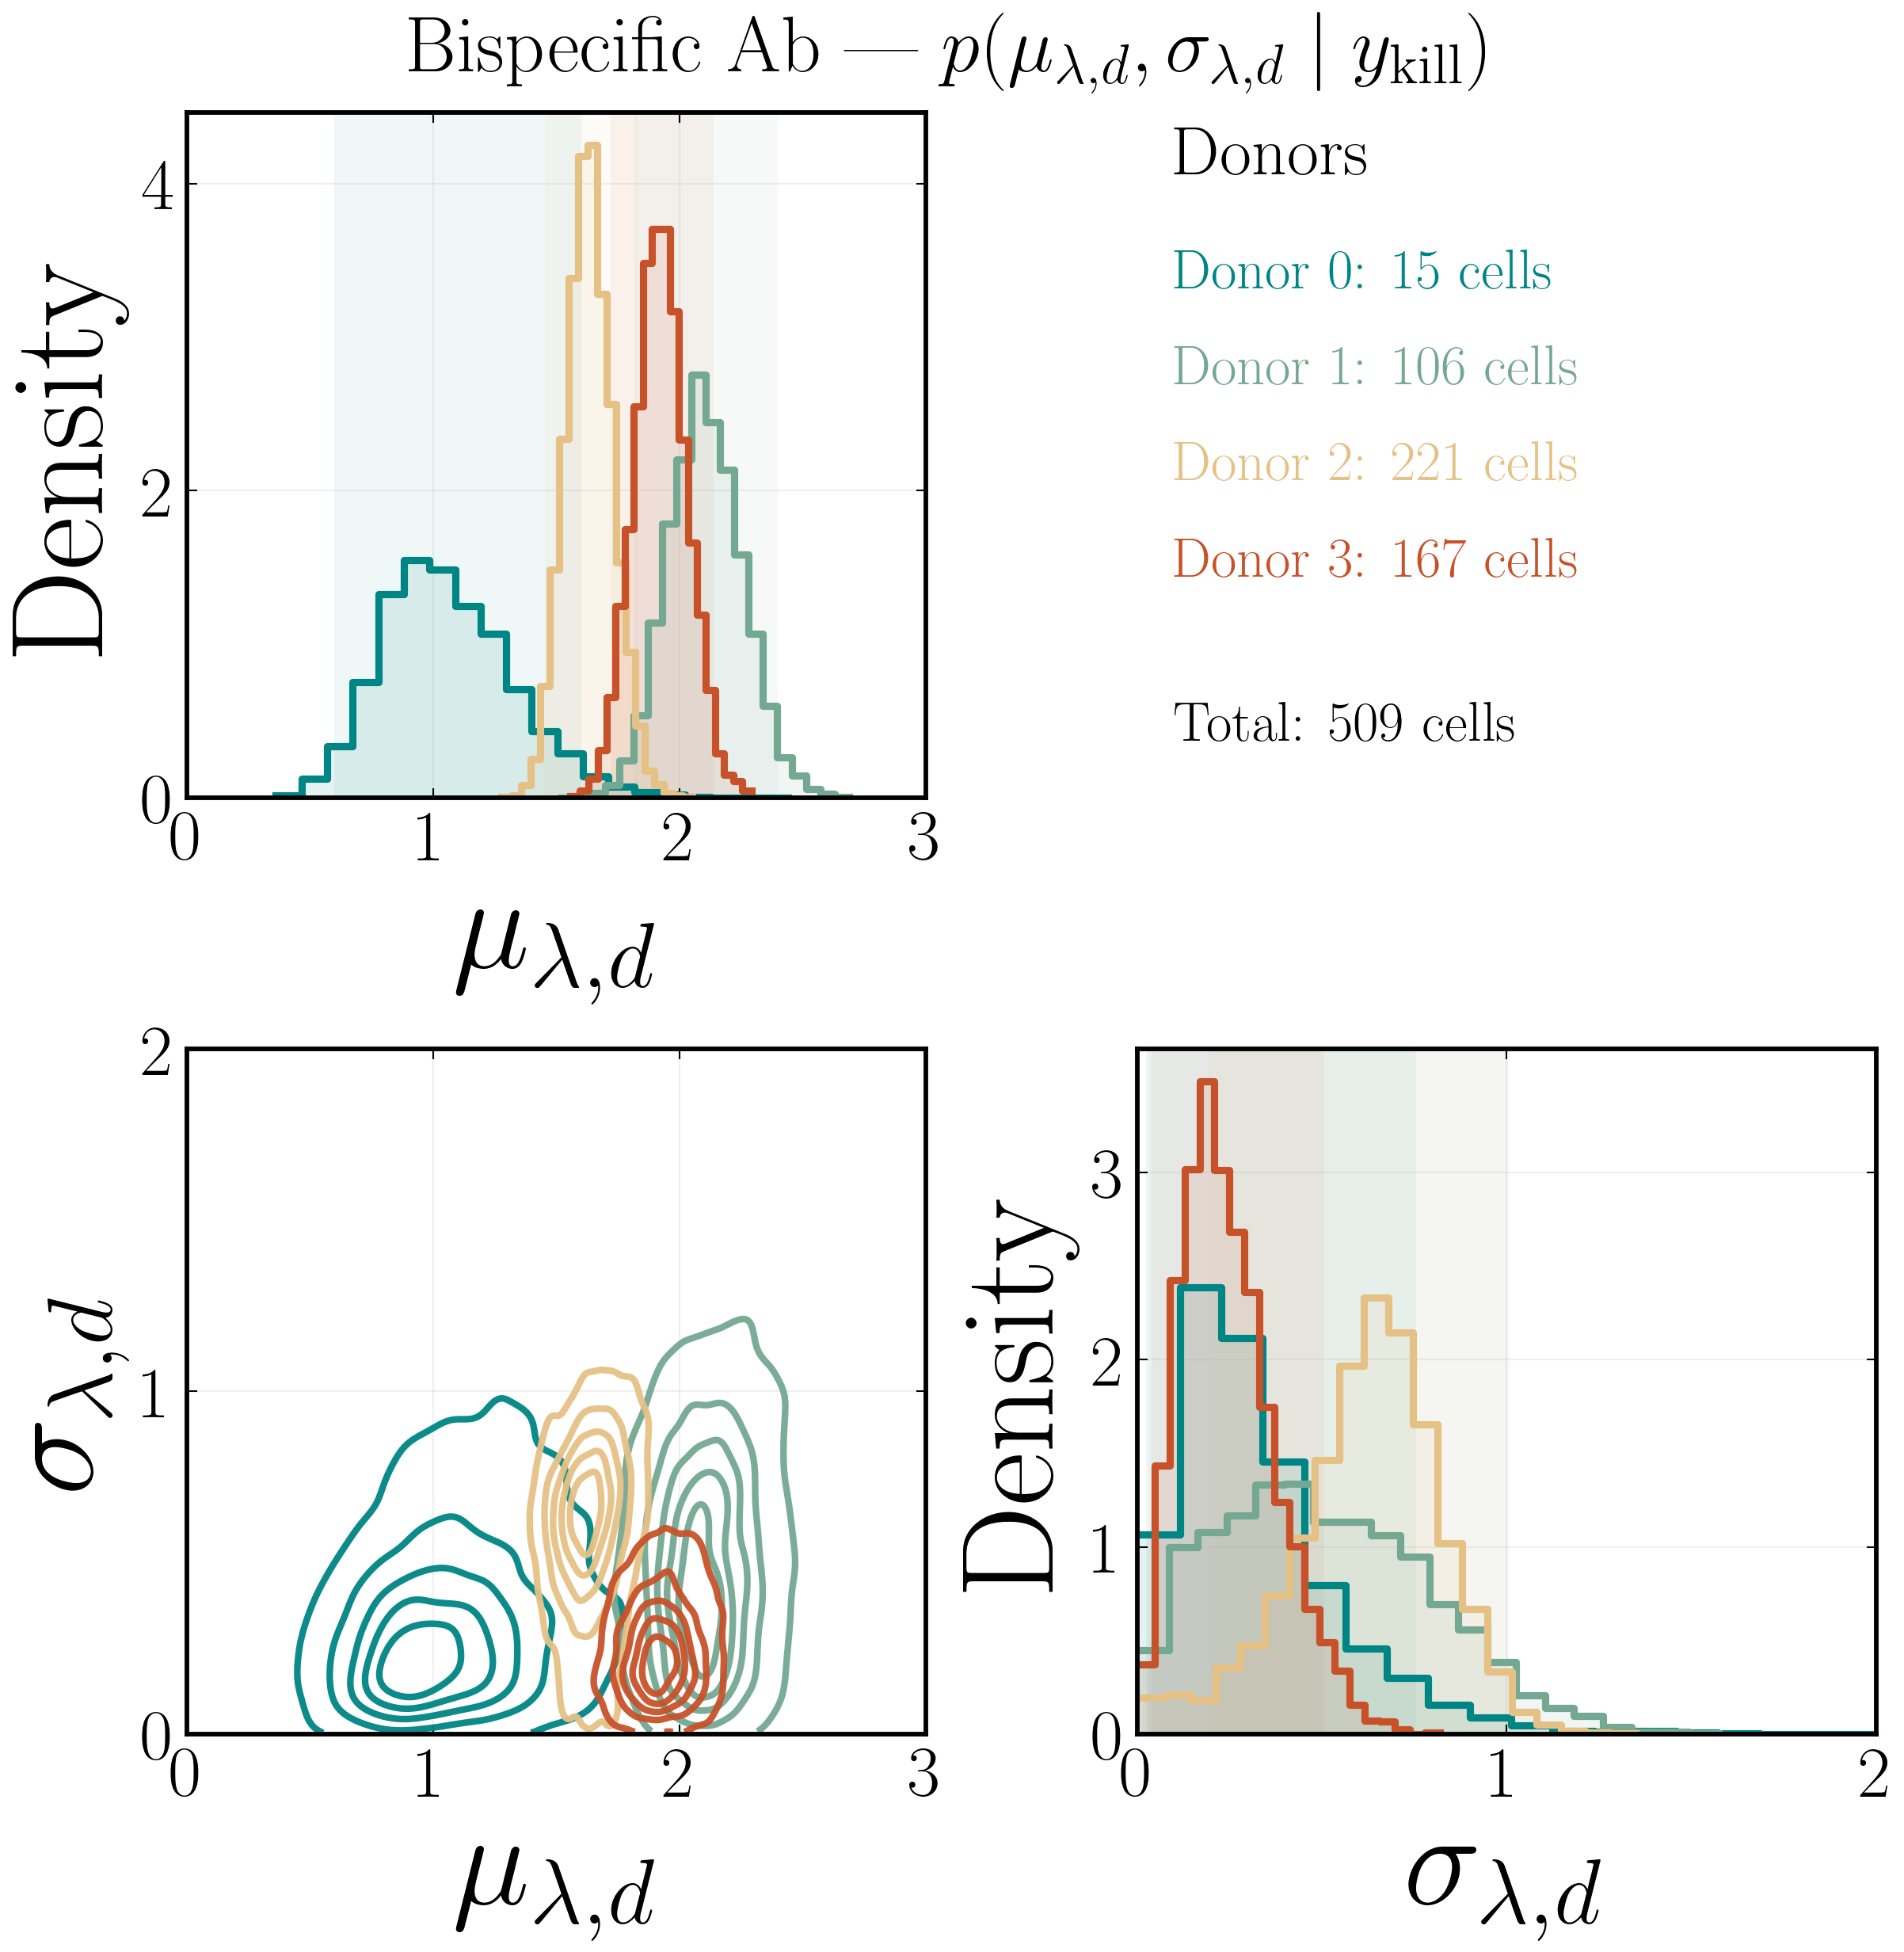

,outcome,condition,donors,svg
0,contacts,No treatment,"0, 1, 2, 3",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
1,contacts,Rituximab,"0, 1, 2, 3",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
2,contacts,Bispecific Ab,"0, 1, 2, 3",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
3,kills,No treatment,"0, 1, 2, 3",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
4,kills,Rituximab,"0, 1, 2, 3",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...
5,kills,Bispecific Ab,"0, 1, 2, 3",/Users/marsian/PhD_LifeSciRes/Barracuda/section_2/f...


In [60]:
def plot_one_condition_all_donors(
    posterior_data: dict,
    outcome: str,
    condition: str,
    *,
    model_name: str = "Dis2P",
    donor_labels: list[int] | None = None,
    donor_colors: dict[int, str] | None = None,
    sample_size: int = 6000,
    hdi_prob: float = 0.95,
    bins: int = 20,
    param_limits: dict[str, tuple[float, float]] | None = None,
    param_ticks: dict[str, list[float]] | None = None,
    cell_counts: dict | None = None,
    save_root: Path = FIGURE_ROOT,
    dpi: int = 300,
) -> Path:
    """
    Plot all donor-specific posteriors together for one condition.

    Each donor is displayed with a distinct color in the marginal
    and joint posterior panels.
    """
    if donor_labels is None:
        donor_labels = DONOR_LABELS

    if donor_colors is None:
        donor_colors = DONOR_COLORS

    posterior_key = (
        condition,
        outcome,
        model_name,
    )

    if posterior_key not in posterior_data:
        raise ValueError(
            f"No posterior data found for "
            f"condition={condition!r}, "
            f"outcome={outcome!r}, "
            f"model={model_name!r}"
        )

    for donor_label in donor_labels:
        if donor_label not in DONOR_MAP:
            raise ValueError(
                f"Unknown donor {donor_label}; "
                f"expected one of {DONOR_LABELS}"
            )

        if donor_label not in donor_colors:
            raise ValueError(
                f"No color defined for donor {donor_label}"
            )

    idata = posterior_data[posterior_key]

    condition_index = (
        list(CONDITION_ORDER).index(condition)
        if condition in CONDITION_ORDER
        else 0
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8, 8.2),
        dpi=dpi,
        constrained_layout=True,
        squeeze=False,
    )

    # The upper-right panel contains donor labels and cell counts.
    axes[0, 1].axis("off")

    axes[0, 1].text(
        0.05,
        0.98,
        "Donors",
        transform=axes[0, 1].transAxes,
        ha="left",
        va="top",
        fontsize=21,
        fontweight="bold",
        color="black",
    )

    total_cells = 0
    valid_cell_counts = True

    for donor_position, donor_label in enumerate(
        donor_labels
    ):
        donor_index = DONOR_MAP[donor_label]
        color = donor_colors[donor_label]

        mu_samples, sigma_samples = (
            get_paired_donor_samples(
                idata,
                donor_index,
                sample_size=sample_size,
                seed=(
                    17
                    + 100 * donor_index
                    + condition_index
                ),
            )
        )

        # ----------------------------------------------------------
        # Donor label and cell count
        # ----------------------------------------------------------

        donor_text = f"Donor {donor_label}"

        if cell_counts is not None:
            number_of_cells = cell_counts.get(
                (
                    donor_label,
                    condition,
                )
            )

            if number_of_cells is not None:
                number_of_cells = int(
                    number_of_cells
                )

                total_cells += number_of_cells

                donor_text += (
                    f": {number_of_cells:,} cells"
                )
            else:
                valid_cell_counts = False
        else:
            valid_cell_counts = False

        axes[0, 1].text(
            0.05,
            0.80 - 0.14 * donor_position,
            donor_text,
            transform=axes[0, 1].transAxes,
            ha="left",
            va="top",
            fontsize=17,
            fontweight="bold",
            color=color,
        )

        # ----------------------------------------------------------
        # Marginal posterior: mu_lambda
        # ----------------------------------------------------------

        sns.histplot(
            mu_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=True,
            color=color,
            alpha=0.10,
            linewidth=0,
            ax=axes[0, 0],
        )

        sns.histplot(
            mu_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            color=color,
            linewidth=2.2,
            label=f"Donor {donor_label}",
            ax=axes[0, 0],
        )

        mu_hdi = np.asarray(
            az.hdi(
                mu_samples,
                hdi_prob=hdi_prob,
            ),
            dtype=float,
        ).ravel()

        axes[0, 0].axvspan(
            mu_hdi[0],
            mu_hdi[1],
            color=color,
            alpha=0.06,
            linewidth=0,
            zorder=0,
        )

        # ----------------------------------------------------------
        # Marginal posterior: sigma_lambda
        # ----------------------------------------------------------

        sns.histplot(
            sigma_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=True,
            color=color,
            alpha=0.10,
            linewidth=0,
            ax=axes[1, 1],
        )

        sns.histplot(
            sigma_samples,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            color=color,
            linewidth=2.2,
            ax=axes[1, 1],
        )

        sigma_hdi = np.asarray(
            az.hdi(
                sigma_samples,
                hdi_prob=hdi_prob,
            ),
            dtype=float,
        ).ravel()

        axes[1, 1].axvspan(
            sigma_hdi[0],
            sigma_hdi[1],
            color=color,
            alpha=0.06,
            linewidth=0,
            zorder=0,
        )

        # ----------------------------------------------------------
        # Joint posterior
        # ----------------------------------------------------------

        sns.kdeplot(
            x=mu_samples,
            y=sigma_samples,
            color=color,
            linewidths=2.0,
            levels=6,
            fill=False,
            alpha=0.95,
            cut=0,
            warn_singular=False,
            ax=axes[1, 0],
        )

    # Total number of cells across all donors.
    if valid_cell_counts:
        axes[0, 1].text(
            0.05,
            0.14,
            f"Total: {total_cells:,} cells",
            transform=axes[0, 1].transAxes,
            ha="left",
            va="top",
            fontsize=17,
            fontweight="bold",
            color="black",
        )

    # --------------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------------
    axis_title_fontsize = 40
    axes[0, 0].set_xlabel(
        DONOR_PARAM_DISPLAY["mu_lambda"],
        fontsize=axis_title_fontsize,
    )
    axes[0, 0].set_ylabel(
        "Density",
        fontsize=axis_title_fontsize,
    )

    axes[1, 0].set_xlabel(
        DONOR_PARAM_DISPLAY["mu_lambda"],
        fontsize=axis_title_fontsize,
    )
    axes[1, 0].set_ylabel(
        DONOR_PARAM_DISPLAY["sigma_lambda"],
        fontsize=axis_title_fontsize,
    )

    axes[1, 1].set_xlabel(
        DONOR_PARAM_DISPLAY["sigma_lambda"],
        fontsize=axis_title_fontsize,
    )
    axes[1, 1].set_ylabel(
        "Density",
        fontsize=axis_title_fontsize,
    )

    # --------------------------------------------------------------
    # Shared parameter limits
    # --------------------------------------------------------------

    if param_limits is not None:
        if "mu_lambda" in param_limits:
            axes[0, 0].set_xlim(
                *param_limits["mu_lambda"]
            )
            axes[1, 0].set_xlim(
                *param_limits["mu_lambda"]
            )

        if "sigma_lambda" in param_limits:
            axes[1, 1].set_xlim(
                *param_limits["sigma_lambda"]
            )
            axes[1, 0].set_ylim(
                *param_limits["sigma_lambda"]
            )

    # --------------------------------------------------------------
    # Shared parameter ticks
    # --------------------------------------------------------------

    if param_ticks is not None:
        if "mu_lambda" in param_ticks:
            mu_ticks = param_ticks[
                "mu_lambda"
            ]

            axes[0, 0].set_xticks(
                mu_ticks
            )
            axes[1, 0].set_xticks(
                mu_ticks
            )

        if "sigma_lambda" in param_ticks:
            sigma_ticks = param_ticks[
                "sigma_lambda"
            ]

            axes[1, 1].set_xticks(
                sigma_ticks
            )
            axes[1, 0].set_yticks(
                sigma_ticks
            )

    # --------------------------------------------------------------
    # Styling
    # --------------------------------------------------------------

    for row, column in [
        (0, 0),
        (1, 0),
        (1, 1),
    ]:
        ax = axes[row, column]

        ax.set_facecolor("white")

        ax.tick_params(
            axis="both",
            labelsize=22,
        )

        ax.minorticks_off()
        ax.grid(alpha=0.20)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_color("black")

    fig.suptitle(
        (
            f"{condition} — "
            rf"$p(\mu_{{\lambda,d}},"
            rf"\sigma_{{\lambda,d}}"
            rf"\mid {OUTCOME_SYMBOL[outcome]})$"
        ),
        fontsize=24,
    )

    # --------------------------------------------------------------
    # Save into a clearly labelled subfolder
    # --------------------------------------------------------------

    condition_slug = (
        condition.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    condition_save_dir = (
        Path(save_root)
        / "condition_posteriors_all_donors"
        / outcome
        / condition_slug
    )

    condition_save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = condition_save_dir / (
        f"joint_posterior_"
        f"{condition_slug}_"
        f"{outcome}_"
        f"{model_name}_"
        f"all_donors.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.25,
        transparent=True,
    )

    plt.show()

    return out_path


# ==================================================================
# Generate one all-donor posterior plot per condition and outcome
# ==================================================================

CONDITION_ALL_DONORS_POSTERIOR_RECORDS = []

for outcome in [
    "contacts",
    "kills",
]:
    available_conditions = [
        condition
        for condition in CONDITION_ORDER
        if (
            condition,
            outcome,
            "Dis2P",
        ) in posterior_data
    ]

    for condition in available_conditions:
        figure_path = (
            plot_one_condition_all_donors(
                posterior_data,
                outcome=outcome,
                condition=condition,
                model_name="Dis2P",
                donor_labels=DONOR_LABELS,
                donor_colors=DONOR_COLORS,
                param_limits=(
                    DONOR_PARAMETER_LIMITS[
                        outcome
                    ]
                ),
                param_ticks=(
                    DONOR_PARAMETER_TICKS[
                        outcome
                    ]
                ),
                cell_counts=cell_numbers,
                save_root=FIGURE_ROOT,
            )
        )

        CONDITION_ALL_DONORS_POSTERIOR_RECORDS.append(
            {
                "outcome": outcome,
                "condition": condition,
                "donors": ", ".join(
                    str(donor)
                    for donor in DONOR_LABELS
                ),
                "svg": figure_path,
            }
        )


CONDITION_ALL_DONORS_POSTERIOR_PATHS = (
    pd.DataFrame(
        CONDITION_ALL_DONORS_POSTERIOR_RECORDS
    )
)

display(
    CONDITION_ALL_DONORS_POSTERIOR_PATHS
)

## Within-donor treatment contrasts

For each donor, condition-specific posteriors were fitted independently. Contrast draws therefore pair independently permuted particles from the two conditions. The tables report the contrast median, 95% HDI, and the posterior probability of each direction.

In [ ]:
def calculate_donor_posterior_differences(
    posterior_data: dict,
    *,
    outcome: str = "kills",
    model_name: str = "Dis2P",
    donor_labels: Sequence[int] = DONOR_LABELS,
    comparisons: Sequence[
        tuple[str, str]
    ] | None = None,
    hdi_prob: float = 0.95,
    random_seed: int | None = None,
) -> tuple[pd.DataFrame, dict]:
    if comparisons is None:
        comparisons = [
            (
                "Rituximab",
                "No treatment",
            ),
            (
                "Bispecific Ab",
                "No treatment",
            ),
            (
                "Bispecific Ab",
                "Rituximab",
            ),
        ]

    if not 0.0 < hdi_prob < 1.0:
        raise ValueError(
            "hdi_prob must be between 0 and 1"
        )

    parameter_names = {
        "mu_lambda": r"$\mu_{\lambda,d}$",
        "sigma_lambda": r"$\sigma_{\lambda,d}$",
    }

    rng = np.random.default_rng(
        random_seed
    )

    results = []
    difference_samples = {}

    required_conditions = sorted({
        condition
        for comparison in comparisons
        for condition in comparison
    })

    for donor_label in donor_labels:
        if donor_label not in DONOR_MAP:
            raise ValueError(
                f"Unknown donor label {donor_label}; "
                f"expected one of {list(DONOR_MAP)}"
            )

        donor_index = DONOR_MAP[
            donor_label
        ]

        samples_by_condition = {}

        # Load every posterior particle for this donor.
        for condition in required_conditions:
            key = (
                condition,
                outcome,
                model_name,
            )

            if key not in posterior_data:
                raise KeyError(
                    f"Posterior data not found for {key}"
                )

            mu_samples, sigma_samples = (
                get_paired_donor_samples(
                    posterior_data[key],
                    donor_index,
                    sample_size=None,
                )
            )

            samples_by_condition[
                condition
            ] = {
                "mu_lambda": mu_samples,
                "sigma_lambda": sigma_samples,
            }

        for (
            condition_1,
            condition_2,
        ) in comparisons:
            condition_1_samples = (
                samples_by_condition[
                    condition_1
                ]
            )

            condition_2_samples = (
                samples_by_condition[
                    condition_2
                ]
            )

            n_samples_1 = (
                condition_1_samples[
                    "mu_lambda"
                ].size
            )

            n_samples_2 = (
                condition_2_samples[
                    "mu_lambda"
                ].size
            )
            n_contrast_draws = min(
                n_samples_1,
                n_samples_2,
            )
            indices_1 = rng.permutation(
                n_samples_1
            )[:n_contrast_draws]

            indices_2 = rng.permutation(
                n_samples_2
            )[:n_contrast_draws]

            for (
                parameter,
                parameter_label,
            ) in parameter_names.items():
                samples_1 = (
                    condition_1_samples[
                        parameter
                    ][indices_1]
                )

                samples_2 = (
                    condition_2_samples[
                        parameter
                    ][indices_2]
                )

                # Posterior contrast:
                # condition_1 minus condition_2.
                difference = (
                    samples_1
                    - samples_2
                )

                difference_key = (
                    donor_label,
                    condition_1,
                    condition_2,
                    parameter,
                )

                difference_samples[
                    difference_key
                ] = difference

                p_positive = float(
                    np.mean(
                        difference > 0.0
                    )
                )

                p_negative = float(
                    np.mean(
                        difference < 0.0
                    )
                )

                hdi = np.asarray(
                    az.hdi(
                        difference,
                        hdi_prob=hdi_prob,
                    ),
                    dtype=float,
                ).ravel()

                if hdi.size != 2:
                    raise ValueError(
                        "Expected a two-element HDI, "
                        f"but received shape {hdi.shape}"
                    )

                results.append(
                    {
                        "donor": donor_label,
                        "outcome": outcome,
                        "model": model_name,
                        "condition_1": (
                            condition_1
                        ),
                        "condition_2": (
                            condition_2
                        ),
                        "comparison": (
                            f"{condition_1} - "
                            f"{condition_2}"
                        ),
                        "parameter": parameter,
                        "parameter_label": (
                            parameter_label
                        ),
                        "n_particles_condition_1": (
                            n_samples_1
                        ),
                        "n_particles_condition_2": (
                            n_samples_2
                        ),
                        "n_contrast_draws": (
                            difference.size
                        ),
                        "mean_difference": float(
                            np.mean(
                                difference
                            )
                        ),
                        "median_difference": float(
                            np.median(
                                difference
                            )
                        ),
                        "hdi_low": float(
                            hdi[0]
                        ),
                        "hdi_high": float(
                            hdi[1]
                        ),
                        "p_difference_positive": (
                            p_positive
                        ),
                        "p_difference_negative": (
                            p_negative
                        ),
                    }
                )

    result_df = pd.DataFrame(
        results
    )

    return (
        result_df,
        difference_samples,
    )


def display_donor_posterior_differences(
    difference_df: pd.DataFrame,
) -> None:
    """Display a formatted posterior-contrast table."""

    display_columns = [
        "donor",
        "comparison",
        "parameter",
        "n_contrast_draws",
        "median_difference",
        "hdi_low",
        "hdi_high",
        "p_difference_positive",
        "p_difference_negative",
    ]

    display(
        difference_df[
            display_columns
        ]
        .sort_values(
            [
                "donor",
                "parameter",
                "comparison",
            ]
        )
        .style.format(
            {
                "n_contrast_draws": "{:,}",
                "median_difference": "{:+.3f}",
                "hdi_low": "{:+.3f}",
                "hdi_high": "{:+.3f}",
                "p_difference_positive": "{:.3%}",
                "p_difference_negative": "{:.3%}",
            }
        )
    )

In [67]:
contact_difference_df, contact_difference_samples = (
    calculate_donor_posterior_differences(
        posterior_data,
        outcome="contacts",
        model_name="Dis2P",
    )
)

contact_difference_df.to_csv(
    RESULT_ROOT / "posterior_contrasts_contacts_Dis2P.csv",
    index=False,
)

display_donor_posterior_differences(
    contact_difference_df,
)

,donor,comparison,parameter,n_contrast_draws,median_difference,hdi_low,hdi_high,p_difference_positive,p_difference_negative
2,0,Bispecific Ab - No treatment,mu_lambda,"80,000",-0.344,-1.028,+0.424,18.569%,81.431%
4,0,Bispecific Ab - Rituximab,mu_lambda,"80,000",+0.117,-0.607,+0.913,62.325%,37.675%
0,0,Rituximab - No treatment,mu_lambda,"80,000",-0.461,-0.992,+0.088,5.120%,94.880%
3,0,Bispecific Ab - No treatment,sigma_lambda,"80,000",+0.015,-0.585,+0.721,52.058%,47.942%
5,0,Bispecific Ab - Rituximab,sigma_lambda,"80,000",-0.068,-0.813,+0.700,41.579%,58.421%
1,0,Rituximab - No treatment,sigma_lambda,"80,000",+0.087,-0.503,+0.740,61.777%,38.222%
8,1,Bispecific Ab - No treatment,mu_lambda,"80,000",+0.291,-0.285,+0.870,83.966%,16.034%
10,1,Bispecific Ab - Rituximab,mu_lambda,"80,000",+0.166,-0.414,+0.760,71.034%,28.966%
6,1,Rituximab - No treatment,mu_lambda,"80,000",+0.125,-0.464,+0.732,65.945%,34.055%
9,1,Bispecific Ab - No treatment,sigma_lambda,"80,000",-0.097,-0.962,+0.796,41.659%,58.341%


In [68]:
kill_difference_df, kill_difference_samples = (
    calculate_donor_posterior_differences(
        posterior_data,
        outcome="kills",
        model_name="Dis2P",
    )
)

kill_difference_df.to_csv(
    RESULT_ROOT / "posterior_contrasts_kills_Dis2P.csv",
    index=False,
)

display_donor_posterior_differences(
    kill_difference_df,
)

,donor,comparison,parameter,n_contrast_draws,median_difference,hdi_low,hdi_high,p_difference_positive,p_difference_negative
2,0,Bispecific Ab - No treatment,mu_lambda,"80,000",+0.437,-0.067,+1.028,96.207%,3.792%
4,0,Bispecific Ab - Rituximab,mu_lambda,"80,000",+0.135,-0.461,+0.765,67.381%,32.619%
0,0,Rituximab - No treatment,mu_lambda,"80,000",+0.300,-0.072,+0.695,94.938%,5.062%
3,0,Bispecific Ab - No treatment,sigma_lambda,"80,000",+0.034,-0.404,+0.593,56.524%,43.476%
5,0,Bispecific Ab - Rituximab,sigma_lambda,"80,000",-0.097,-0.755,+0.554,35.931%,64.069%
1,0,Rituximab - No treatment,sigma_lambda,"80,000",+0.136,-0.333,+0.700,72.796%,27.204%
8,1,Bispecific Ab - No treatment,mu_lambda,"80,000",+0.617,+0.232,+1.017,99.873%,0.128%
10,1,Bispecific Ab - Rituximab,mu_lambda,"80,000",+0.390,-0.027,+0.805,96.704%,3.296%
6,1,Rituximab - No treatment,mu_lambda,"80,000",+0.227,-0.160,+0.617,87.534%,12.466%
9,1,Bispecific Ab - No treatment,sigma_lambda,"80,000",+0.042,-0.586,+0.735,54.734%,45.266%


## Baseline differences between donors

The following contrasts compare donors within the no-treatment condition. Because the donor parameters are inferred jointly within one model, differences are calculated from matching chain-and-draw positions, preserving posterior dependence through the shared reference parameters.

In [64]:
def posterior_donor_matrix(
    idata: az.InferenceData,
    variable: str,
) -> np.ndarray:
    data = idata.posterior[variable]
    donor_dims = [
        dim
        for dim in data.dims
        if dim not in {"chain", "draw"}
    ]
    if len(donor_dims) != 1:
        raise ValueError(
            f"Expected one donor dimension for {variable}; found {data.dims}"
        )
    donor_dim = donor_dims[0]
    values = data.transpose("chain", "draw", donor_dim).values
    return np.asarray(values, dtype=float).reshape(-1, values.shape[-1])


def summarize_contrast(
    difference: np.ndarray,
    *,
    hdi_prob: float = 0.95,
) -> dict:
    difference = np.asarray(difference, dtype=float)
    difference = difference[np.isfinite(difference)]
    if difference.size == 0:
        raise ValueError("No finite contrast draws")
    hdi_low, hdi_high = np.asarray(
        az.hdi(difference, hdi_prob=hdi_prob),
        dtype=float,
    ).ravel()
    return {
        "n_contrast_draws": difference.size,
        "median_difference": float(np.median(difference)),
        "hdi_low": float(hdi_low),
        "hdi_high": float(hdi_high),
        "p_difference_positive": float(np.mean(difference > 0.0)),
        "p_difference_negative": float(np.mean(difference < 0.0)),
    }


def calculate_between_donor_contrasts(
    posterior_data: dict,
    *,
    outcome: str,
    condition: str = "No treatment",
    model_name: str = "Dis2P",
    hdi_prob: float = 0.95,
) -> pd.DataFrame:
    key = (condition, outcome, model_name)
    if key not in posterior_data:
        raise KeyError(f"Posterior data not found for {key}")
    idata = posterior_data[key]
    rows = []
    for parameter, variable in {
        "mu_lambda": "mu_lambda_donor",
        "sigma_lambda": "sigma_lambda_donor",
    }.items():
        samples = posterior_donor_matrix(idata, variable)
        for donor_1, donor_2 in combinations(DONOR_LABELS, 2):
            index_1 = DONOR_MAP[donor_1]
            index_2 = DONOR_MAP[donor_2]
            difference = samples[:, index_1] - samples[:, index_2]
            rows.append(
                {
                    "condition": condition,
                    "outcome": outcome,
                    "model": model_name,
                    "donor_1": donor_1,
                    "donor_2": donor_2,
                    "comparison": f"Donor {donor_1} - Donor {donor_2}",
                    "parameter": parameter,
                    **summarize_contrast(
                        difference,
                        hdi_prob=hdi_prob,
                    ),
                }
            )
    return pd.DataFrame(rows)


baseline_donor_difference_df = pd.concat(
    [
        calculate_between_donor_contrasts(
            posterior_data,
            outcome=outcome,
        )
        for outcome in ACTIVE_OUTCOME_ORDER
    ],
    ignore_index=True,
)

baseline_donor_difference_df.to_csv(
    RESULT_ROOT / "baseline_between_donor_contrasts_Dis2P.csv",
    index=False,
)

display(
    baseline_donor_difference_df.sort_values(
        ["outcome", "parameter", "donor_1", "donor_2"]
    ).style.format(
        {
            "n_contrast_draws": "{:,}",
            "median_difference": "{:+.3f}",
            "hdi_low": "{:+.3f}",
            "hdi_high": "{:+.3f}",
            "p_difference_positive": "{:.3%}",
            "p_difference_negative": "{:.3%}",
        }
    )
)

,condition,outcome,model,donor_1,donor_2,comparison,parameter,n_contrast_draws,median_difference,hdi_low,hdi_high,p_difference_positive,p_difference_negative
0,No treatment,contacts,Dis2P,0,1,Donor 0 - Donor 1,mu_lambda,"80,000",-1.815,-2.362,-1.285,0.000%,100.000%
1,No treatment,contacts,Dis2P,0,2,Donor 0 - Donor 2,mu_lambda,"80,000",-0.926,-1.374,-0.462,0.006%,99.994%
2,No treatment,contacts,Dis2P,0,3,Donor 0 - Donor 3,mu_lambda,"80,000",-1.119,-1.528,-0.677,0.000%,100.000%
3,No treatment,contacts,Dis2P,1,2,Donor 1 - Donor 2,mu_lambda,"80,000",+0.891,+0.389,+1.406,99.971%,0.029%
4,No treatment,contacts,Dis2P,1,3,Donor 1 - Donor 3,mu_lambda,"80,000",+0.698,+0.215,+1.182,99.825%,0.175%
5,No treatment,contacts,Dis2P,2,3,Donor 2 - Donor 3,mu_lambda,"80,000",-0.193,-0.590,+0.185,16.611%,83.389%
6,No treatment,contacts,Dis2P,0,1,Donor 0 - Donor 1,sigma_lambda,"80,000",-0.354,-1.047,+0.299,15.065%,84.935%
7,No treatment,contacts,Dis2P,0,2,Donor 0 - Donor 2,sigma_lambda,"80,000",-0.993,-1.489,-0.463,0.044%,99.956%
8,No treatment,contacts,Dis2P,0,3,Donor 0 - Donor 3,sigma_lambda,"80,000",-0.456,-0.967,+0.099,5.951%,94.049%
9,No treatment,contacts,Dis2P,1,2,Donor 1 - Donor 2,sigma_lambda,"80,000",-0.632,-1.316,+0.085,4.525%,95.475%


## Leave-one-donor-out population sensitivity

This diagnostic recalculates the population mixture moments after excluding each donor in turn. It tests whether an apparent population-level treatment contrast is broadly supported or is driven predominantly by one donor. It is a posterior sensitivity calculation and does not refit the likelihood.

In [65]:
def population_moment_samples(
    idata: az.InferenceData,
    *,
    condition: str,
    excluded_donor: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    mu_samples = posterior_donor_matrix(idata, "mu_lambda_donor")
    sigma_samples = posterior_donor_matrix(idata, "sigma_lambda_donor")
    if mu_samples.shape != sigma_samples.shape:
        raise ValueError("Donor mu and sigma posterior shapes differ")

    include = np.ones(DONOR_NUM, dtype=bool)
    if excluded_donor is not None:
        if excluded_donor not in DONOR_MAP:
            raise ValueError(f"Unknown donor {excluded_donor}")
        include[DONOR_MAP[excluded_donor]] = False

    donor_cell_counts = np.asarray(
        [cell_numbers[(donor, condition)] for donor in DONOR_LABELS],
        dtype=float,
    )[include]
    weights = donor_cell_counts / donor_cell_counts.sum()
    mu_included = mu_samples[:, include]
    sigma_included = sigma_samples[:, include]

    population_mu = np.sum(weights[None, :] * mu_included, axis=1)
    population_second_moment = np.sum(
        weights[None, :]
        * (sigma_included**2 + mu_included**2),
        axis=1,
    )
    population_sigma = np.sqrt(
        np.maximum(
            population_second_moment - population_mu**2,
            0.0,
        )
    )
    keep = np.isfinite(population_mu) & np.isfinite(population_sigma)
    return population_mu[keep], population_sigma[keep]


def calculate_leave_one_donor_out_contrasts(
    posterior_data: dict,
    *,
    outcome: str,
    condition_1: str = "Bispecific Ab",
    condition_2: str = "No treatment",
    model_name: str = "Dis2P",
    hdi_prob: float = 0.95,
    random_seed: int = 741,
) -> pd.DataFrame:
    key_1 = (condition_1, outcome, model_name)
    key_2 = (condition_2, outcome, model_name)
    if key_1 not in posterior_data or key_2 not in posterior_data:
        raise KeyError(f"Missing posterior for {key_1} or {key_2}")

    rng = np.random.default_rng(random_seed)
    rows = []
    for excluded_donor in [None, *DONOR_LABELS]:
        mu_1, sigma_1 = population_moment_samples(
            posterior_data[key_1],
            condition=condition_1,
            excluded_donor=excluded_donor,
        )
        mu_2, sigma_2 = population_moment_samples(
            posterior_data[key_2],
            condition=condition_2,
            excluded_donor=excluded_donor,
        )
        n_draws = min(mu_1.size, mu_2.size)
        indices_1 = rng.permutation(mu_1.size)[:n_draws]
        indices_2 = rng.permutation(mu_2.size)[:n_draws]

        for parameter, samples_1, samples_2 in [
            ("mu_lambda_population", mu_1, mu_2),
            ("sigma_lambda_population", sigma_1, sigma_2),
        ]:
            difference = samples_1[indices_1] - samples_2[indices_2]
            rows.append(
                {
                    "outcome": outcome,
                    "model": model_name,
                    "comparison": f"{condition_1} - {condition_2}",
                    "excluded_donor": (
                        "none" if excluded_donor is None else excluded_donor
                    ),
                    "parameter": parameter,
                    **summarize_contrast(
                        difference,
                        hdi_prob=hdi_prob,
                    ),
                }
            )
    return pd.DataFrame(rows)


leave_one_donor_out_df = pd.concat(
    [
        calculate_leave_one_donor_out_contrasts(
            posterior_data,
            outcome=outcome,
        )
        for outcome in ACTIVE_OUTCOME_ORDER
    ],
    ignore_index=True,
)

leave_one_donor_out_df.to_csv(
    RESULT_ROOT / "leave_one_donor_out_population_contrasts_Dis2P.csv",
    index=False,
)

display(
    leave_one_donor_out_df.sort_values(
        ["outcome", "parameter", "excluded_donor"],
        key=lambda column: column.astype(str),
    ).style.format(
        {
            "n_contrast_draws": "{:,}",
            "median_difference": "{:+.3f}",
            "hdi_low": "{:+.3f}",
            "hdi_high": "{:+.3f}",
            "p_difference_positive": "{:.3%}",
            "p_difference_negative": "{:.3%}",
        }
    )
)

,outcome,model,comparison,excluded_donor,parameter,n_contrast_draws,median_difference,hdi_low,hdi_high,p_difference_positive,p_difference_negative
2,contacts,Dis2P,Bispecific Ab - No treatment,0,mu_lambda_population,"80,000",+0.224,-0.020,+0.479,95.974%,4.026%
4,contacts,Dis2P,Bispecific Ab - No treatment,1,mu_lambda_population,"80,000",+0.248,-0.013,+0.507,96.988%,3.012%
6,contacts,Dis2P,Bispecific Ab - No treatment,2,mu_lambda_population,"80,000",+0.407,+0.116,+0.700,99.674%,0.326%
8,contacts,Dis2P,Bispecific Ab - No treatment,3,mu_lambda_population,"80,000",+0.363,+0.053,+0.663,98.999%,1.001%
0,contacts,Dis2P,Bispecific Ab - No treatment,none,mu_lambda_population,"80,000",+0.299,+0.060,+0.535,99.292%,0.708%
3,contacts,Dis2P,Bispecific Ab - No treatment,0,sigma_lambda_population,"80,000",-0.133,-0.487,+0.198,22.159%,77.841%
5,contacts,Dis2P,Bispecific Ab - No treatment,1,sigma_lambda_population,"80,000",-0.128,-0.483,+0.222,23.975%,76.025%
7,contacts,Dis2P,Bispecific Ab - No treatment,2,sigma_lambda_population,"80,000",-0.176,-0.569,+0.243,20.325%,79.675%
9,contacts,Dis2P,Bispecific Ab - No treatment,3,sigma_lambda_population,"80,000",-0.059,-0.437,+0.328,37.910%,62.090%
1,contacts,Dis2P,Bispecific Ab - No treatment,none,sigma_lambda_population,"80,000",-0.108,-0.429,+0.215,25.571%,74.429%
